In [1]:
# Import libraries
import os
import re
import logging
import numpy as np
import io
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from tqdm.notebook import tqdm
from openpyxl import Workbook
from openpyxl.drawing.image import Image
from PIL import Image as PILImage
from datetime import datetime

import img_seq_to_tiff
import align_images

# Define project paths
external_drive_path = os.path.join("..", "..", "..", "..", "bigdisk", "mrogala")
DIC_folder_path = os.path.join(external_drive_path, 'DIC')
raw_data_path = os.path.join(DIC_folder_path, 'DATA_DIC_RAW')
data_dic_processed_path = os.path.join(DIC_folder_path, 'DATA_DIC_PROCESSED')

tiff_3d_output_path = os.path.join(data_dic_processed_path, '3D_TIFF_RAW')
tiff_3d_aligned_output_raw_path = os.path.join(data_dic_processed_path, 'ALIGNED_TIFF_RAW')
tiff_3d_aligned_output_path = os.path.join(data_dic_processed_path, '3D_TIFF_ALIGNED')
dvc_output_path = os.path.join(data_dic_processed_path, 'DVC_OUTPUT')

filtered_path = 'filtered'
strain_filtered_path = 'strain_filtered'

# List of all folders to ensure existence
folders_to_create = [
    DIC_folder_path,
    raw_data_path,
    data_dic_processed_path,
    tiff_3d_output_path,
    tiff_3d_aligned_output_raw_path,
    tiff_3d_aligned_output_path,
    dvc_output_path
]

# Create folders if they don't exist
for folder in folders_to_create:
    os.makedirs(folder, exist_ok=True)
    print(f"Checked or created: {folder}")

# Configure logging
logging.basicConfig(
    filename='DIC_analysis.log',
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)

# Make sure the SSD drive is correctly mounted
if os.path.exists(external_drive_path):
    if os.listdir(external_drive_path) == []:
        print(f"External drive at {external_drive_path} is empty, plese mount with: \n\"sudo mount -t drvfs D: /mnt/d\" \nand rerun the cell...")
    else:
        print(f"Connection to SSD disk at {external_drive_path} is successful.")
else:
    print(f"Failed to connect to SSD disk at {external_drive_path}, try mounting with 'sudo mount -t drvfs D: /mnt/d'...")

Checked or created: ../../../../bigdisk/mrogala/DIC
Checked or created: ../../../../bigdisk/mrogala/DIC/DATA_DIC_RAW
Checked or created: ../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED
Checked or created: ../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED/3D_TIFF_RAW
Checked or created: ../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED/ALIGNED_TIFF_RAW
Checked or created: ../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED/3D_TIFF_ALIGNED
Checked or created: ../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED/DVC_OUTPUT
Connection to SSD disk at ../../../../bigdisk/mrogala is successful.


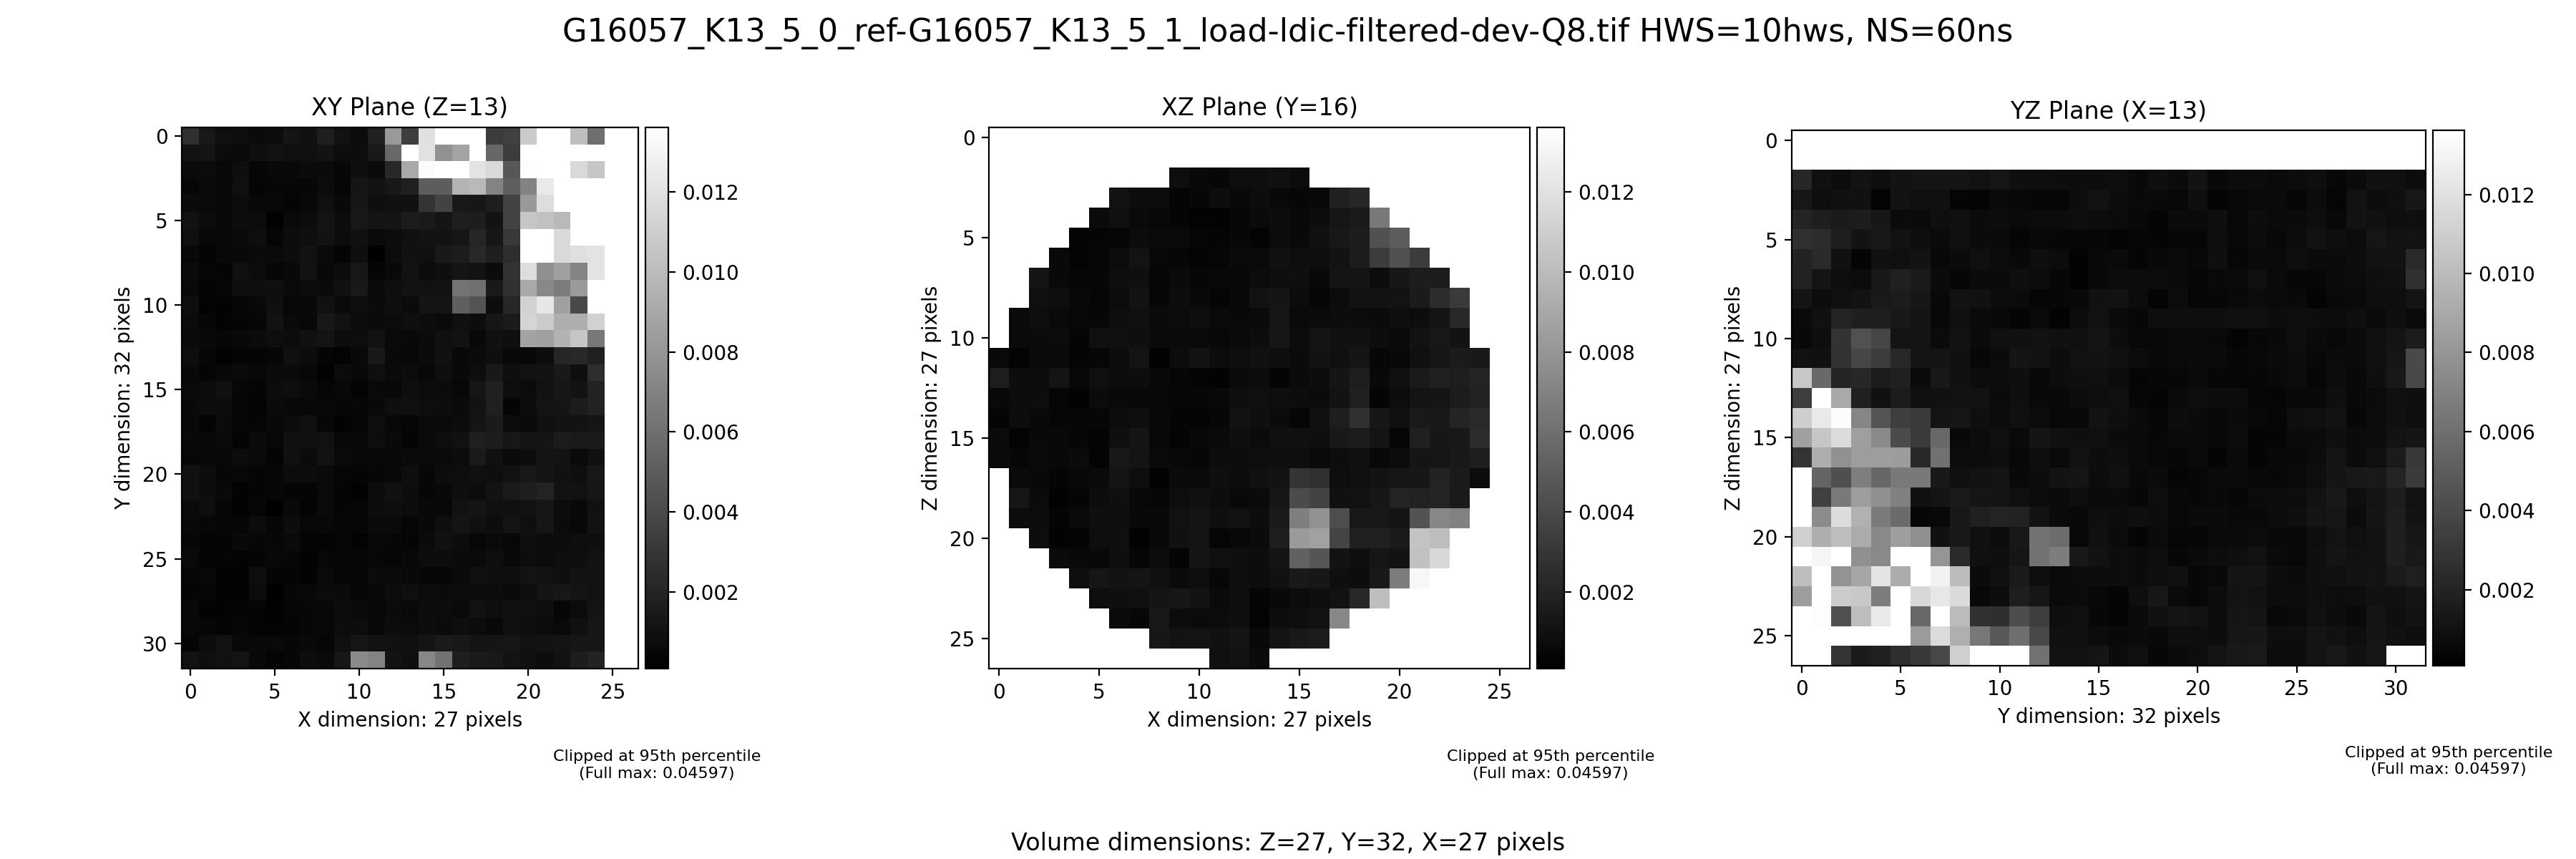

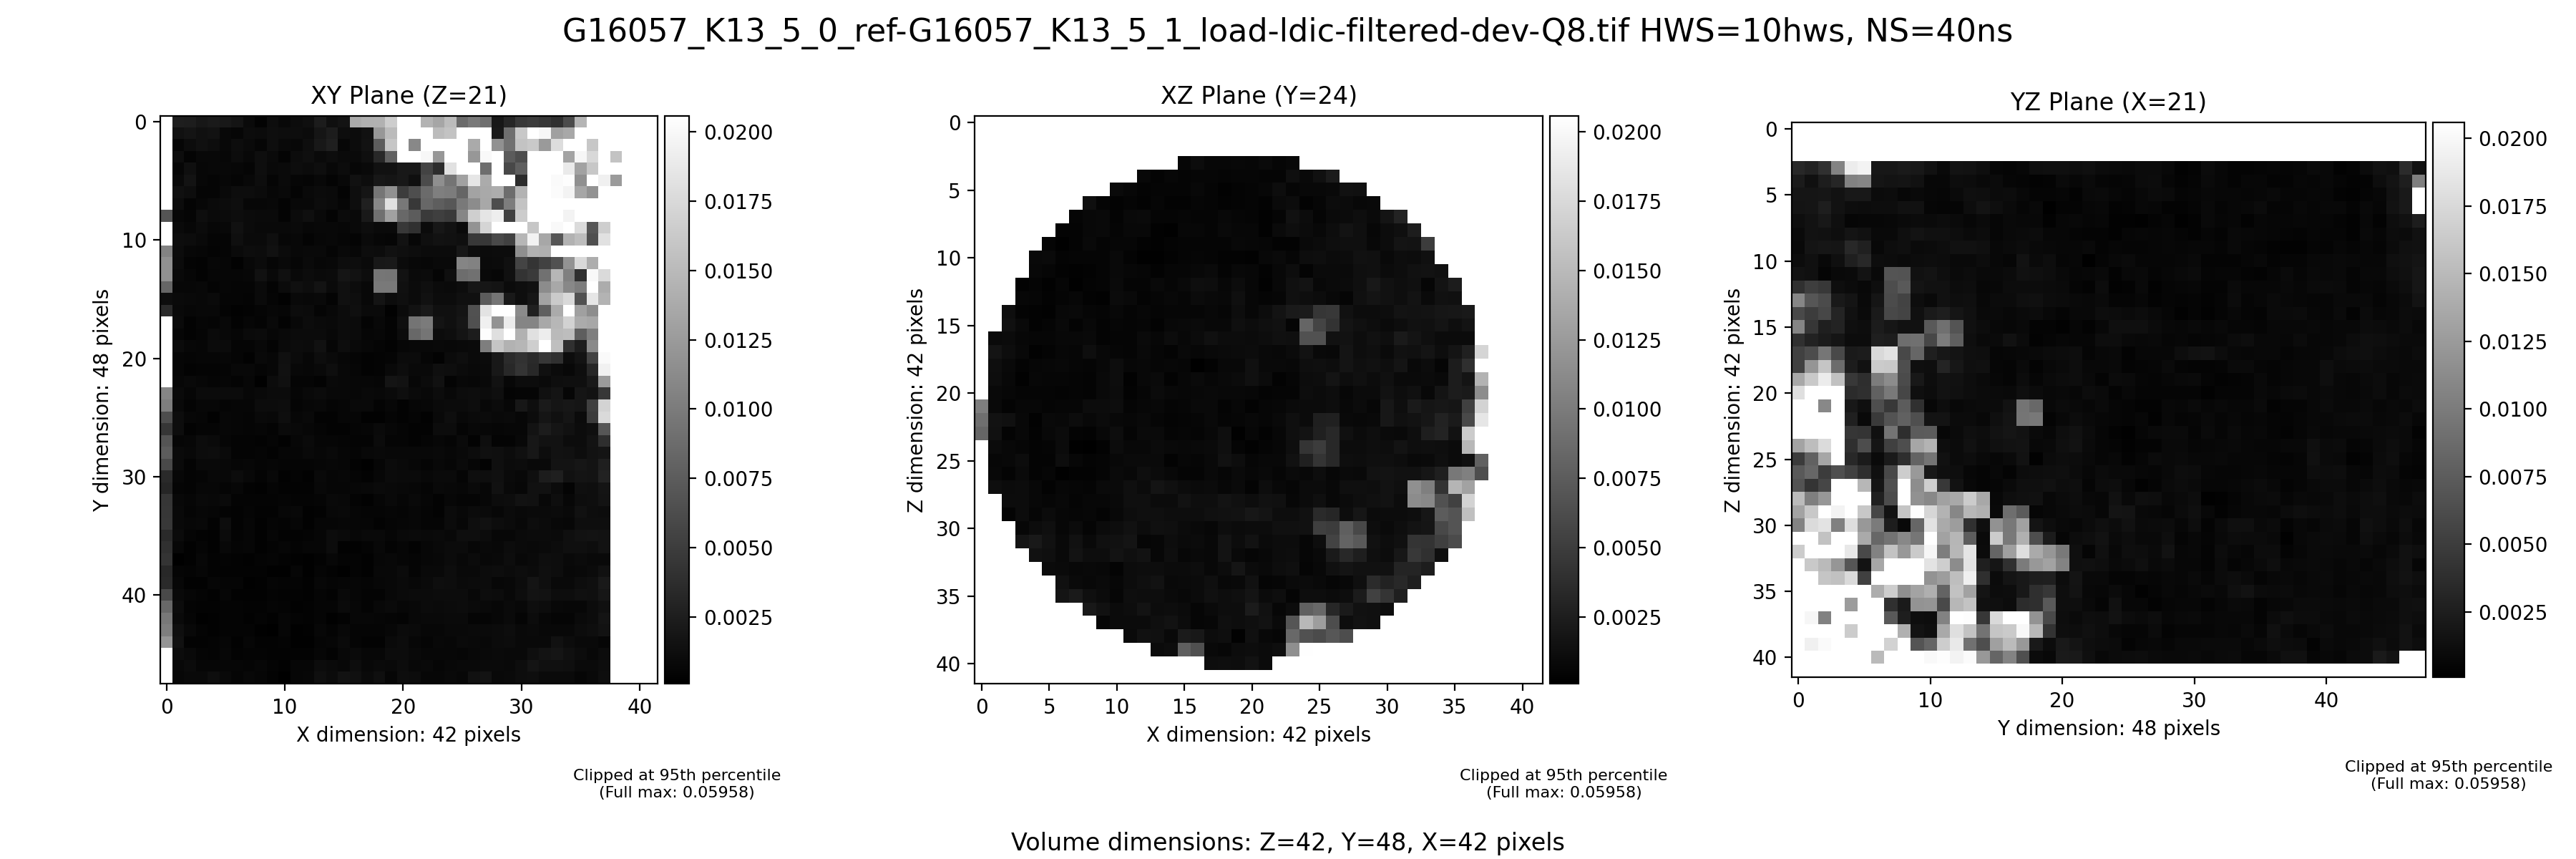

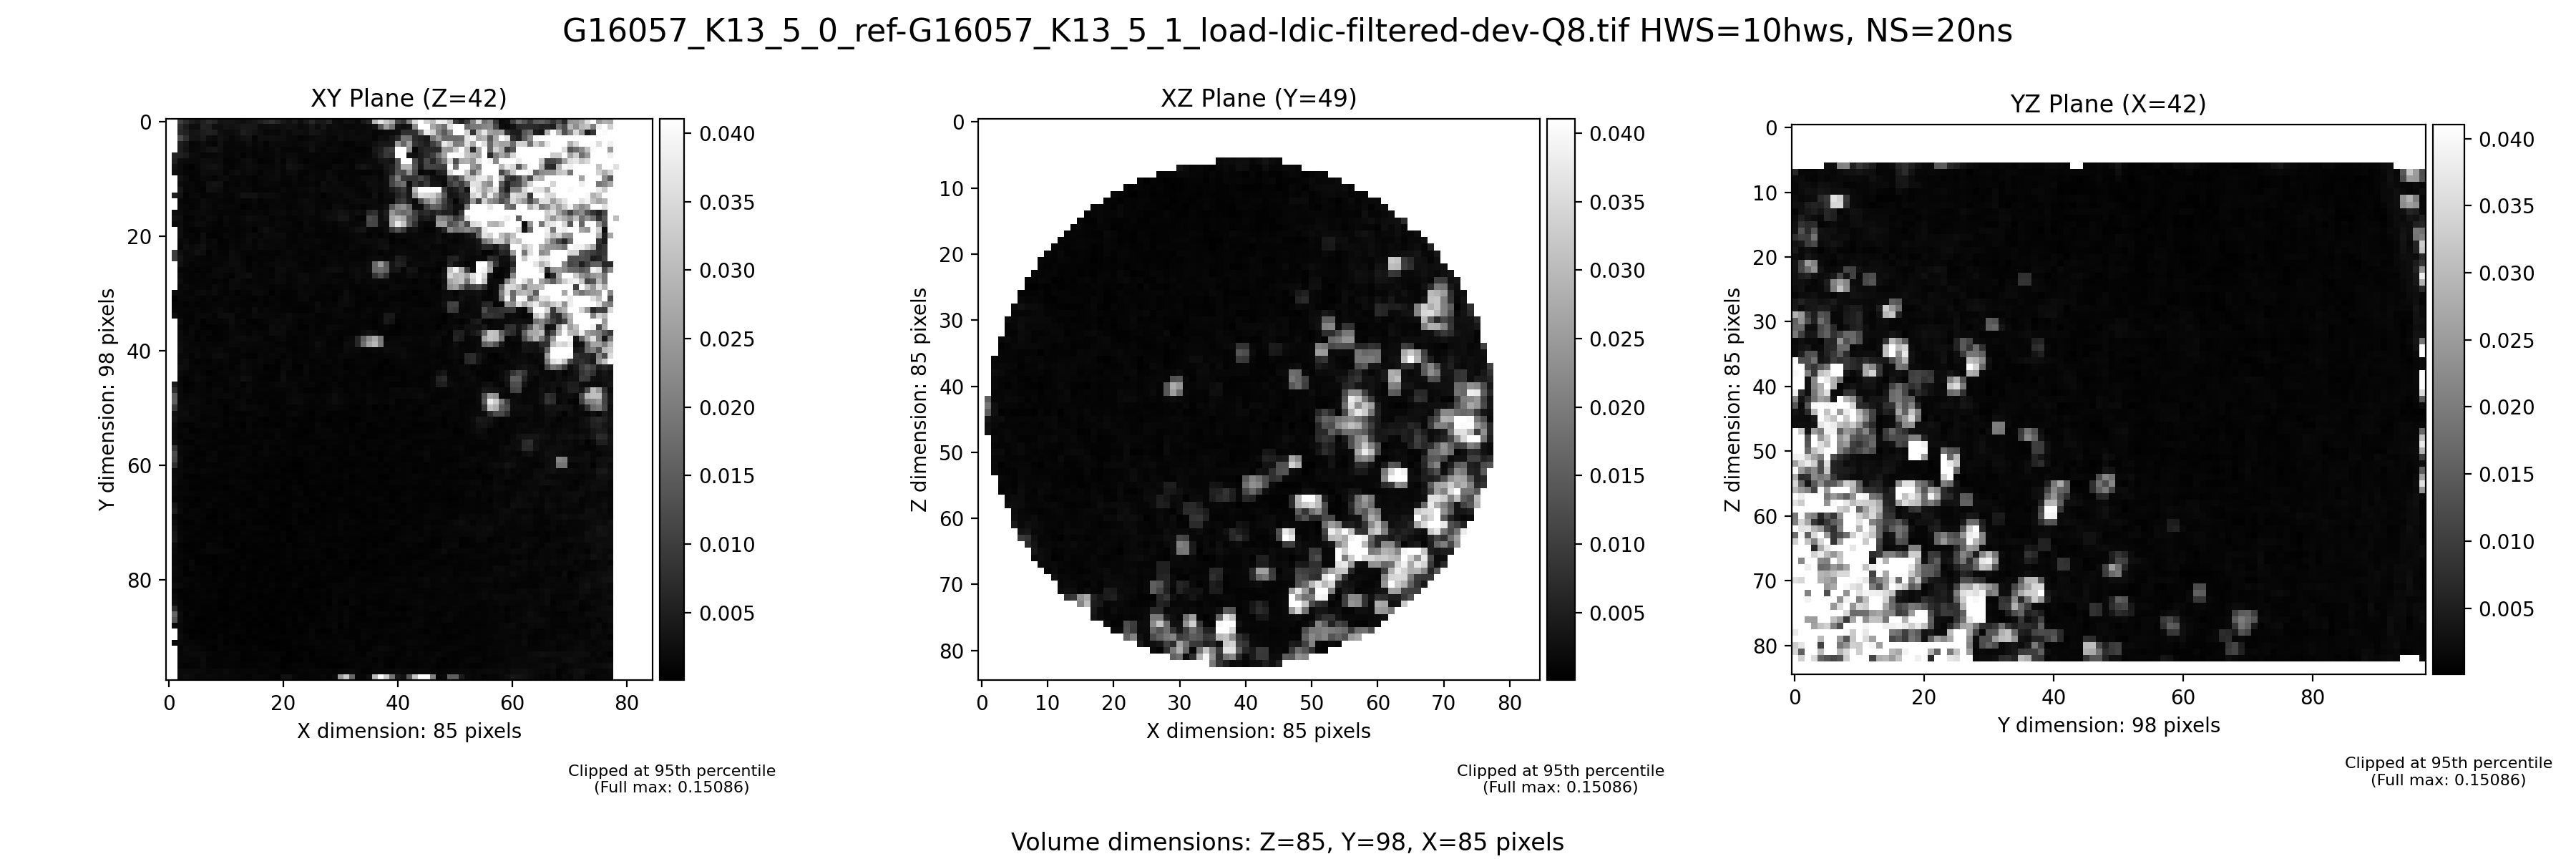

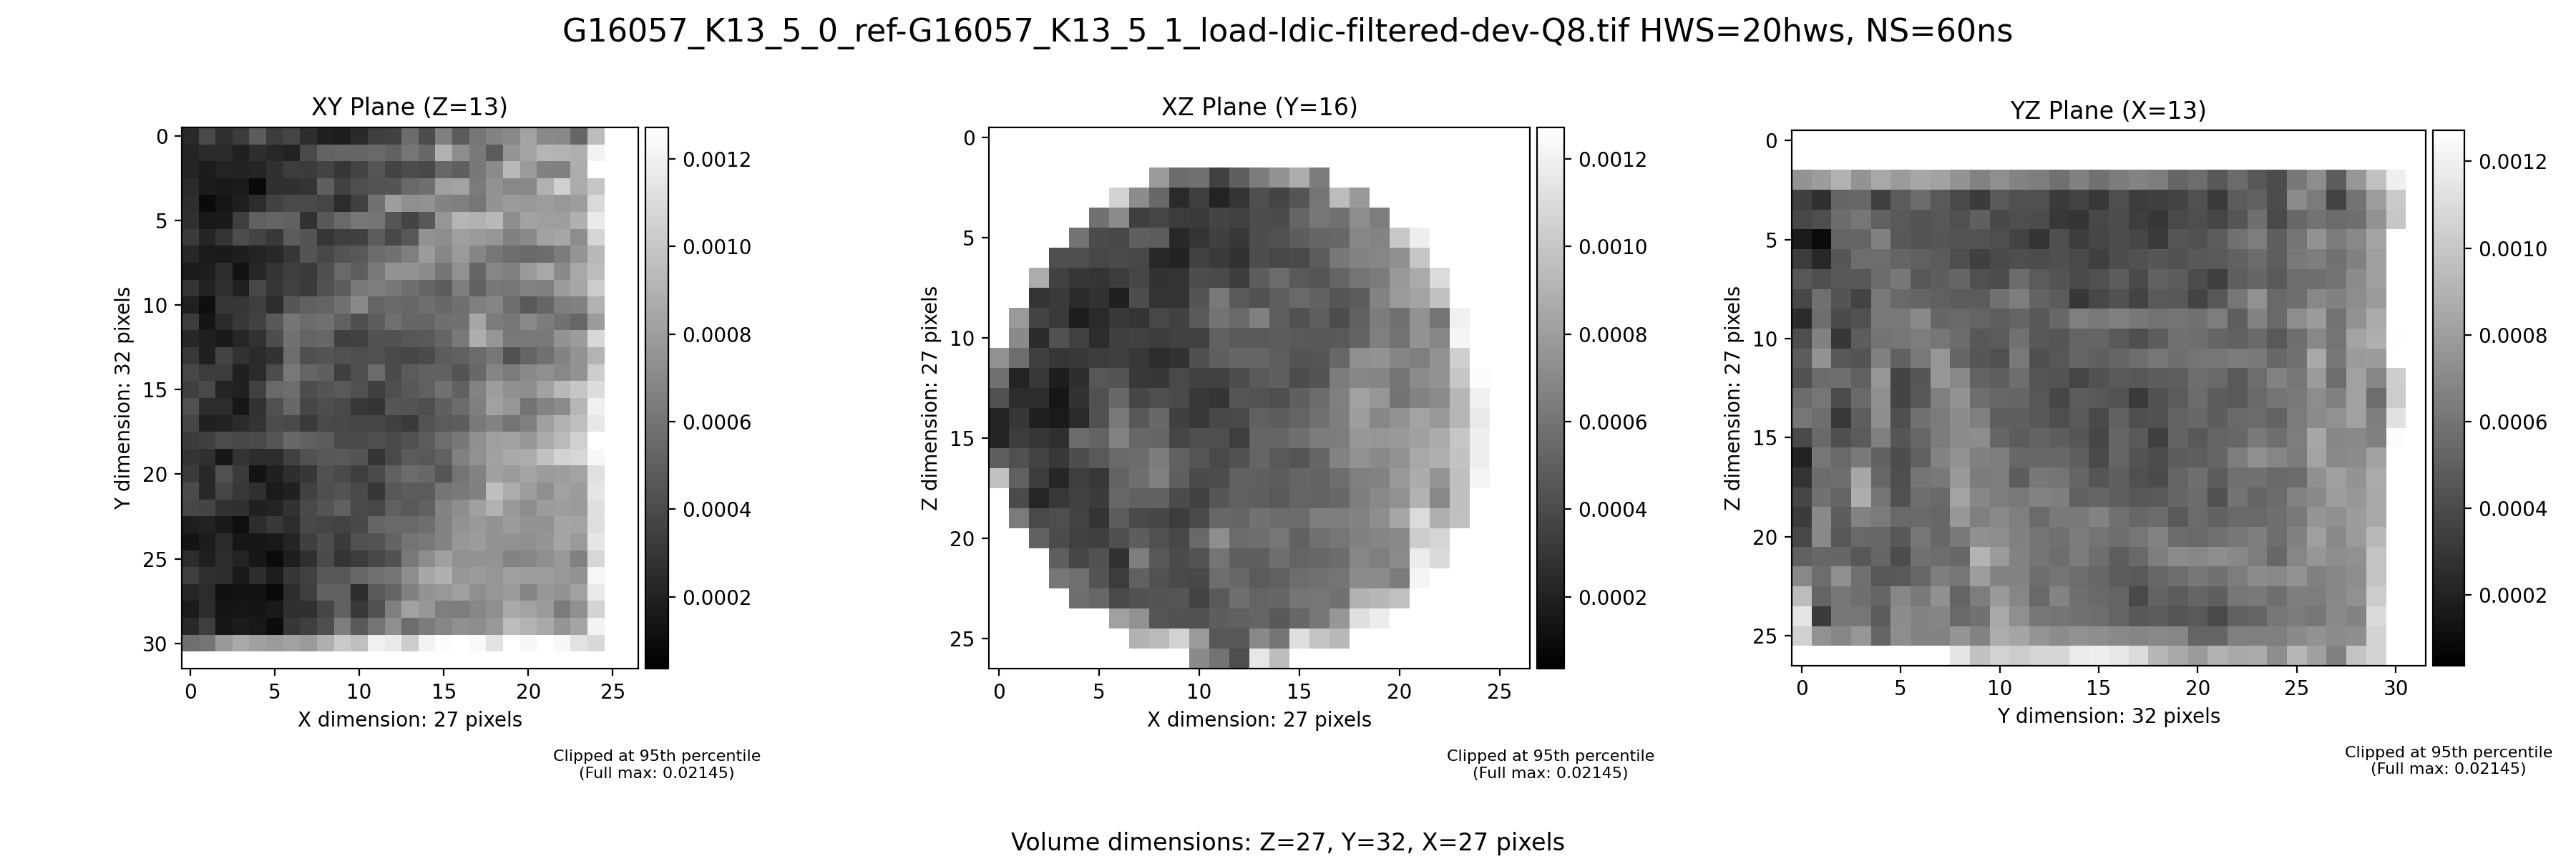

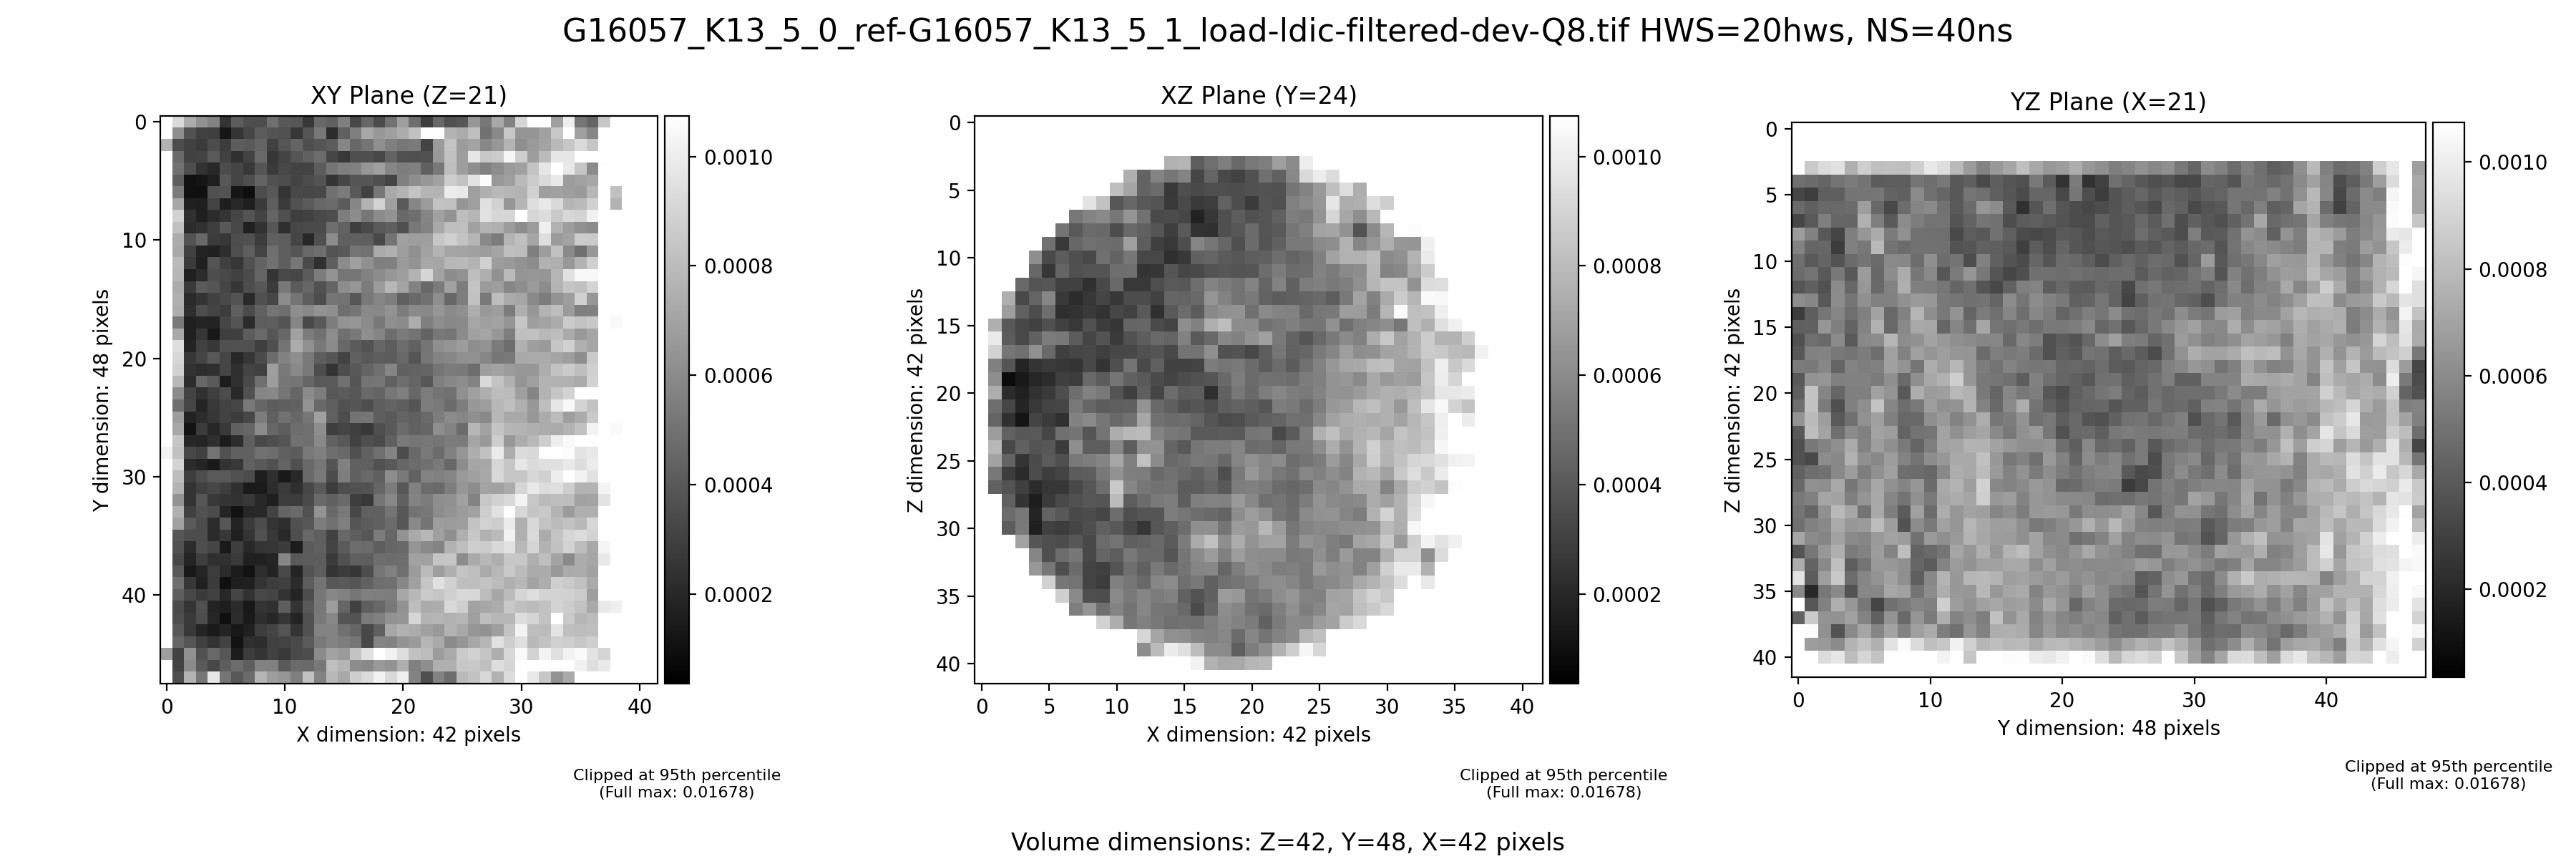

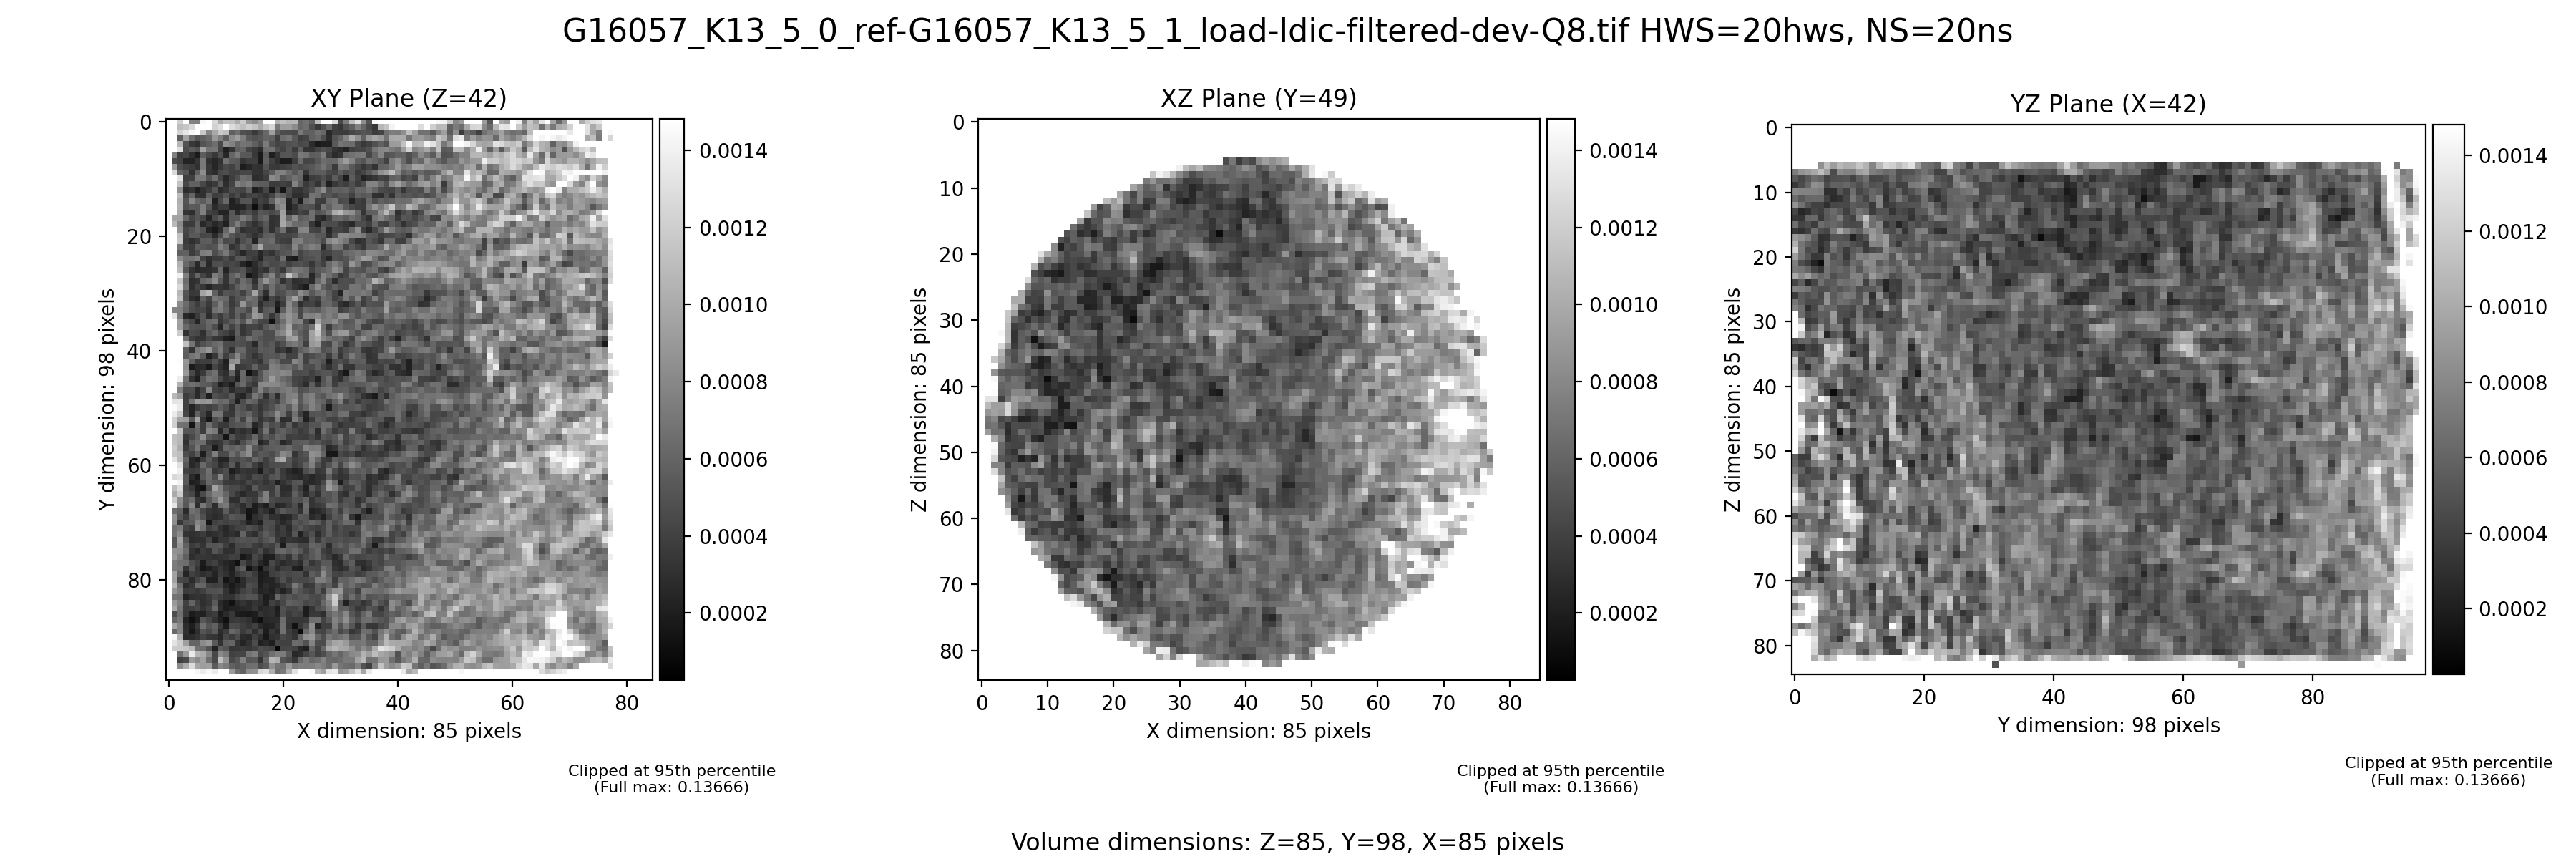

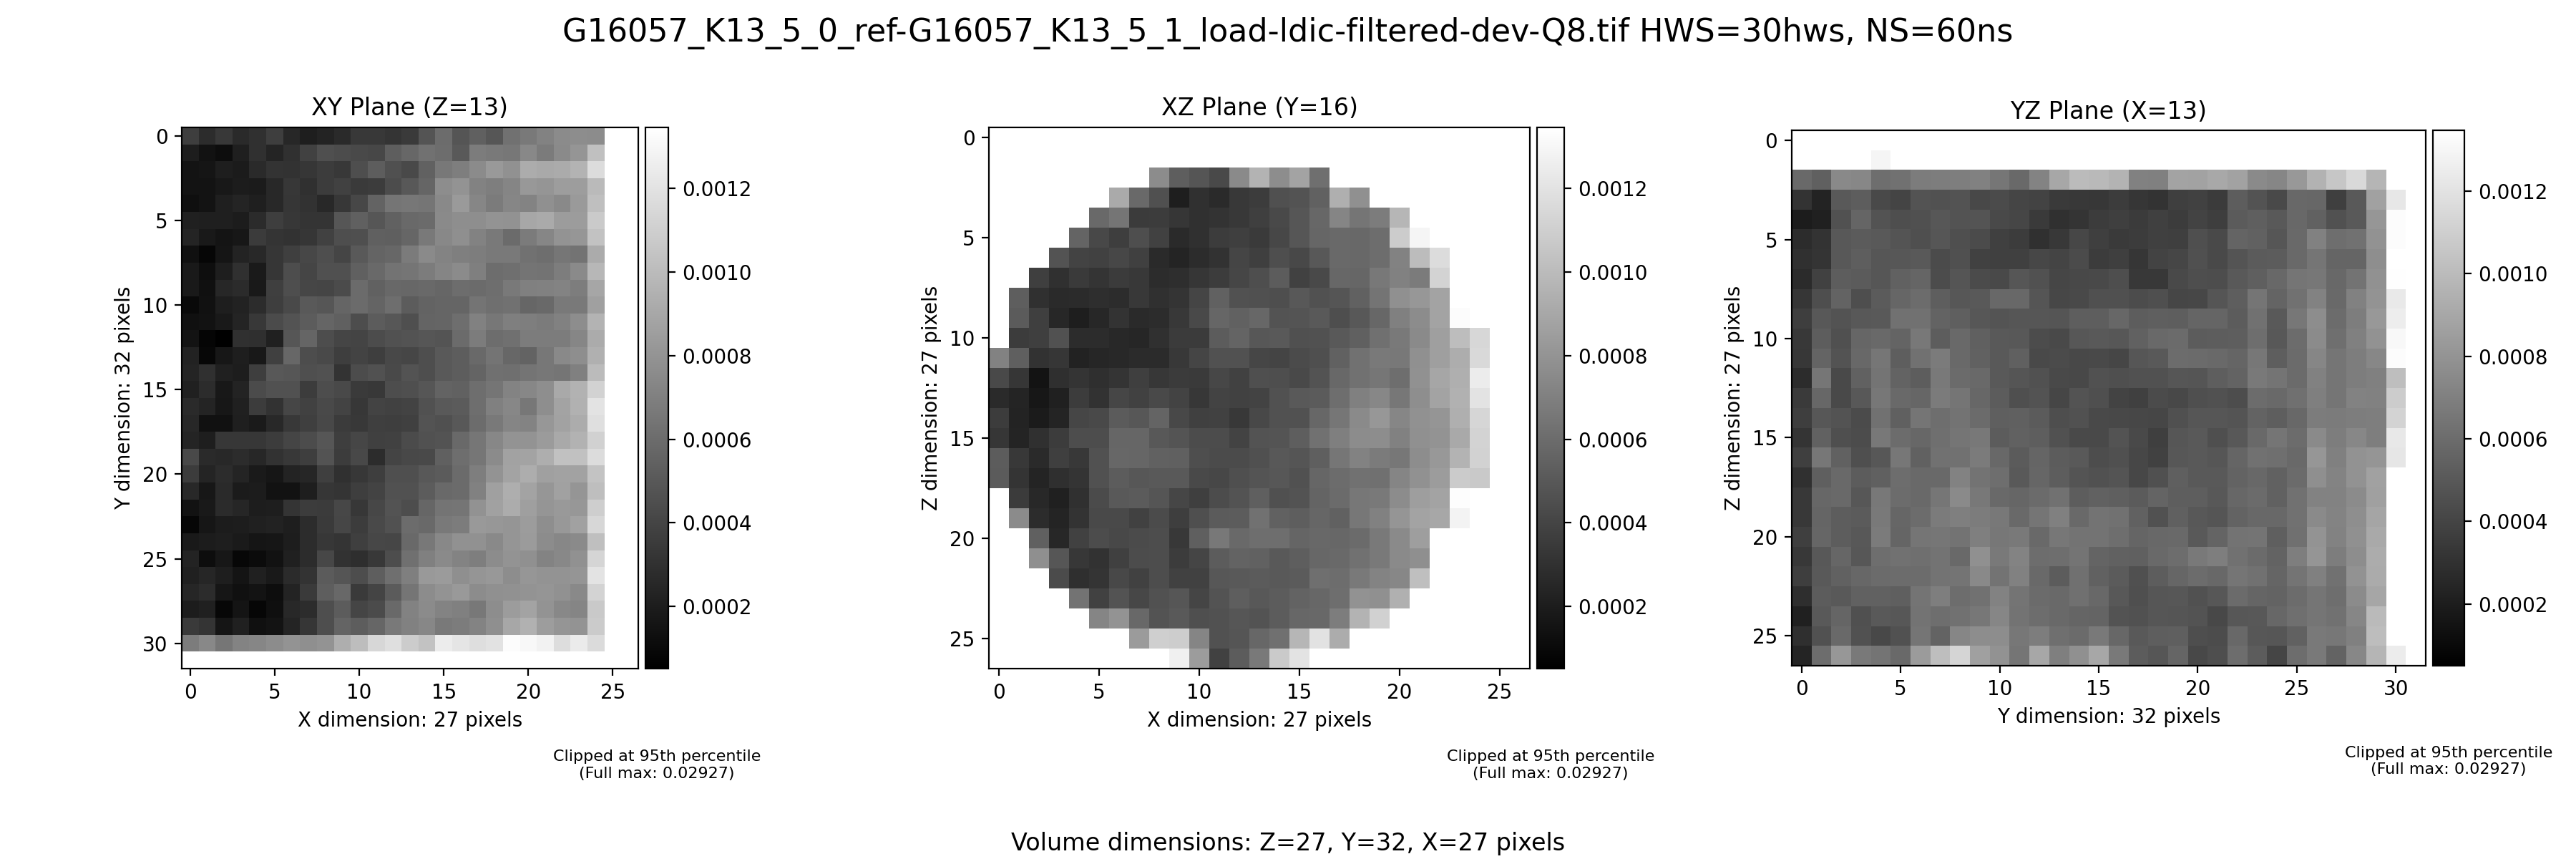

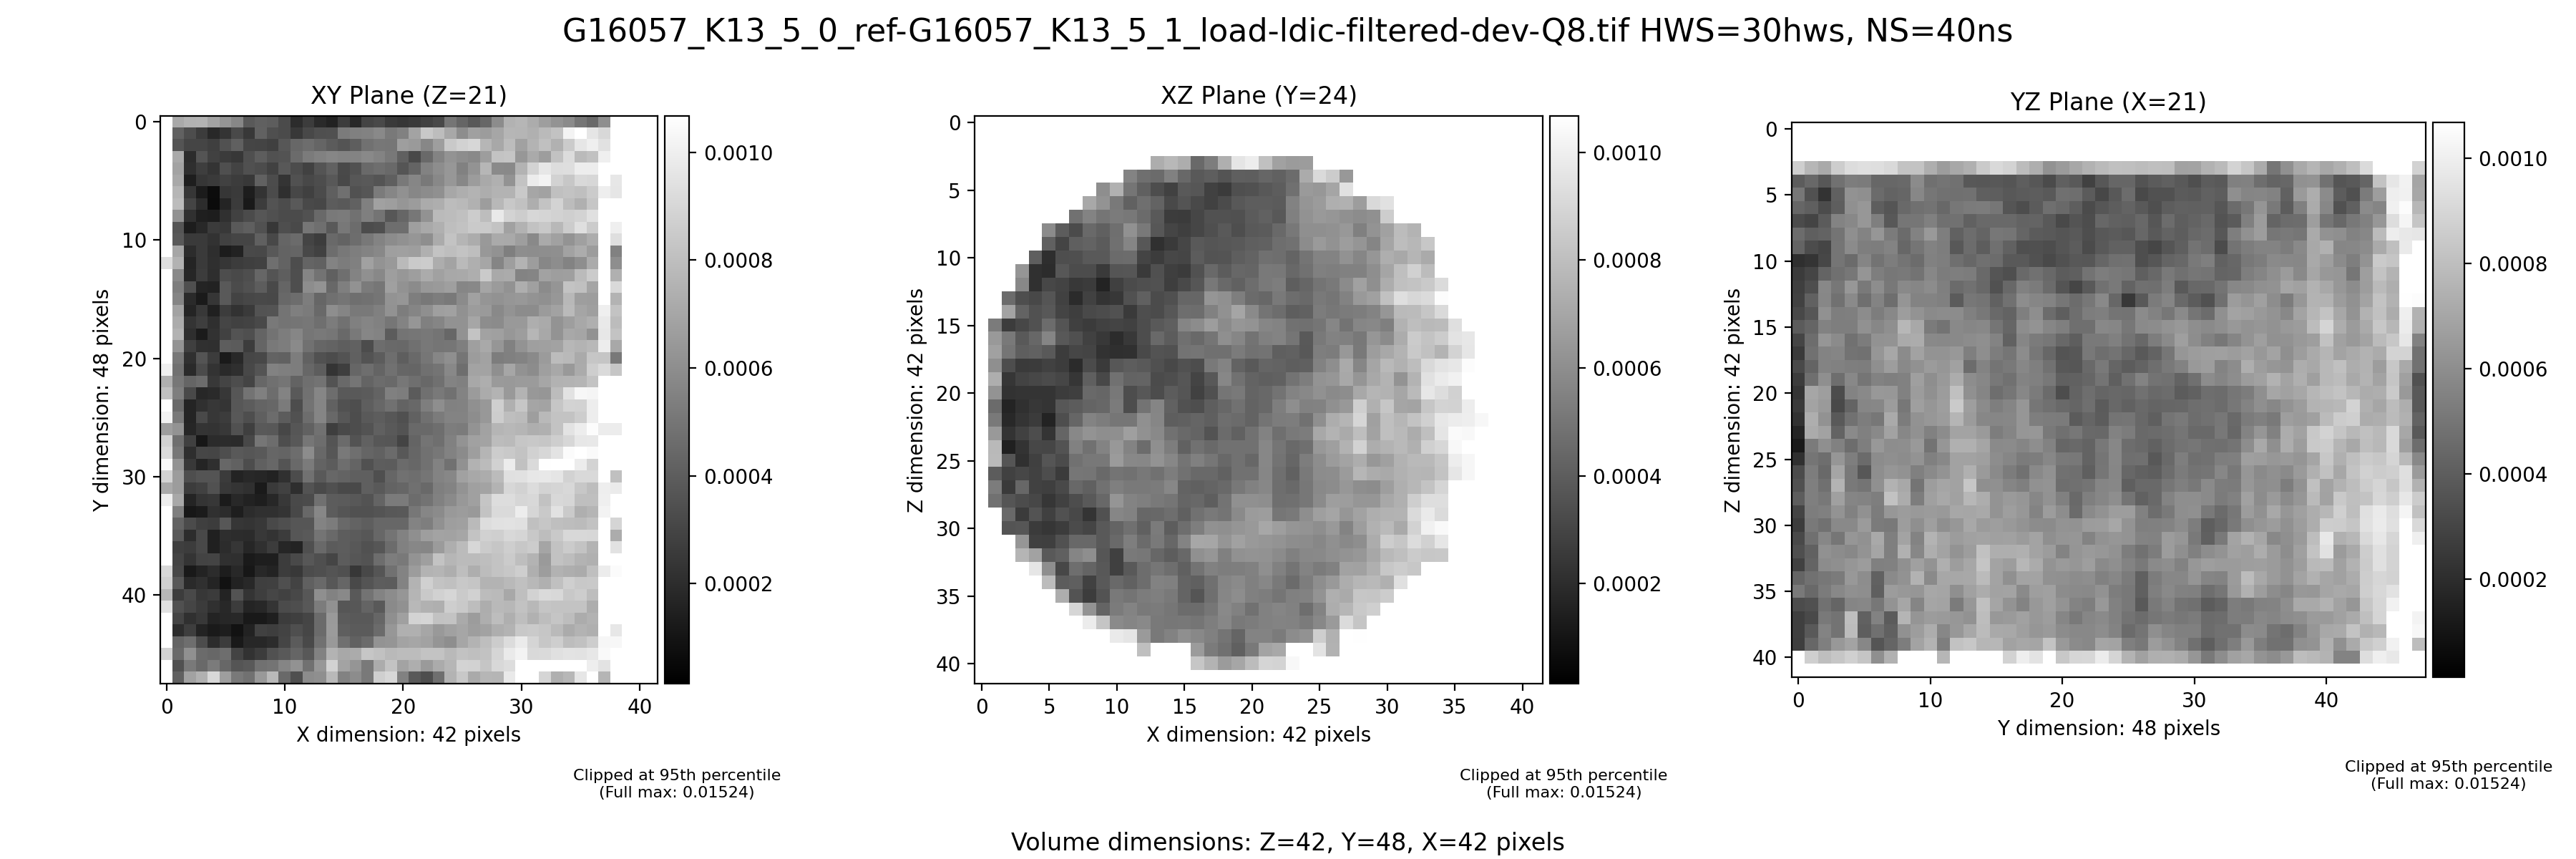

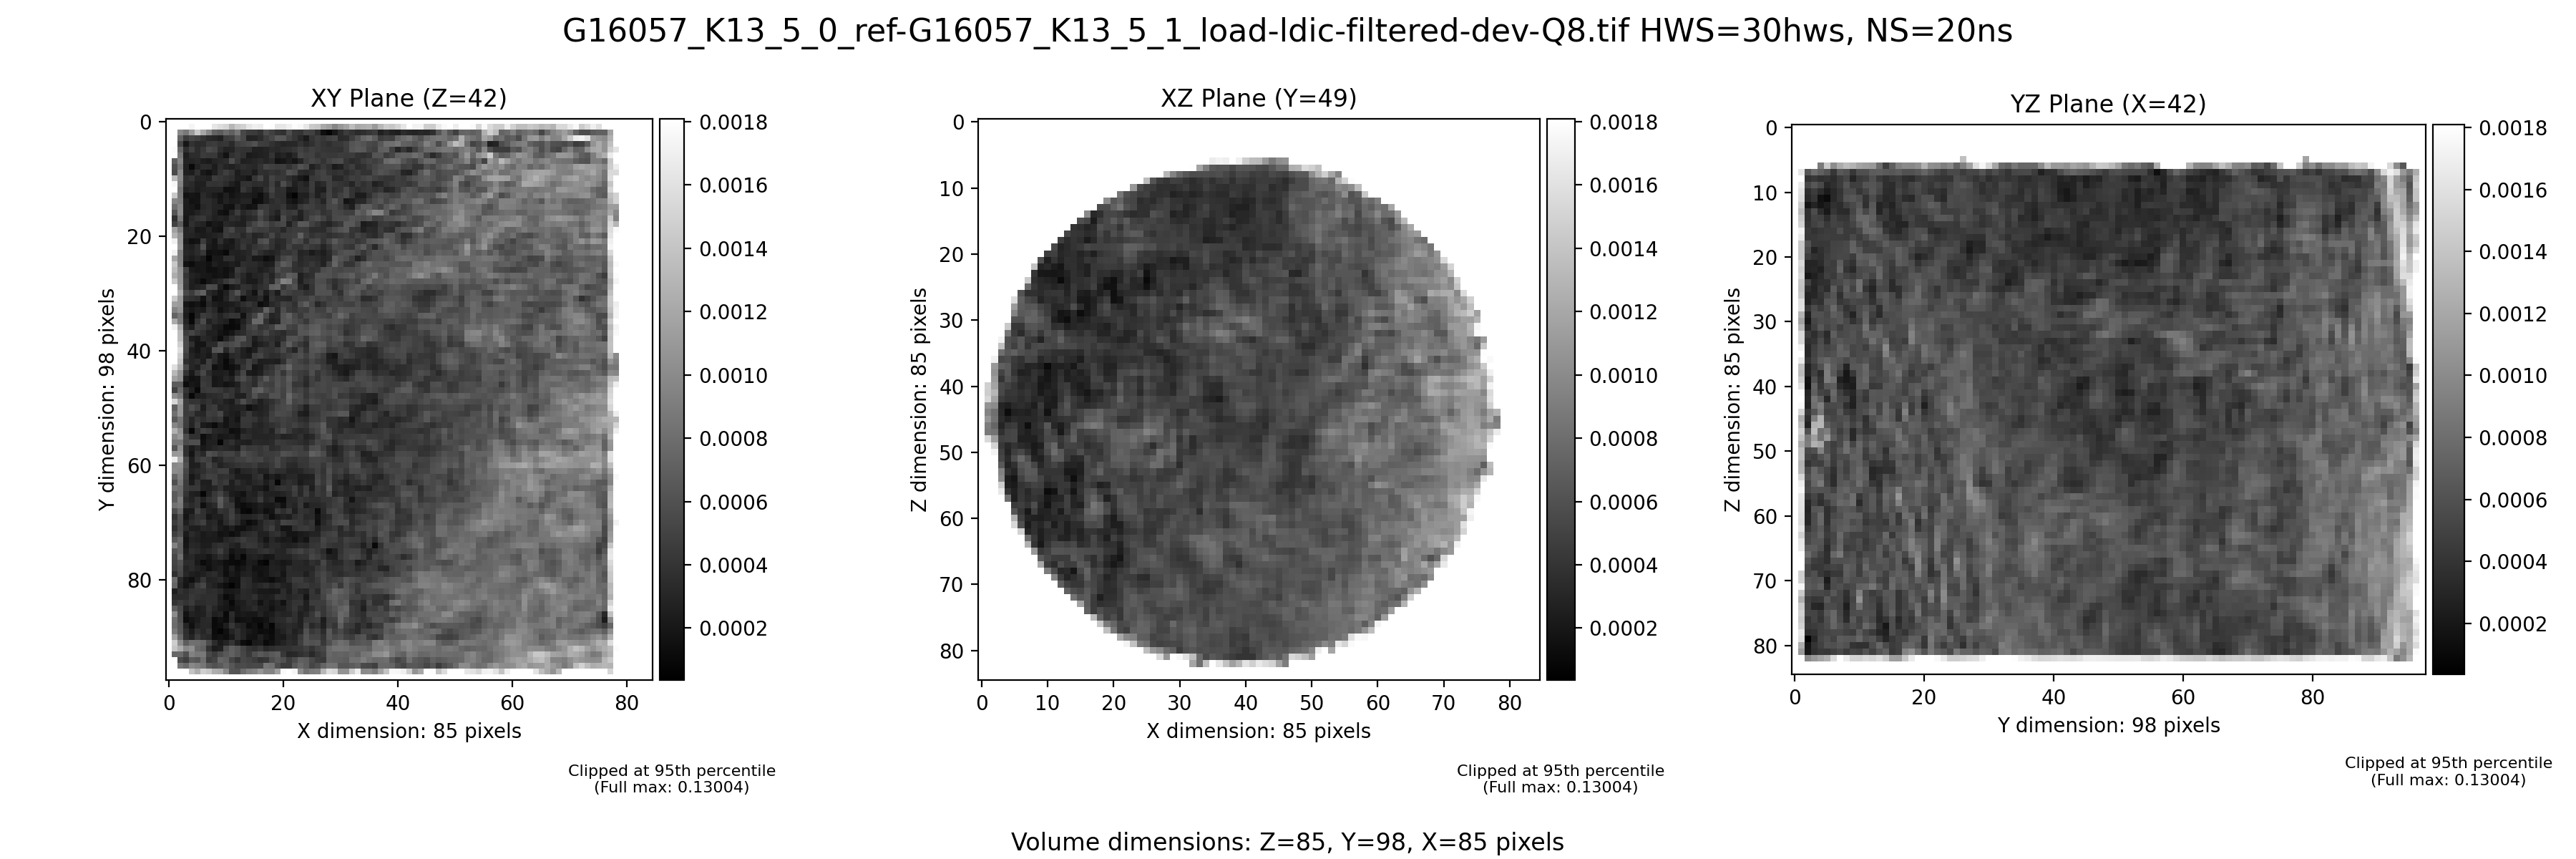

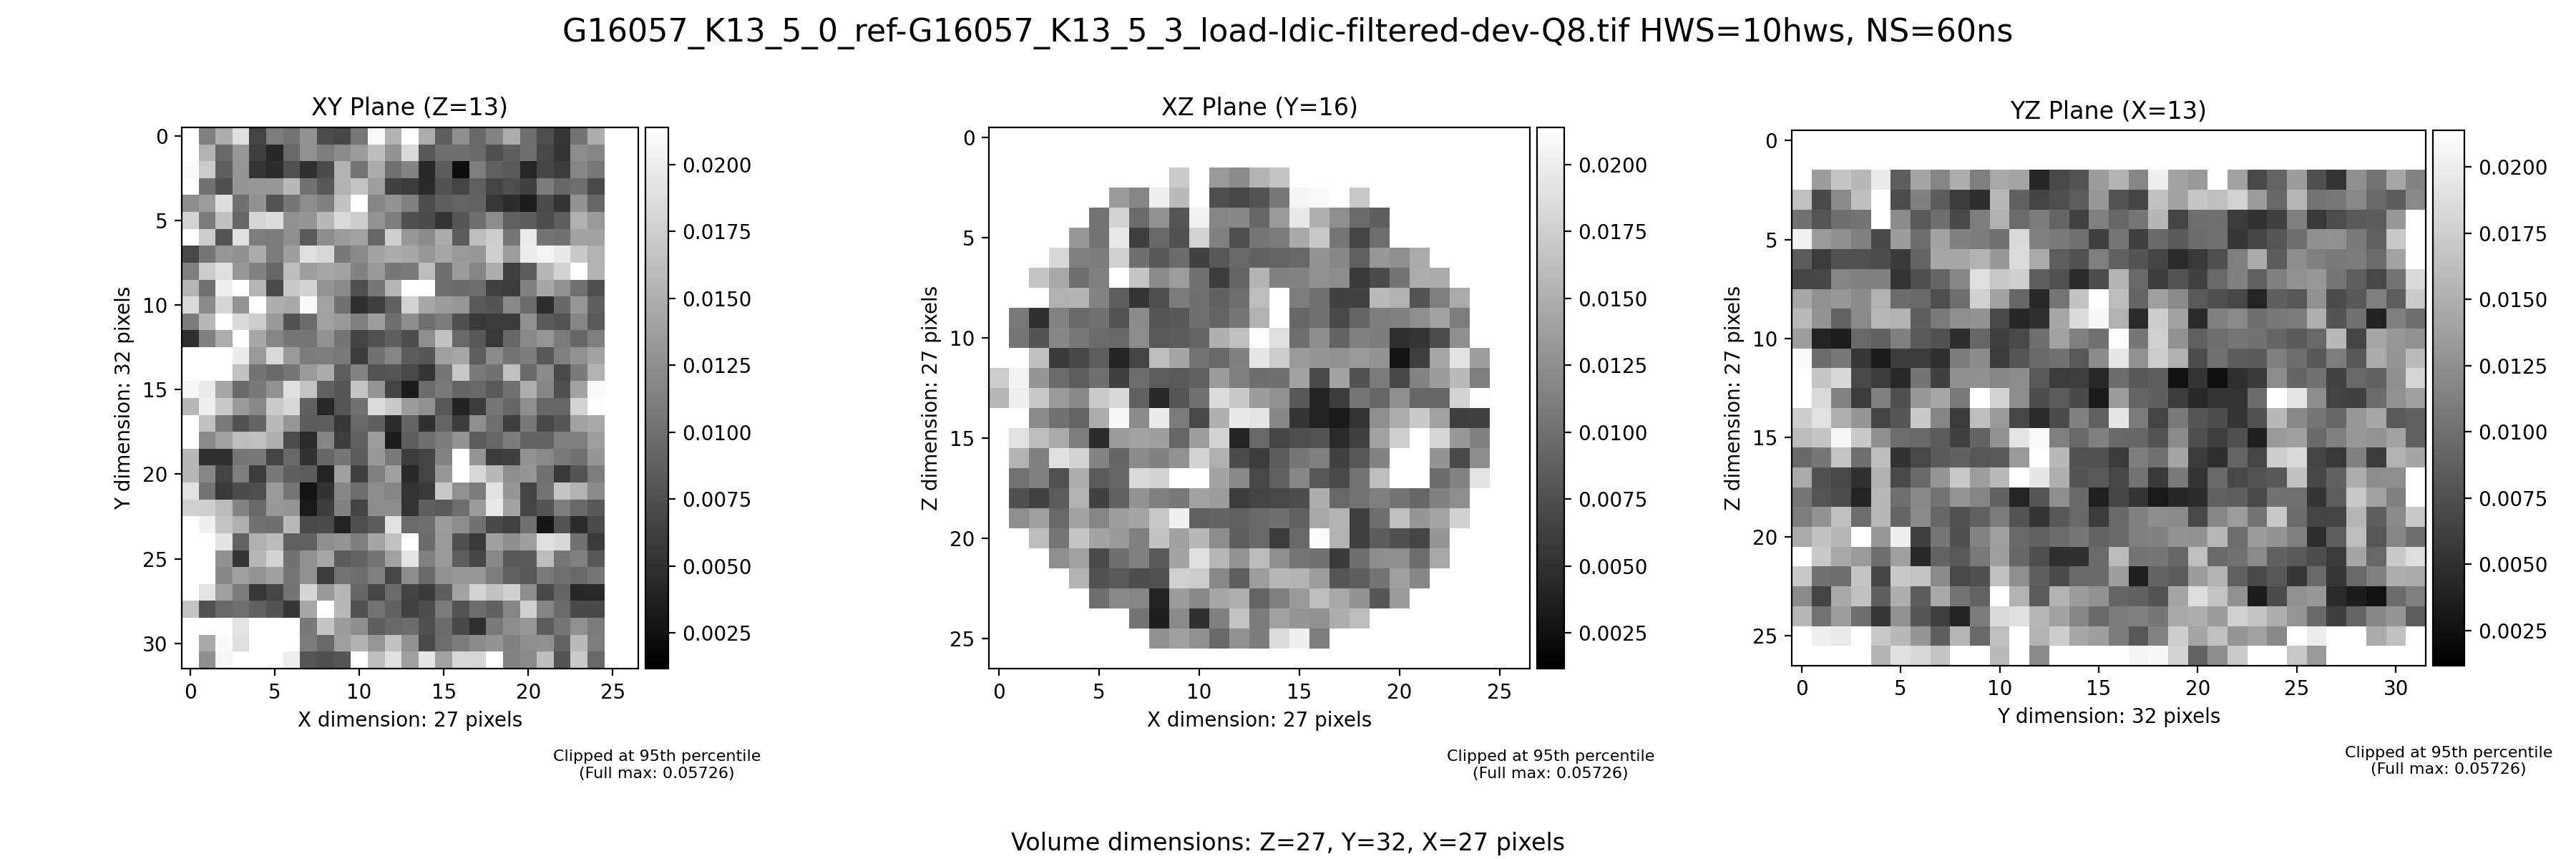

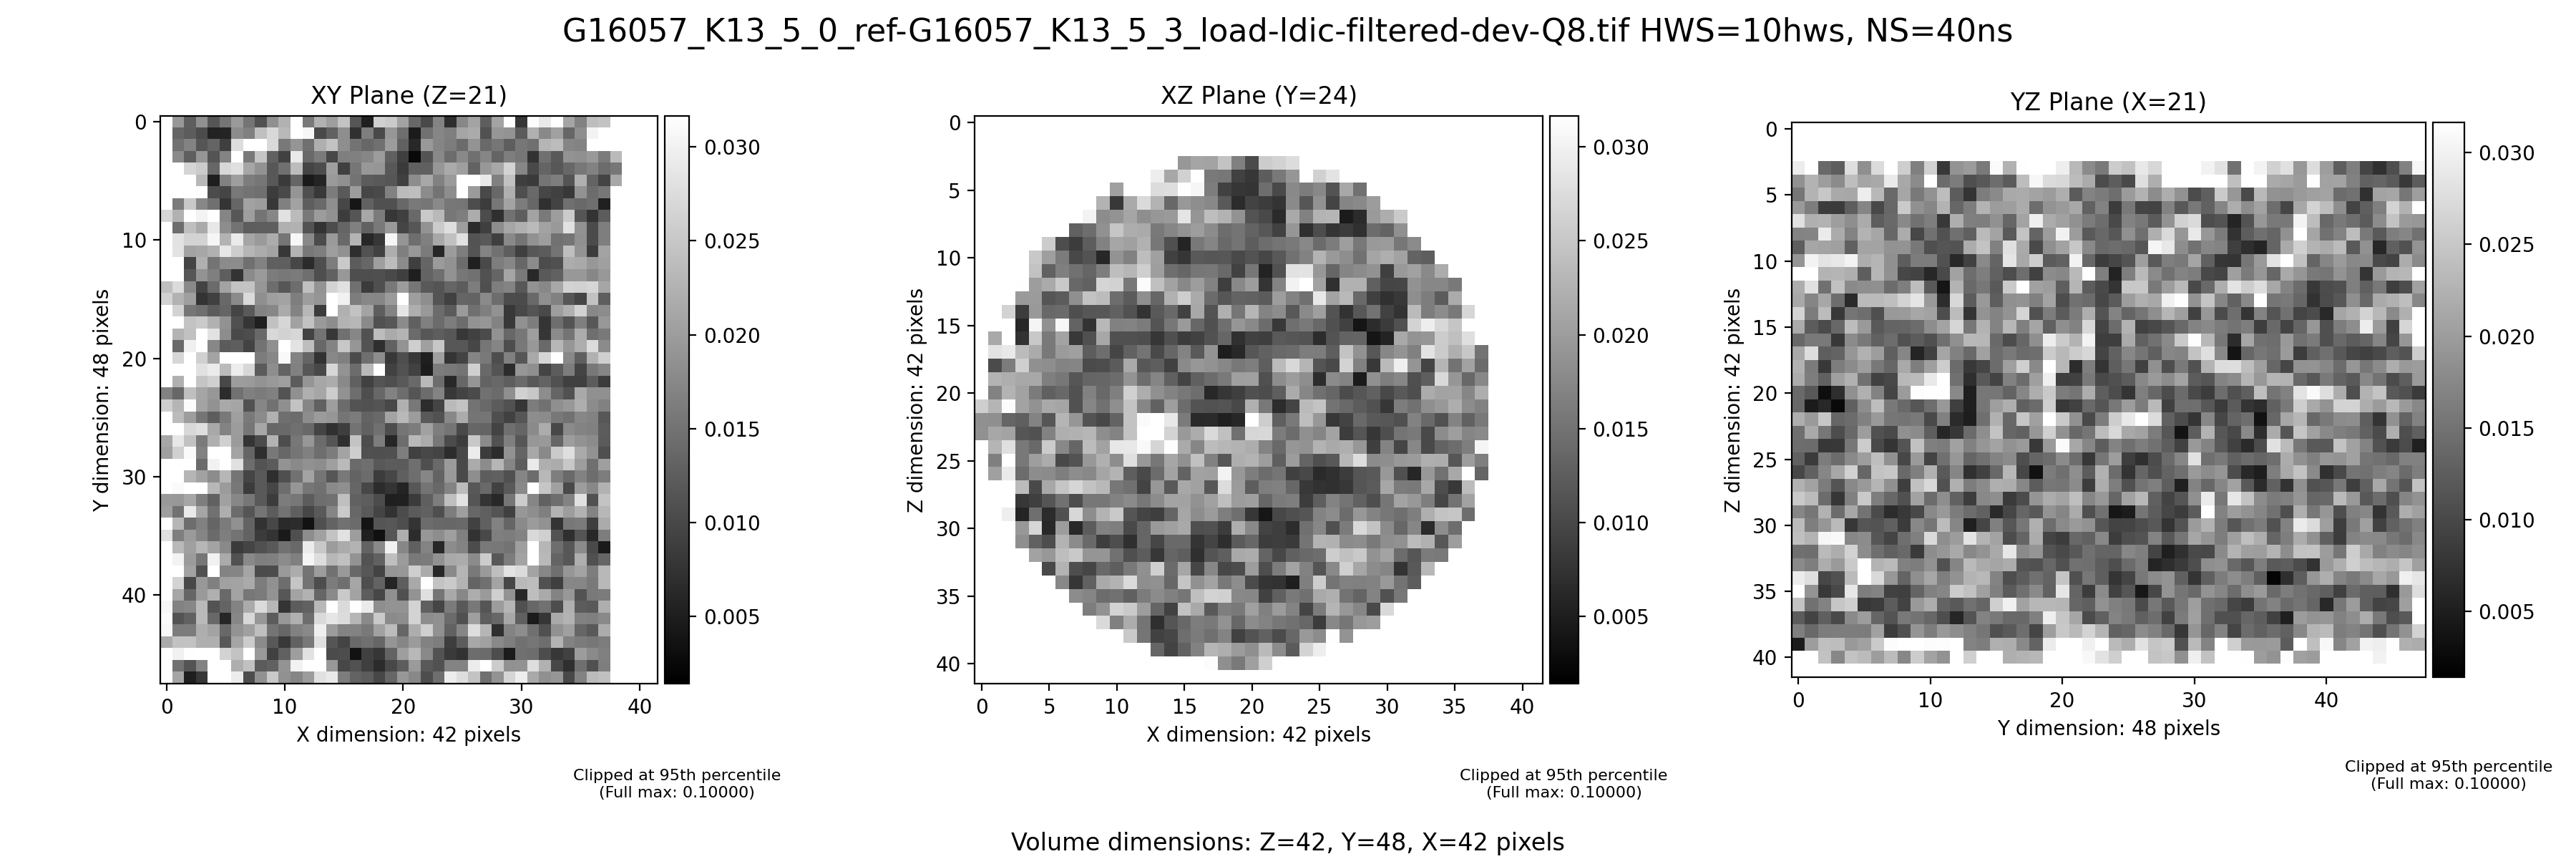

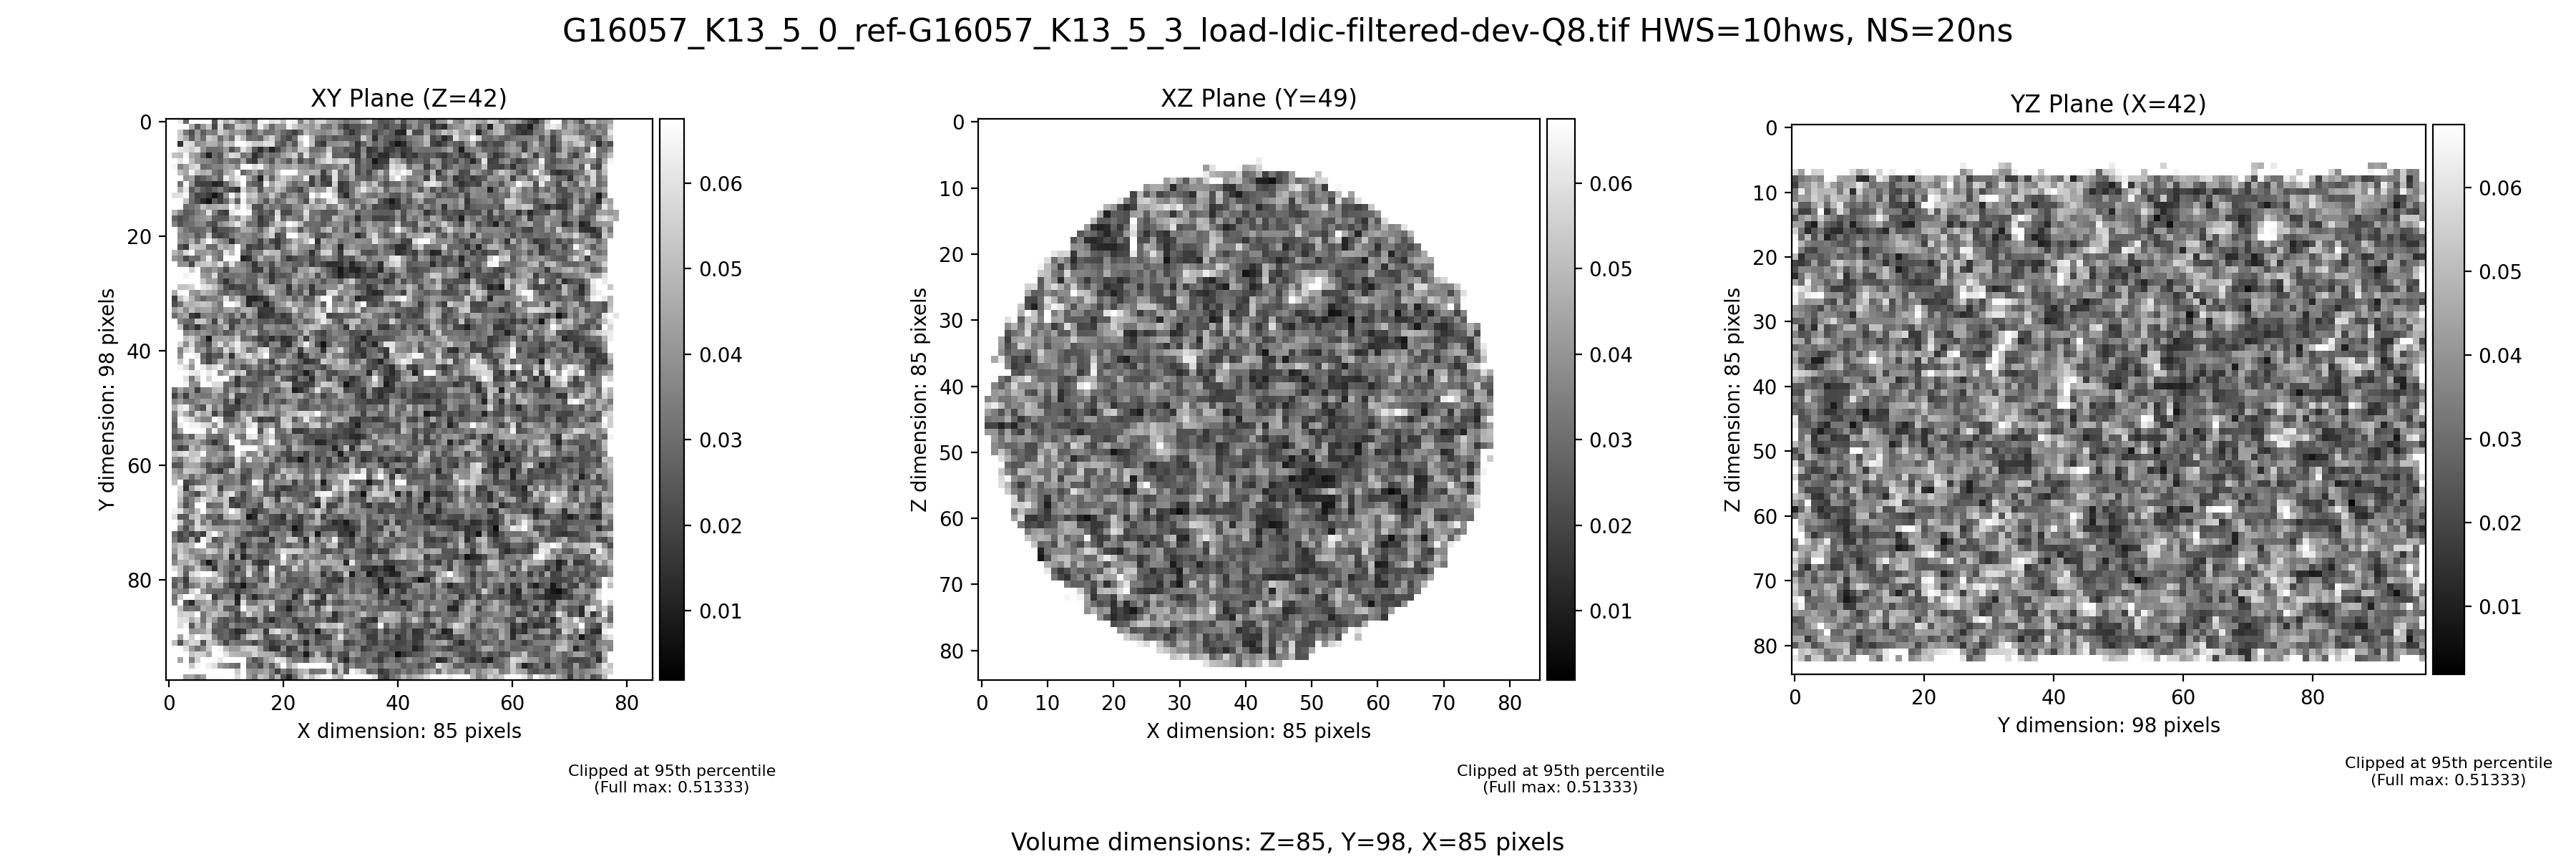

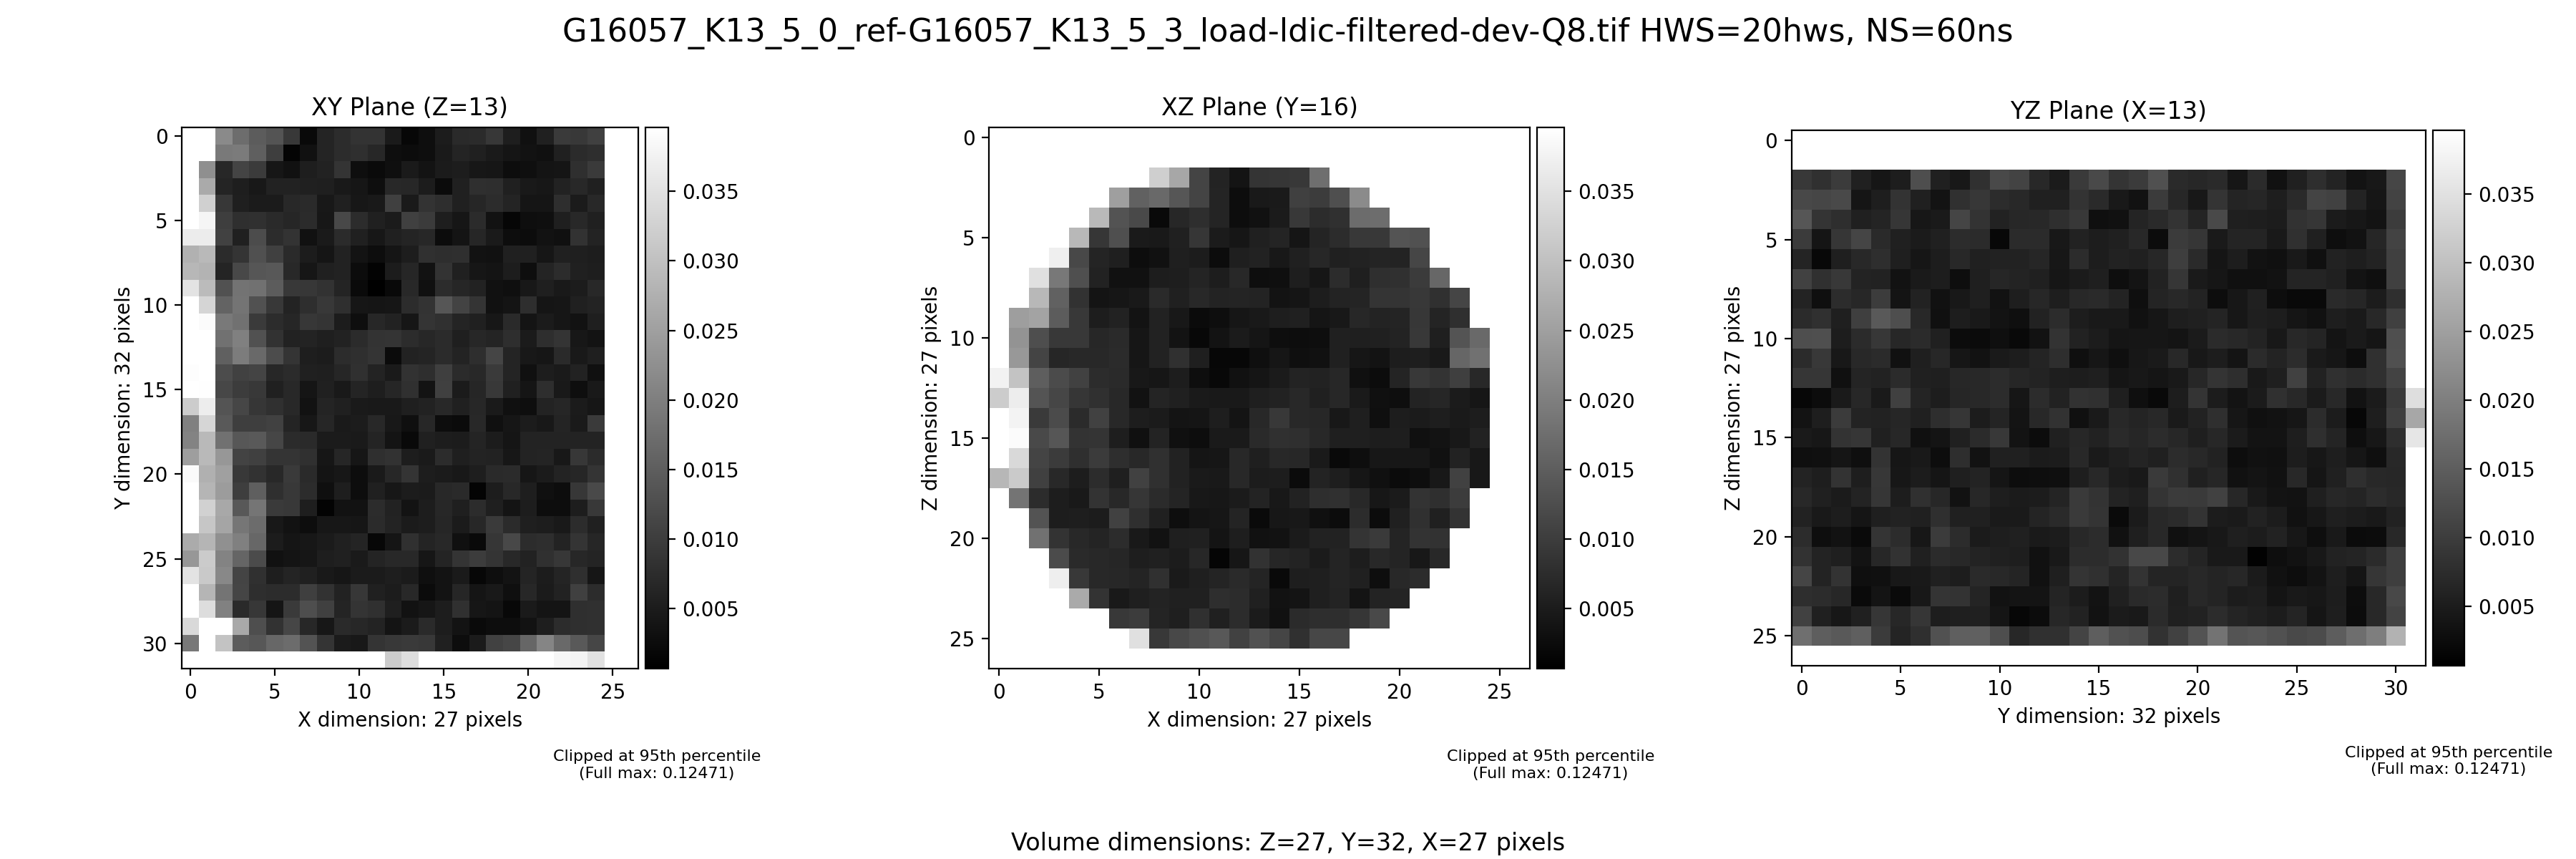

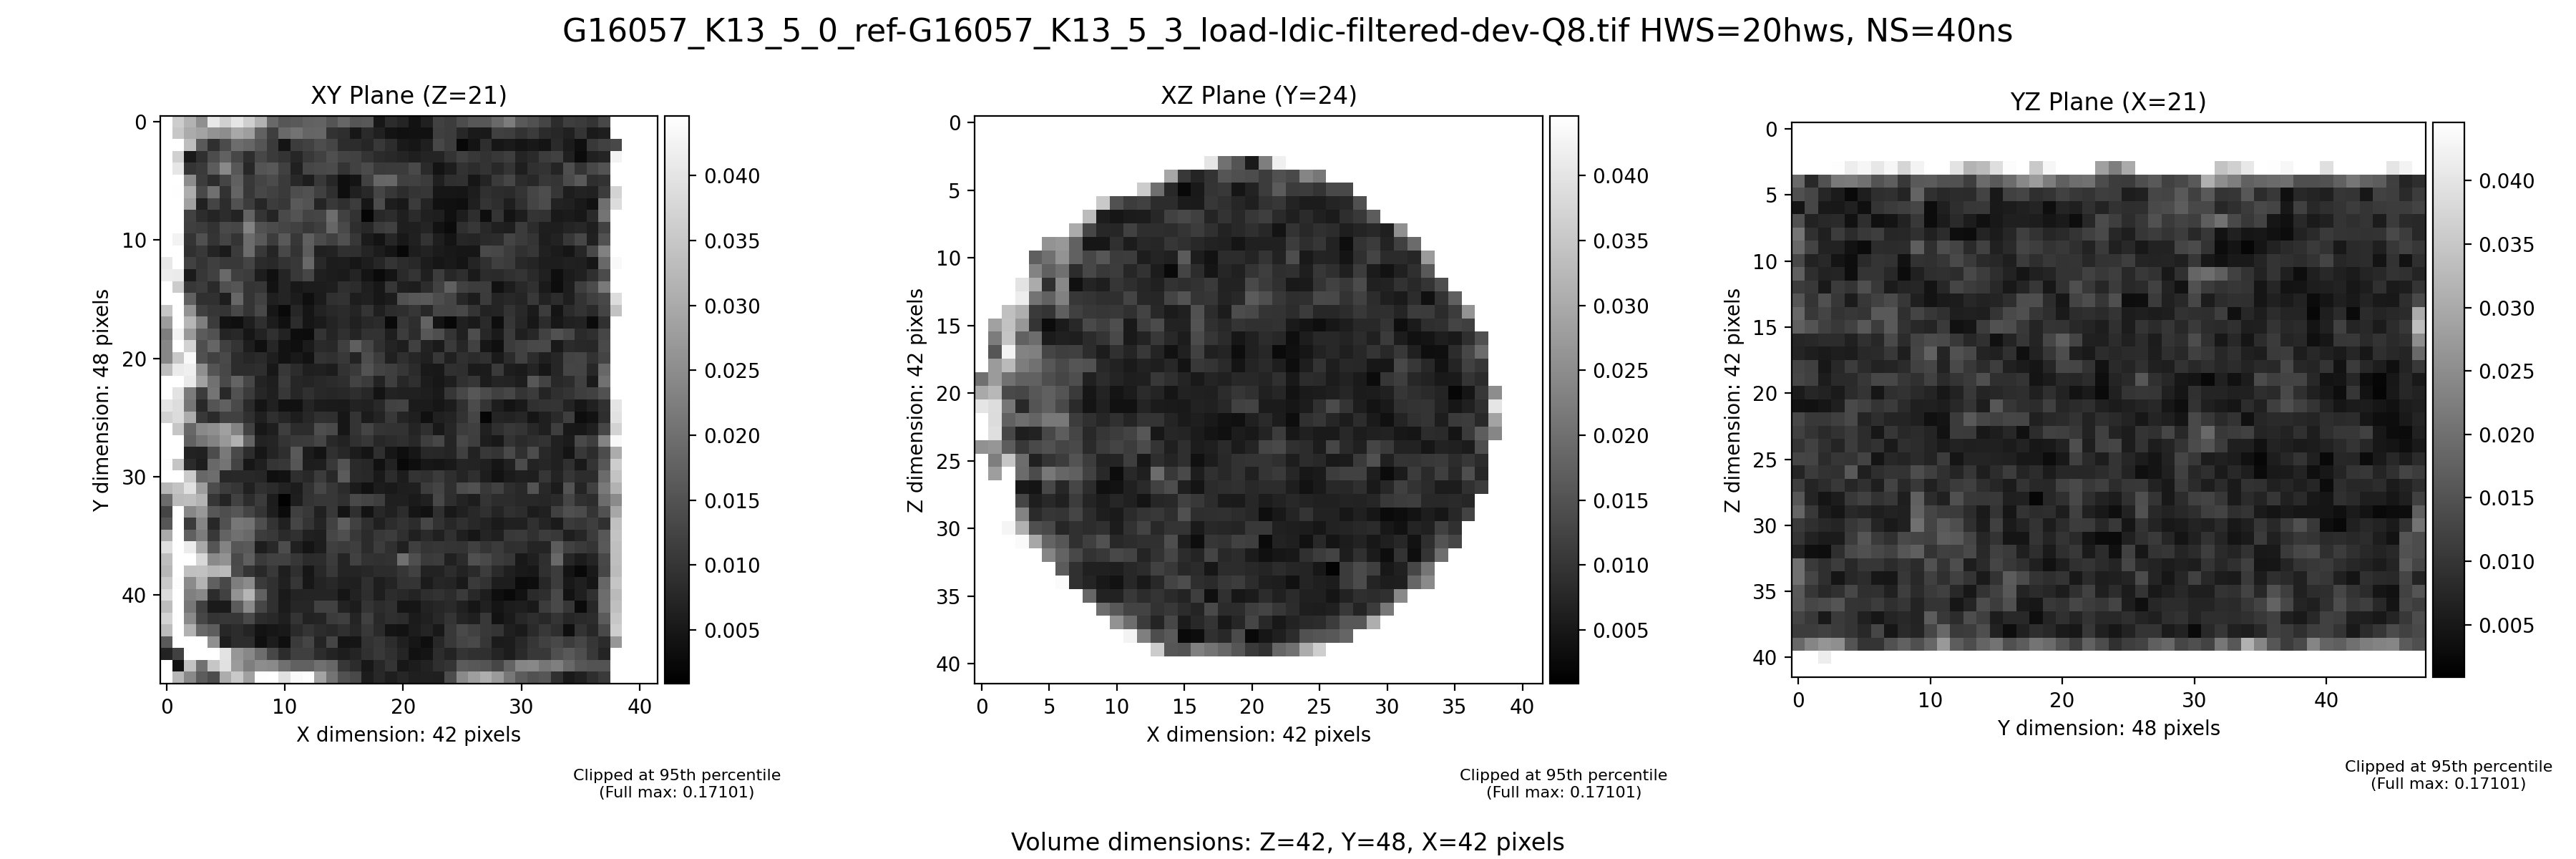

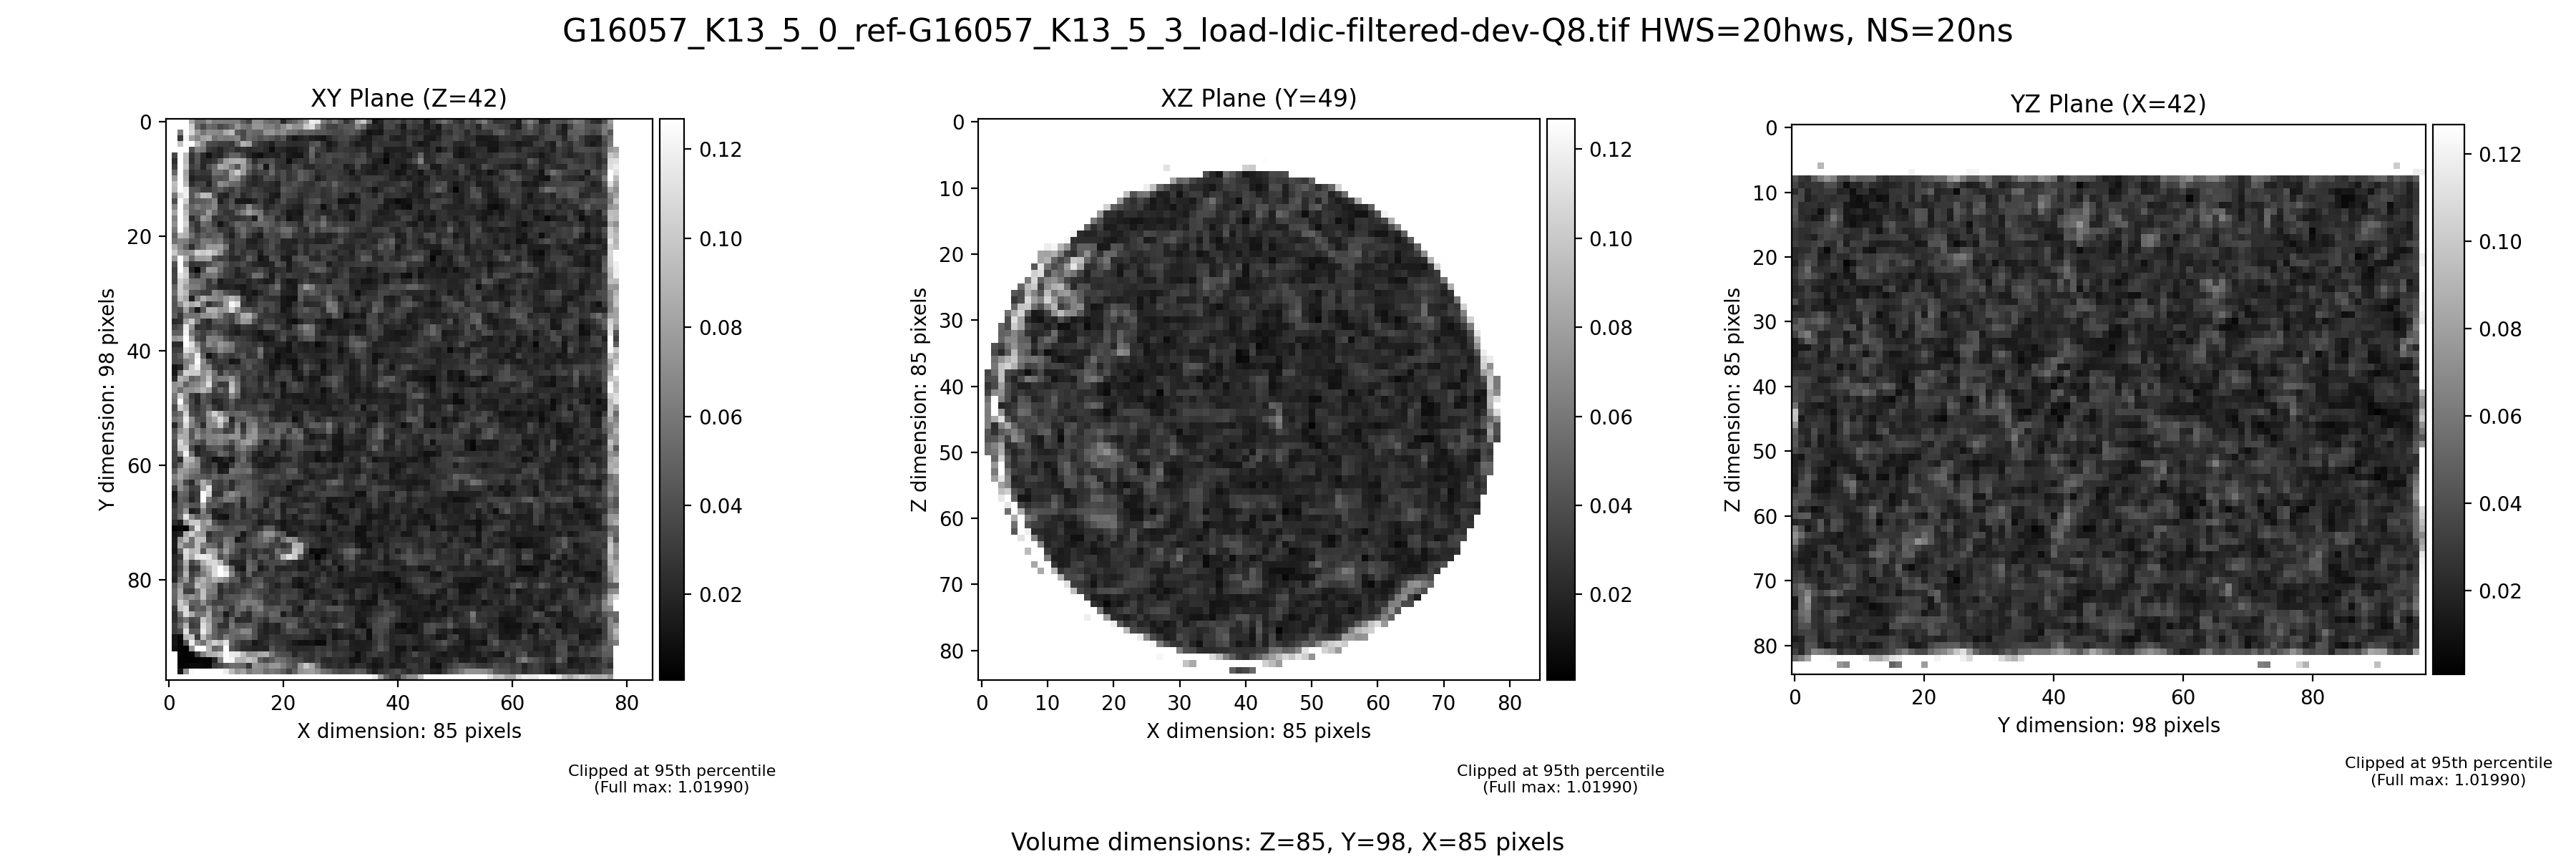

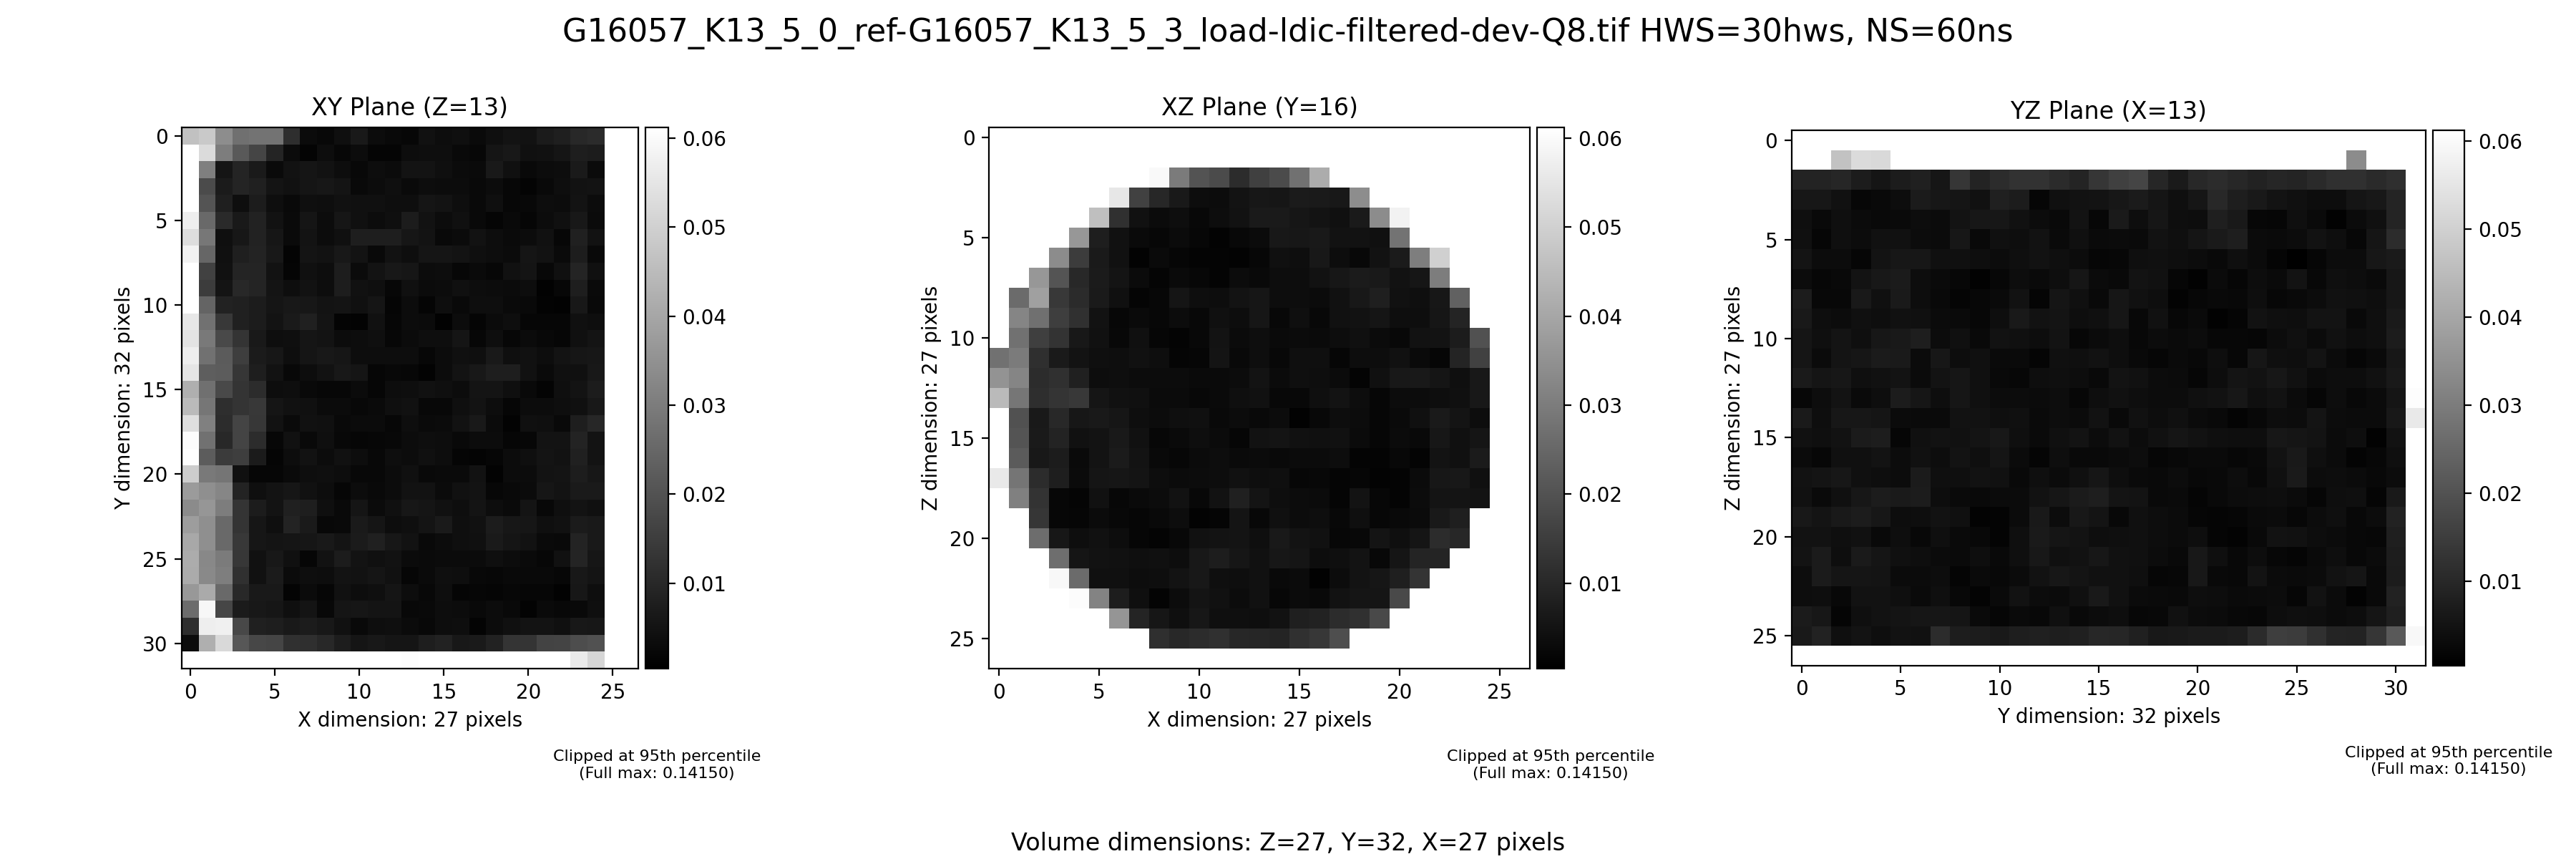

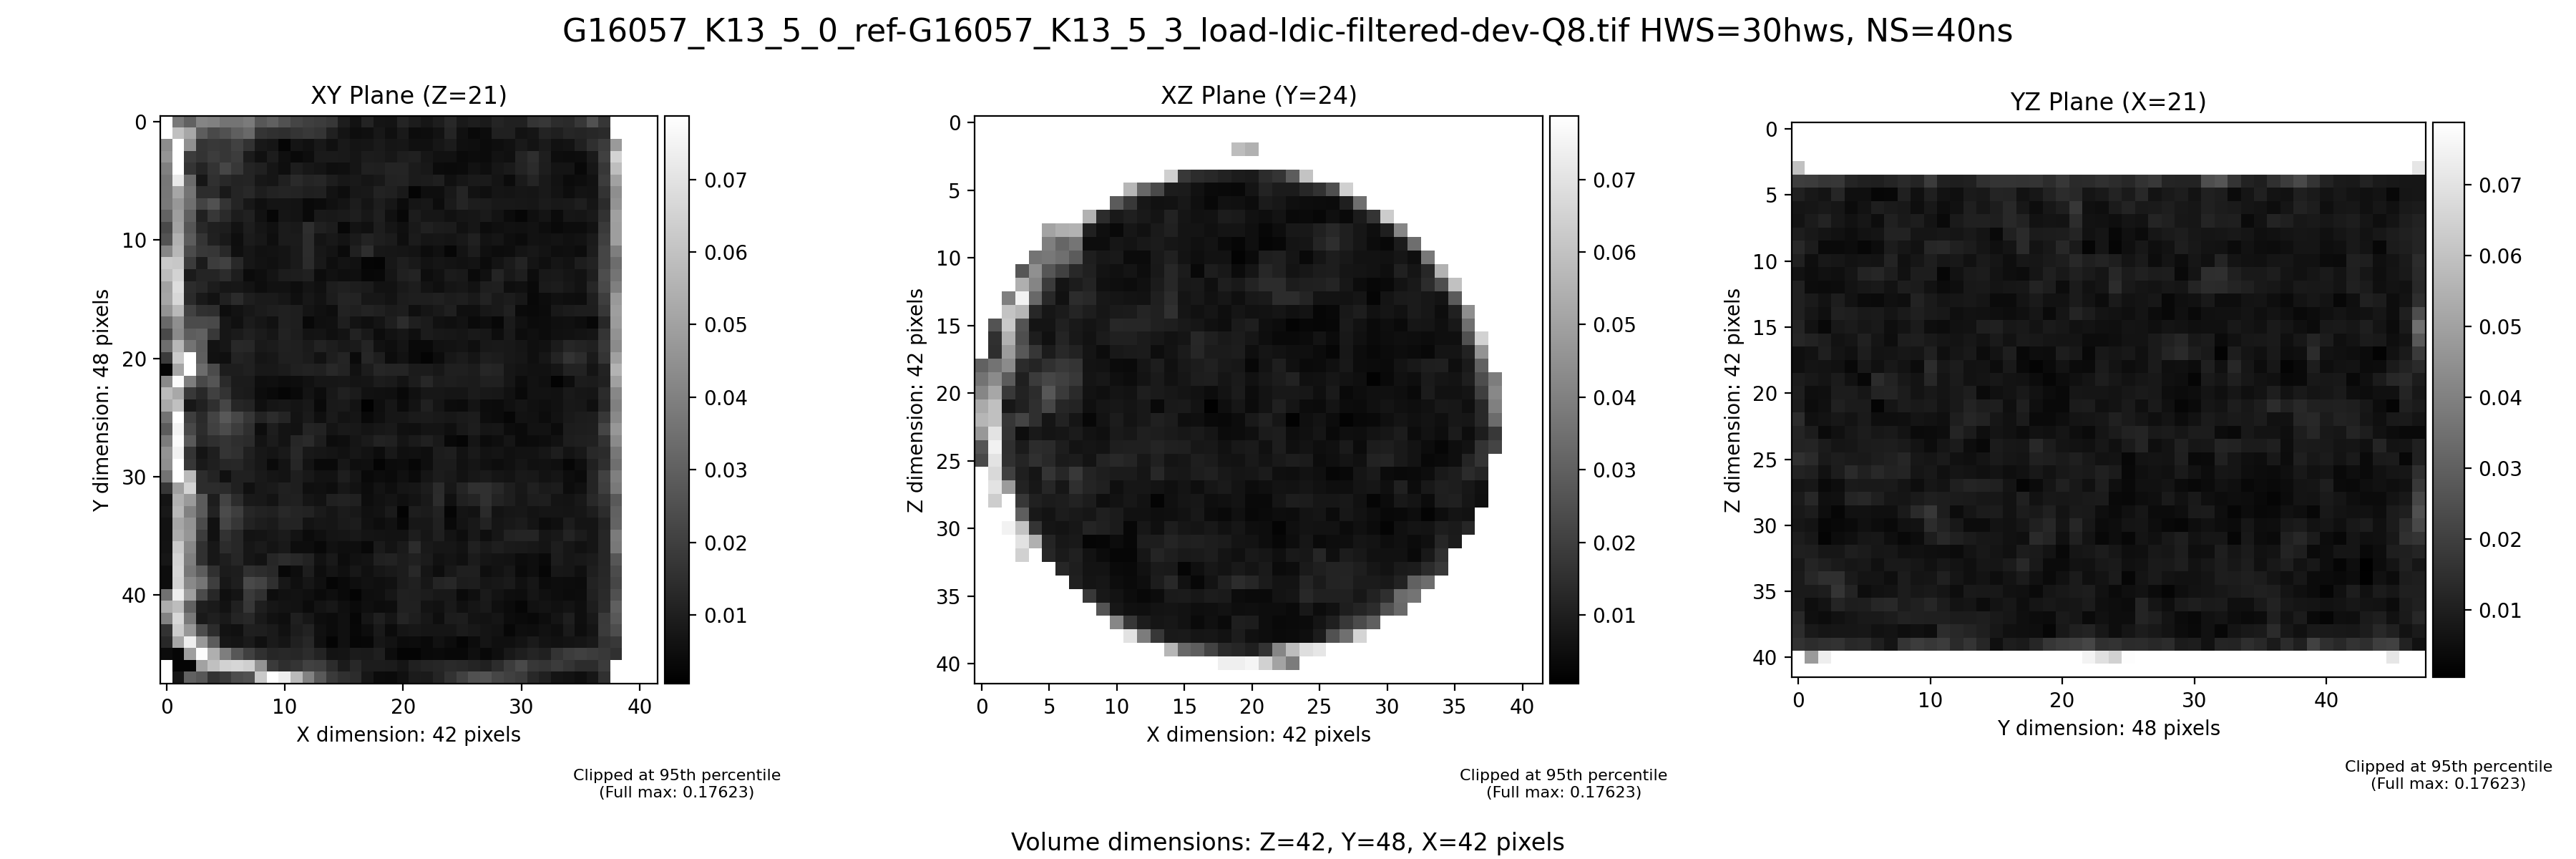

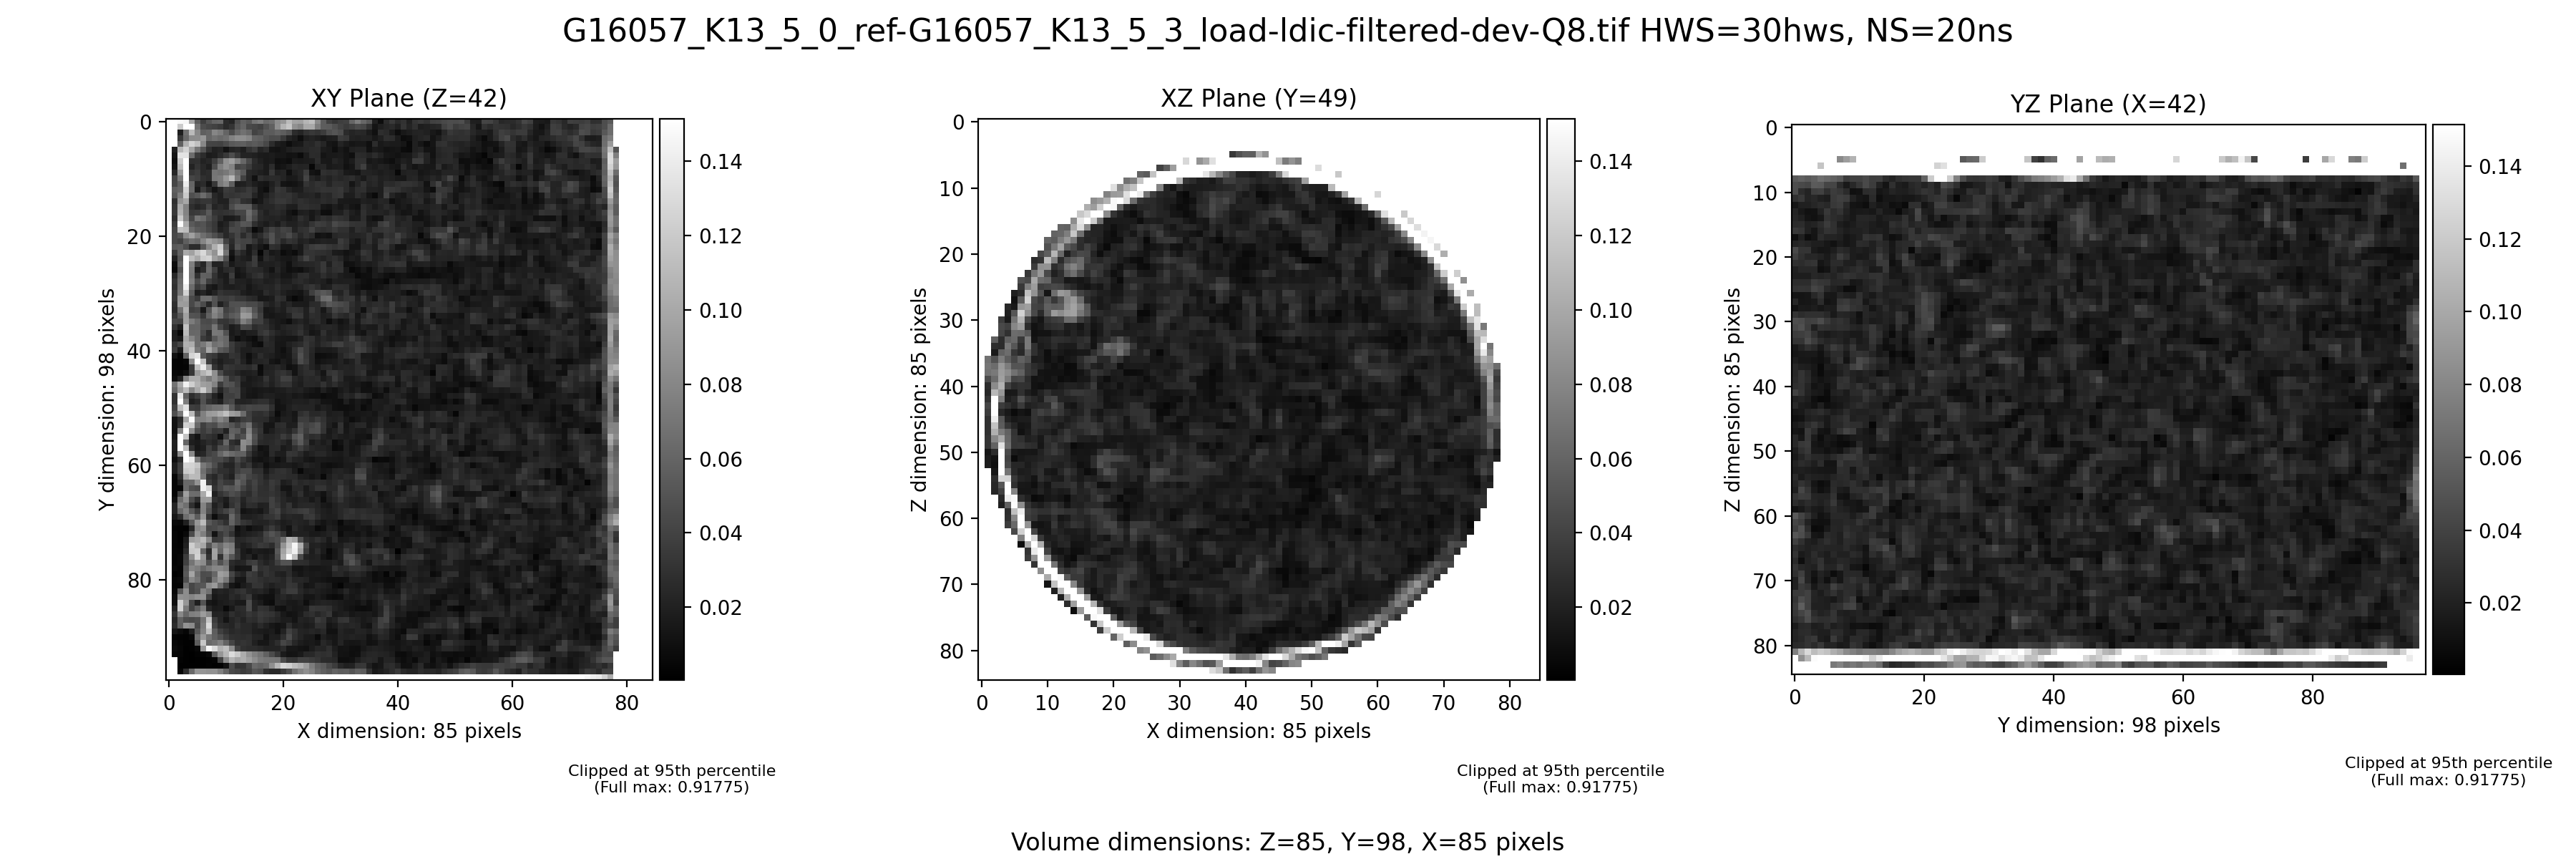

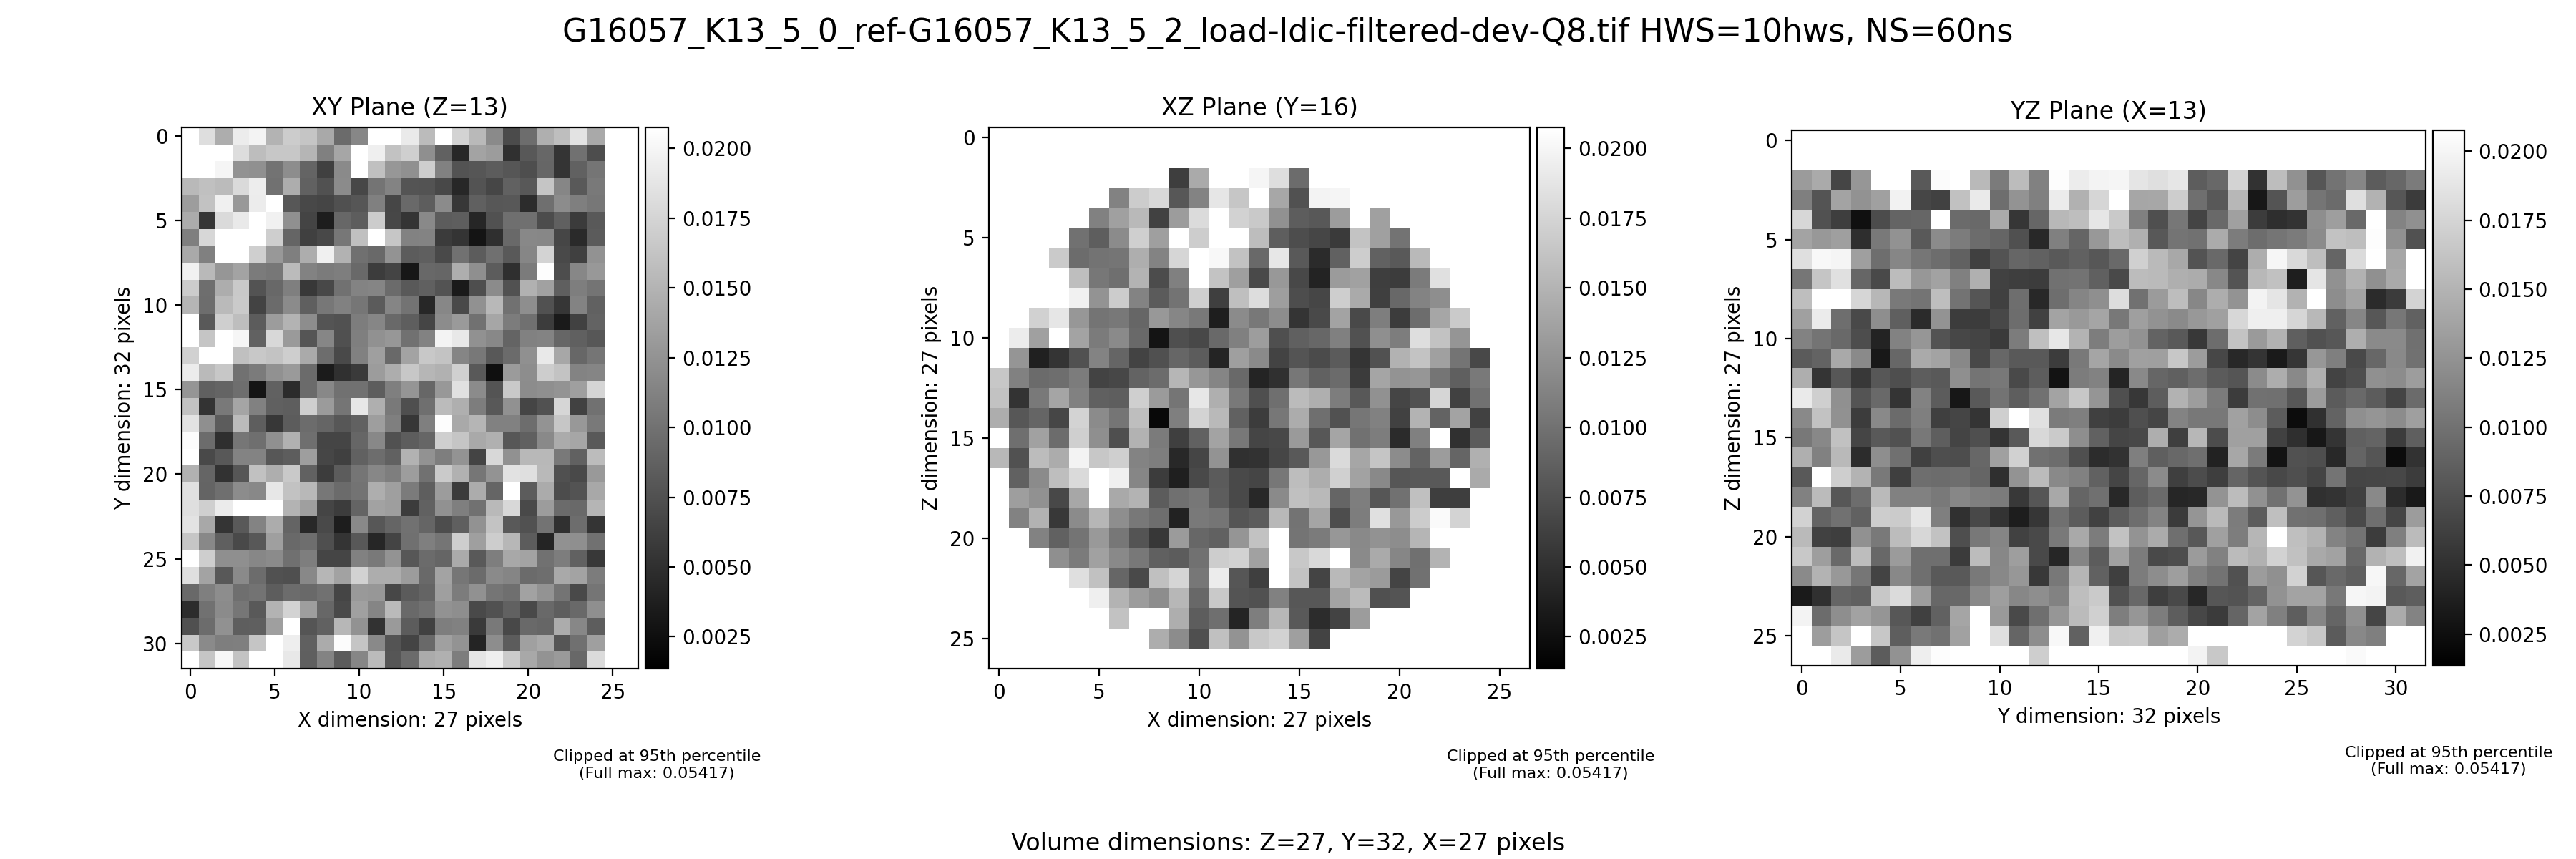

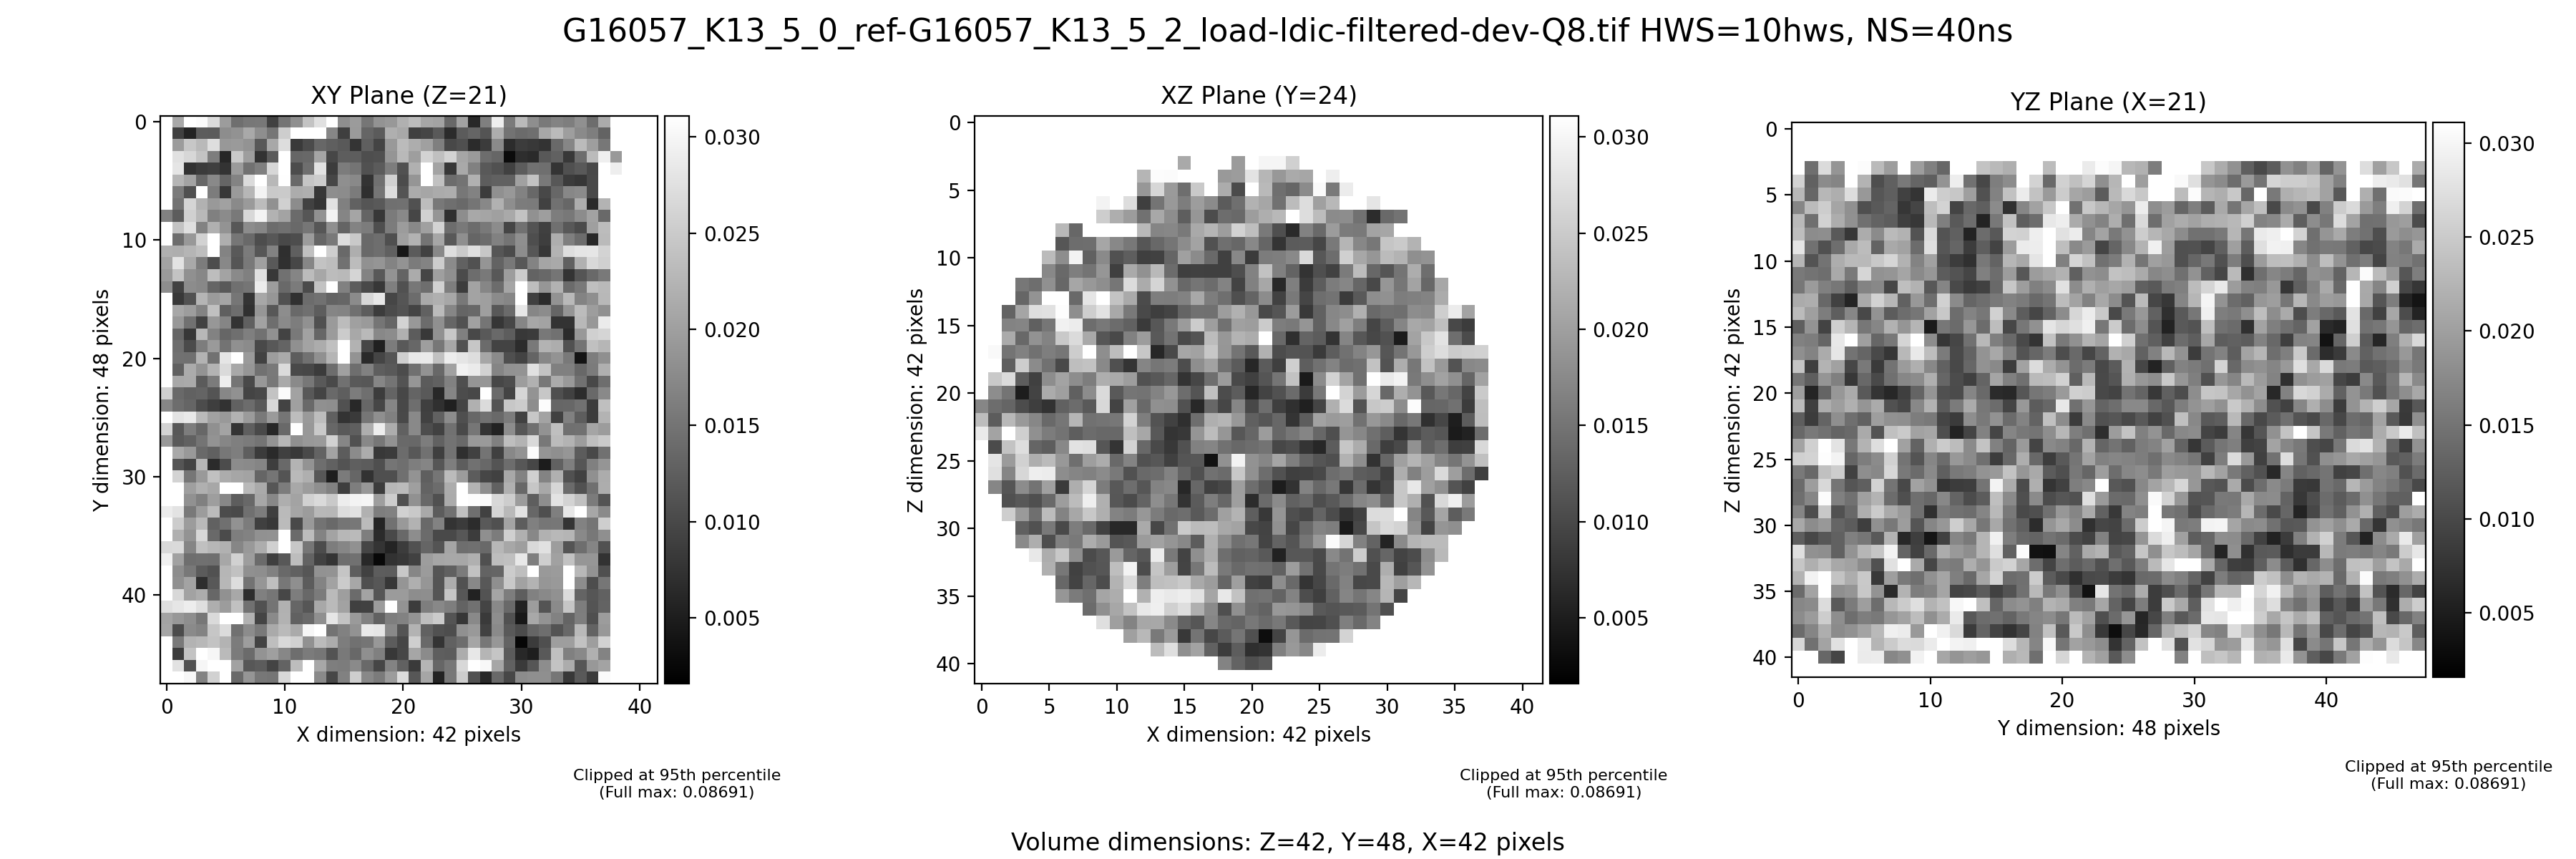

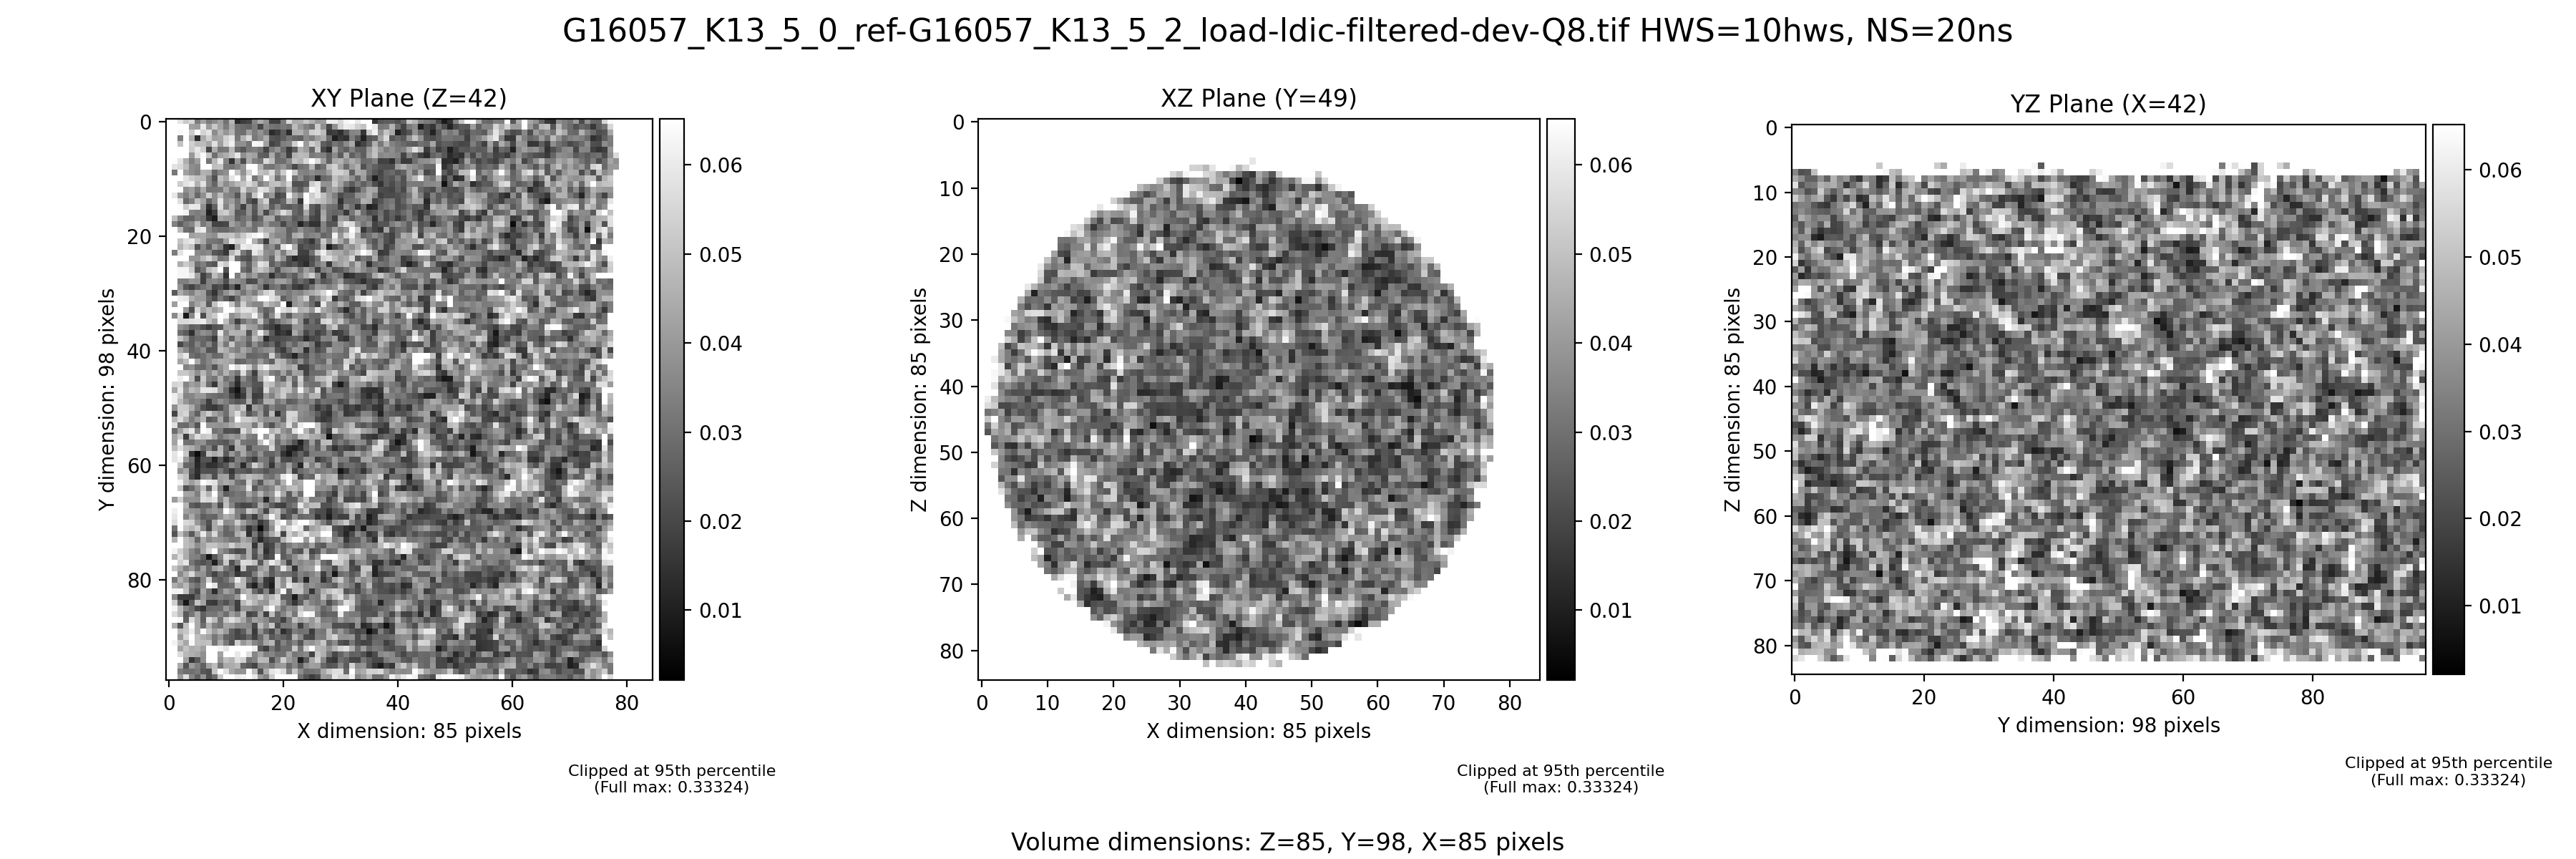

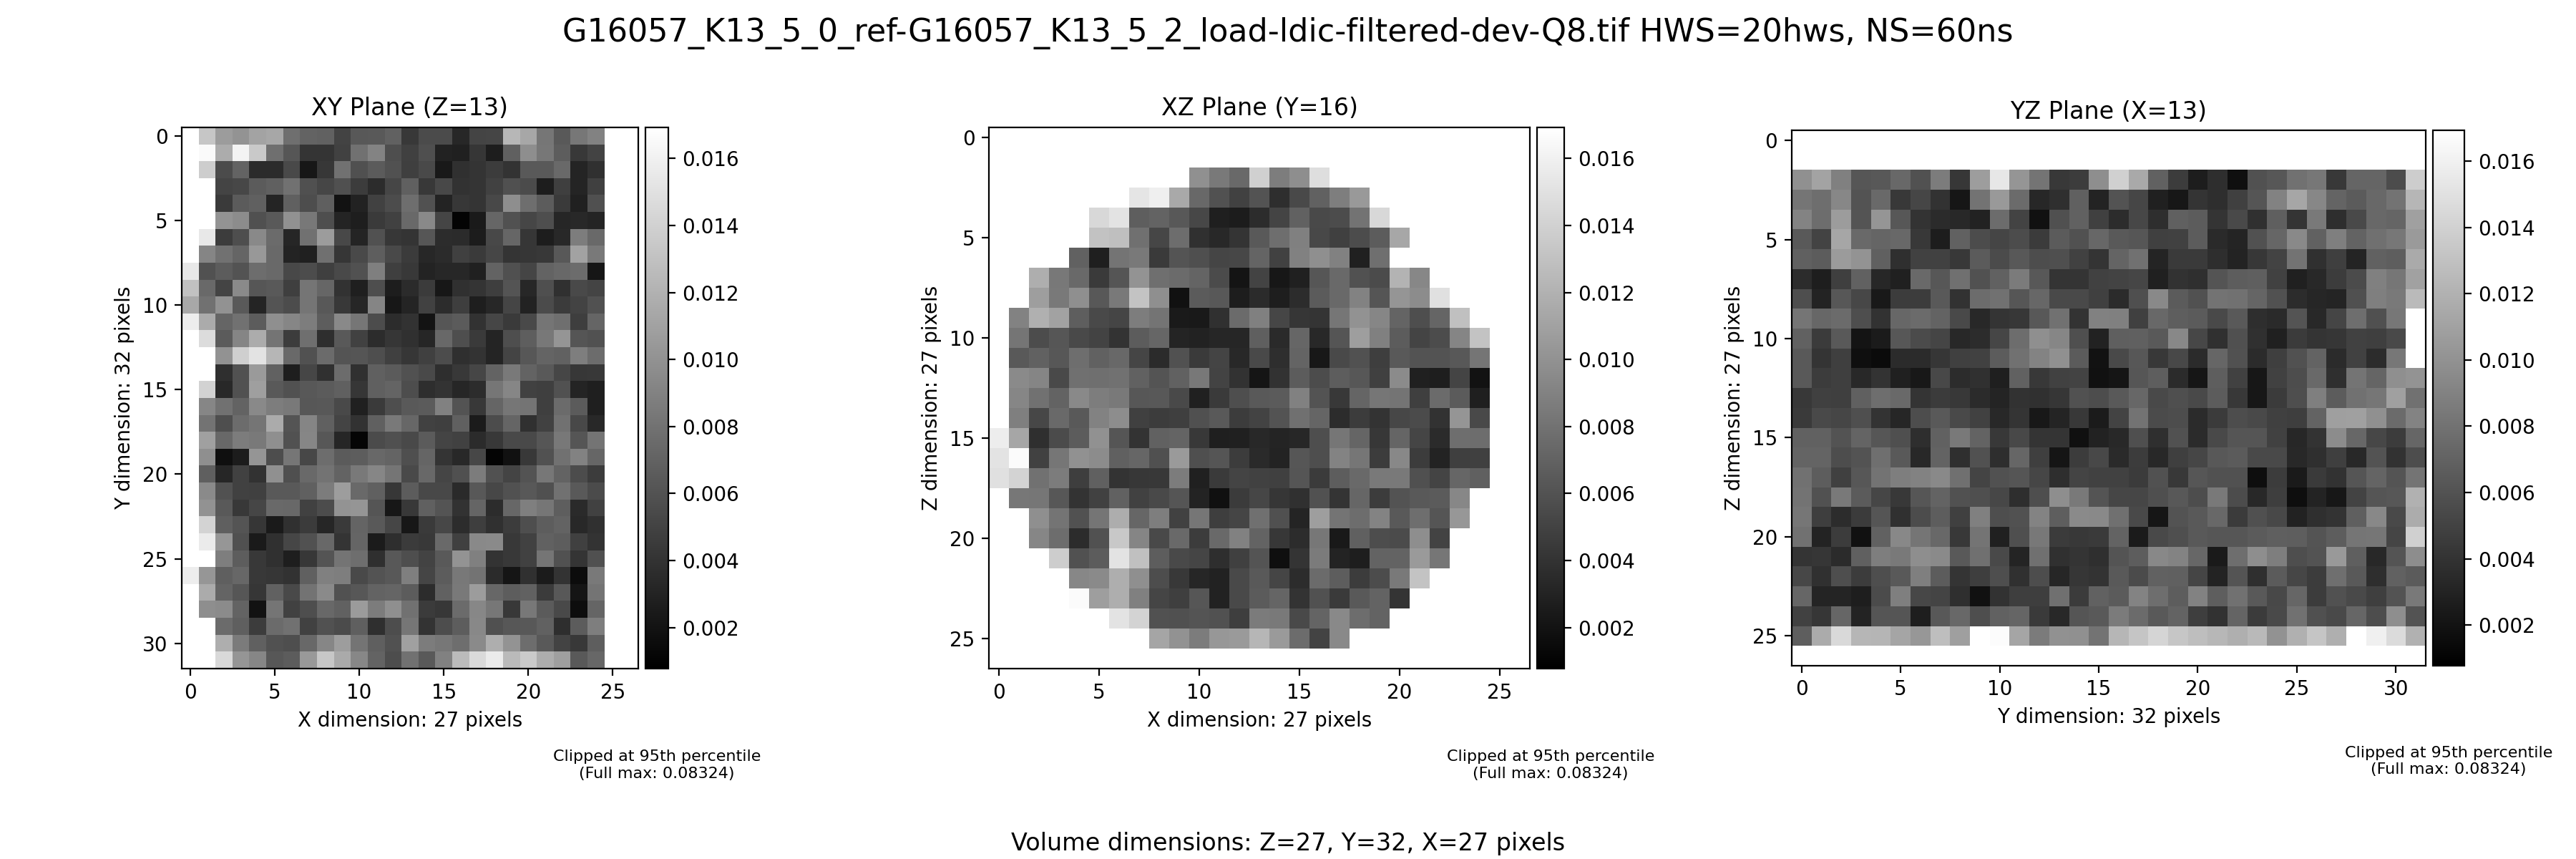

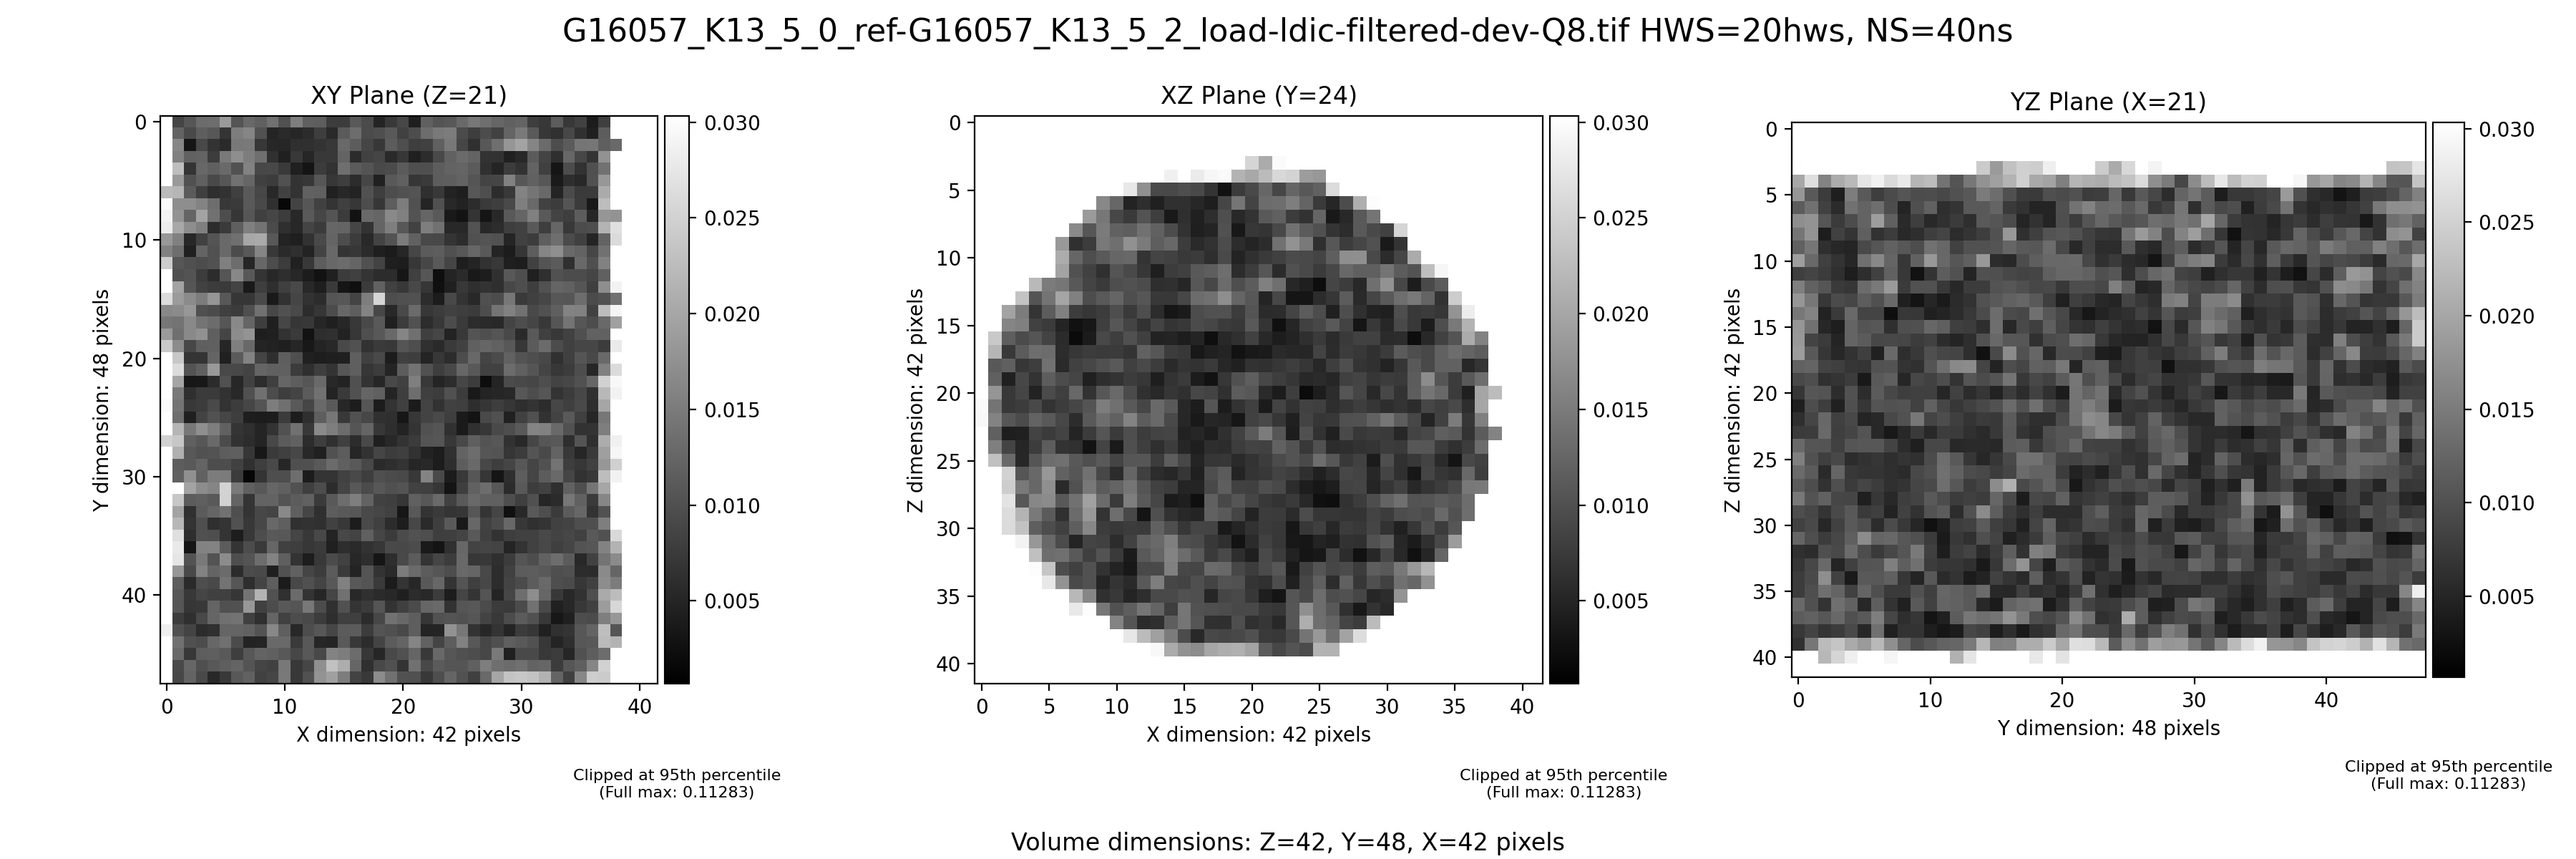

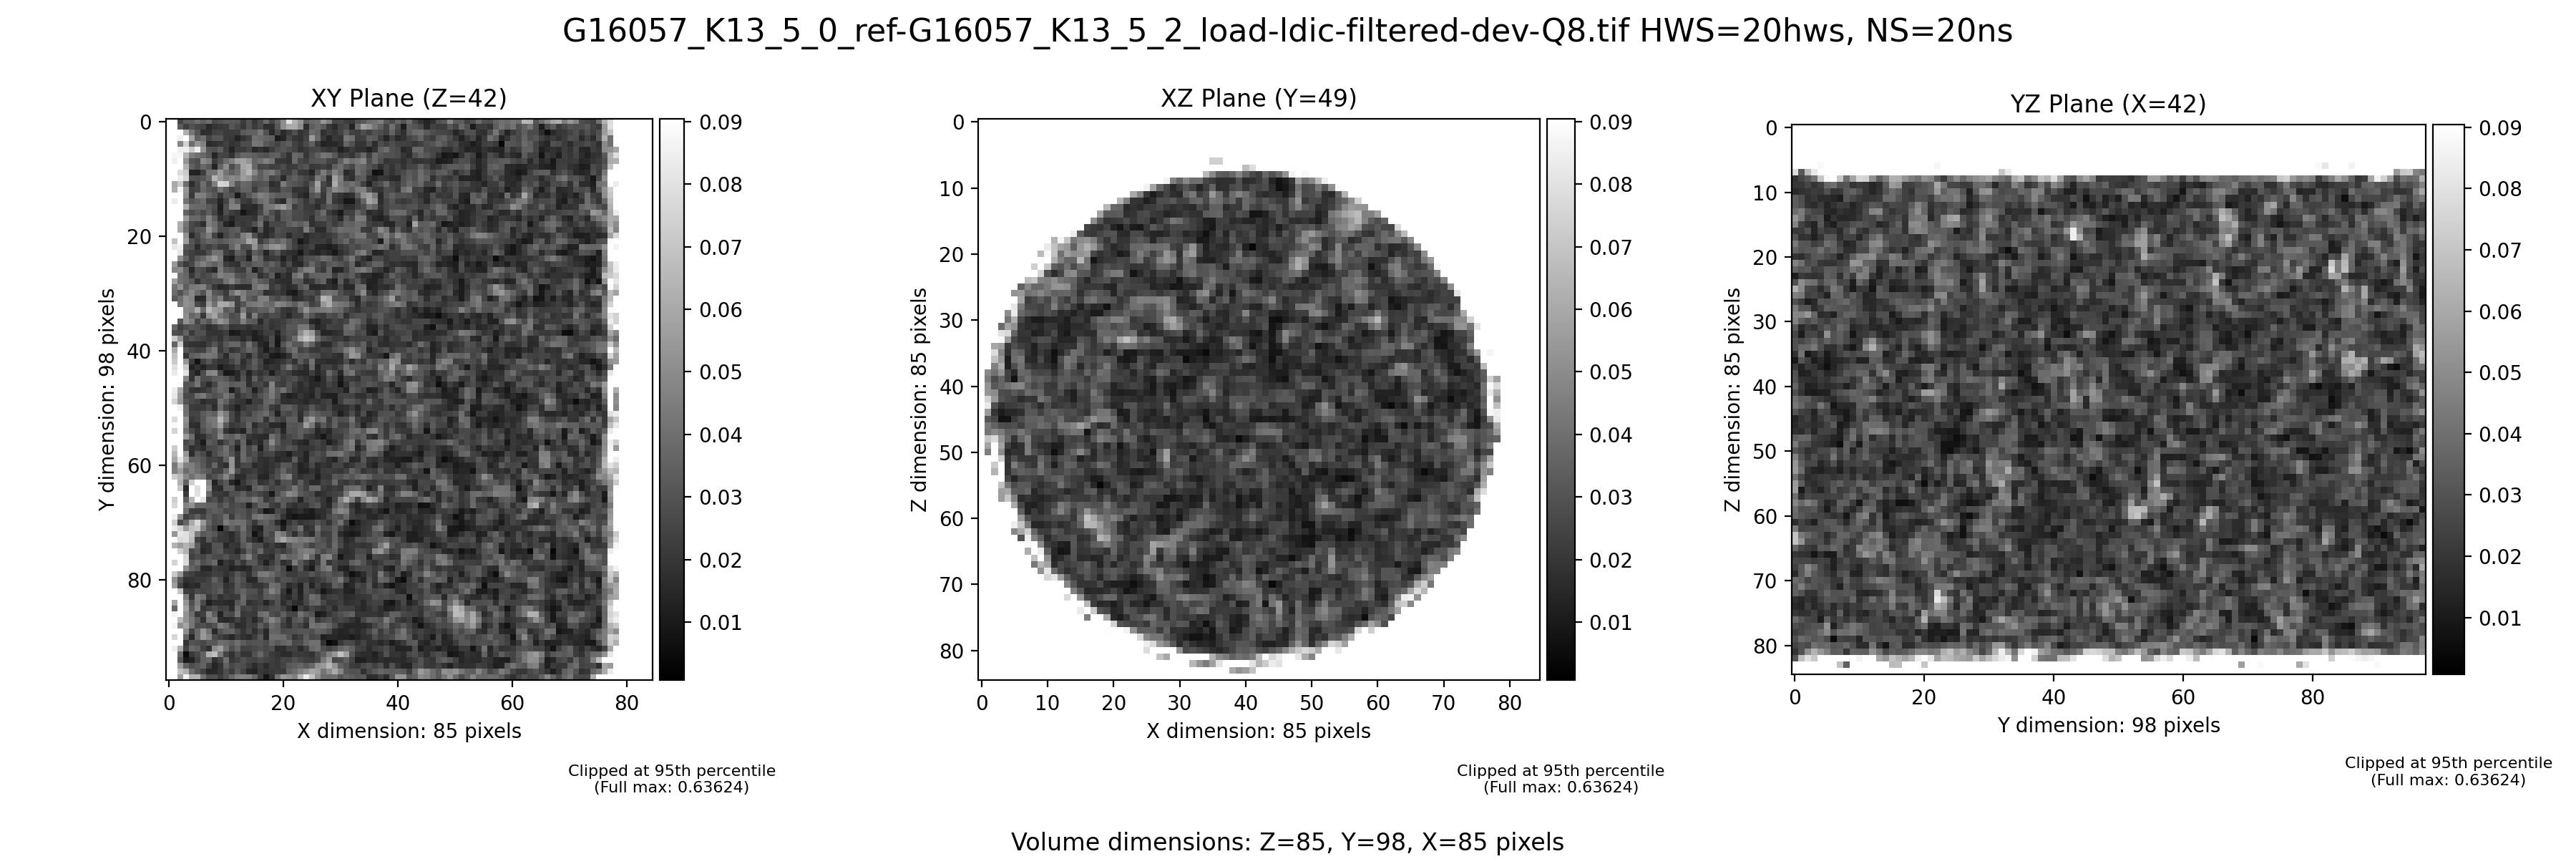

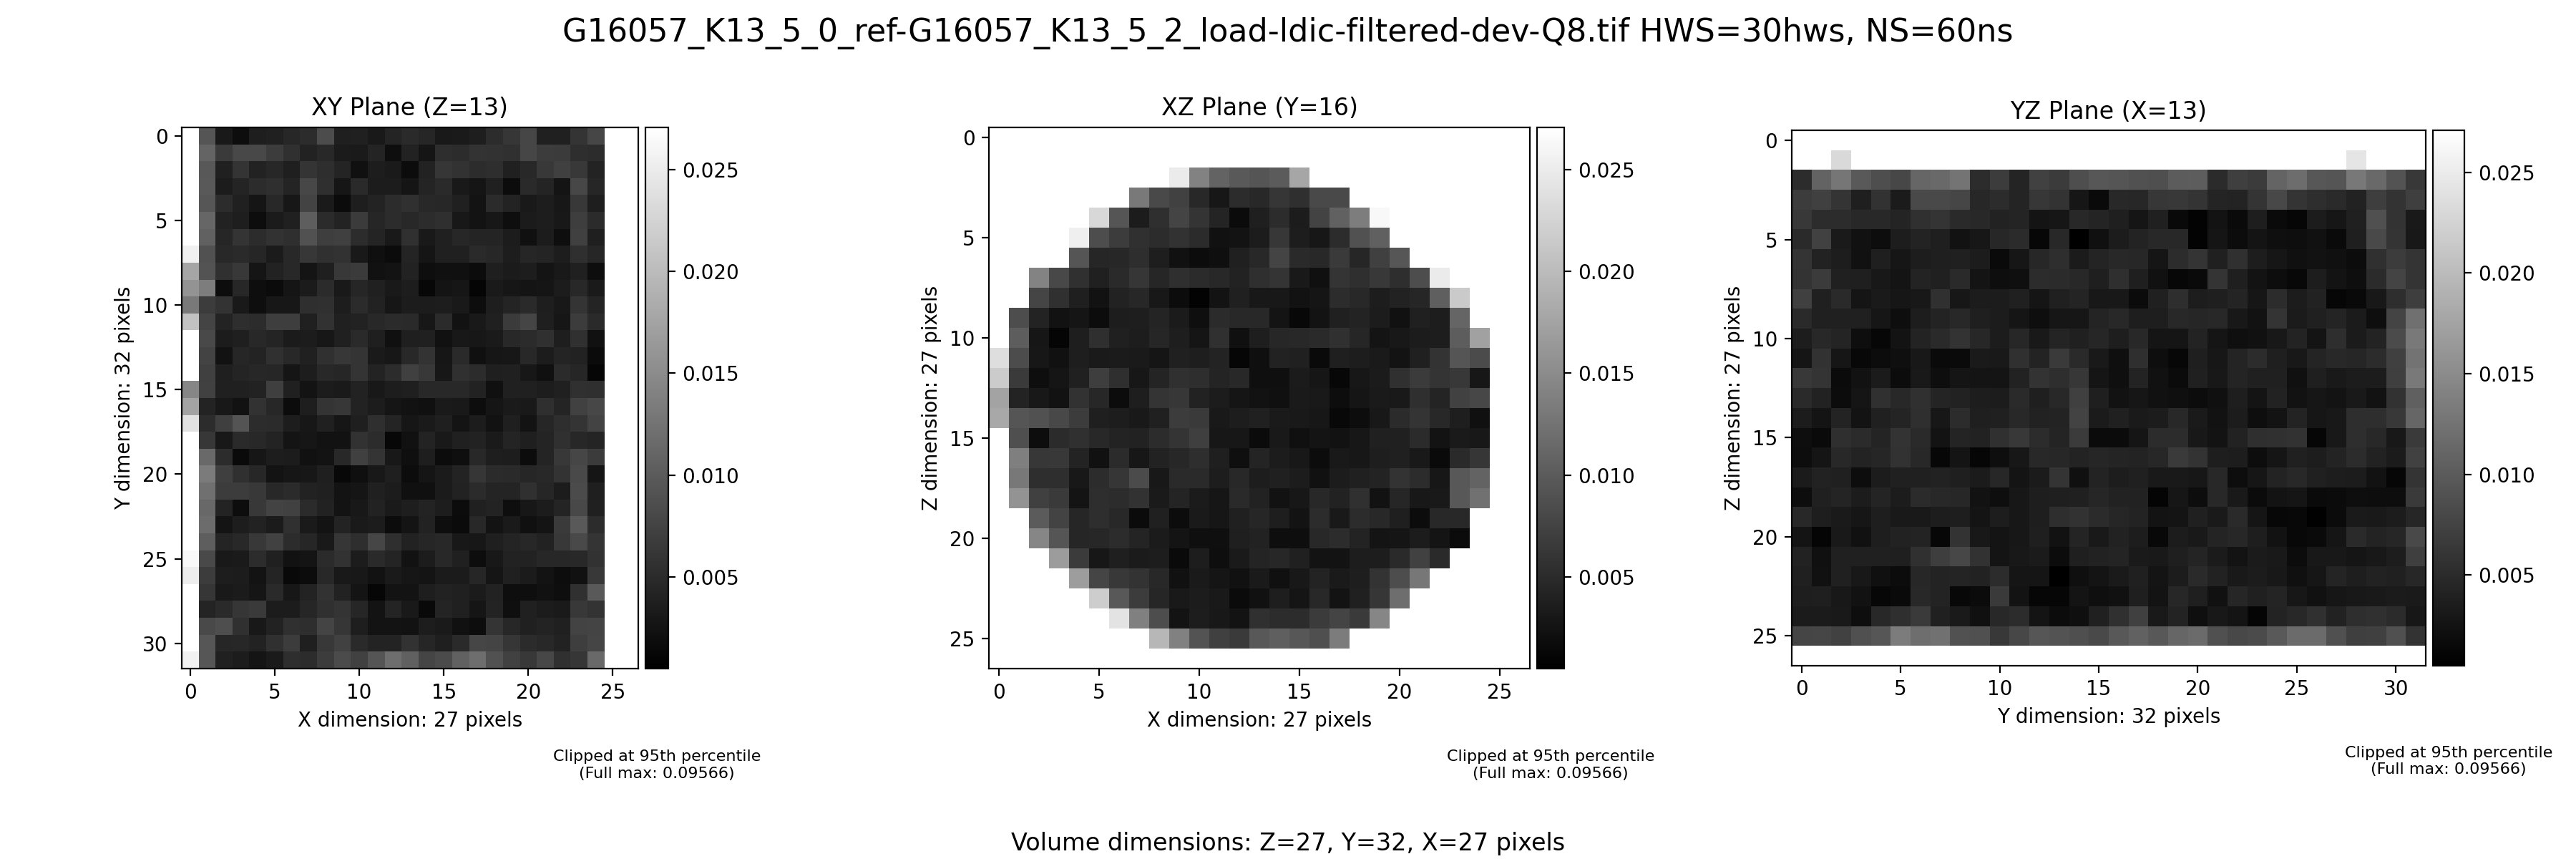

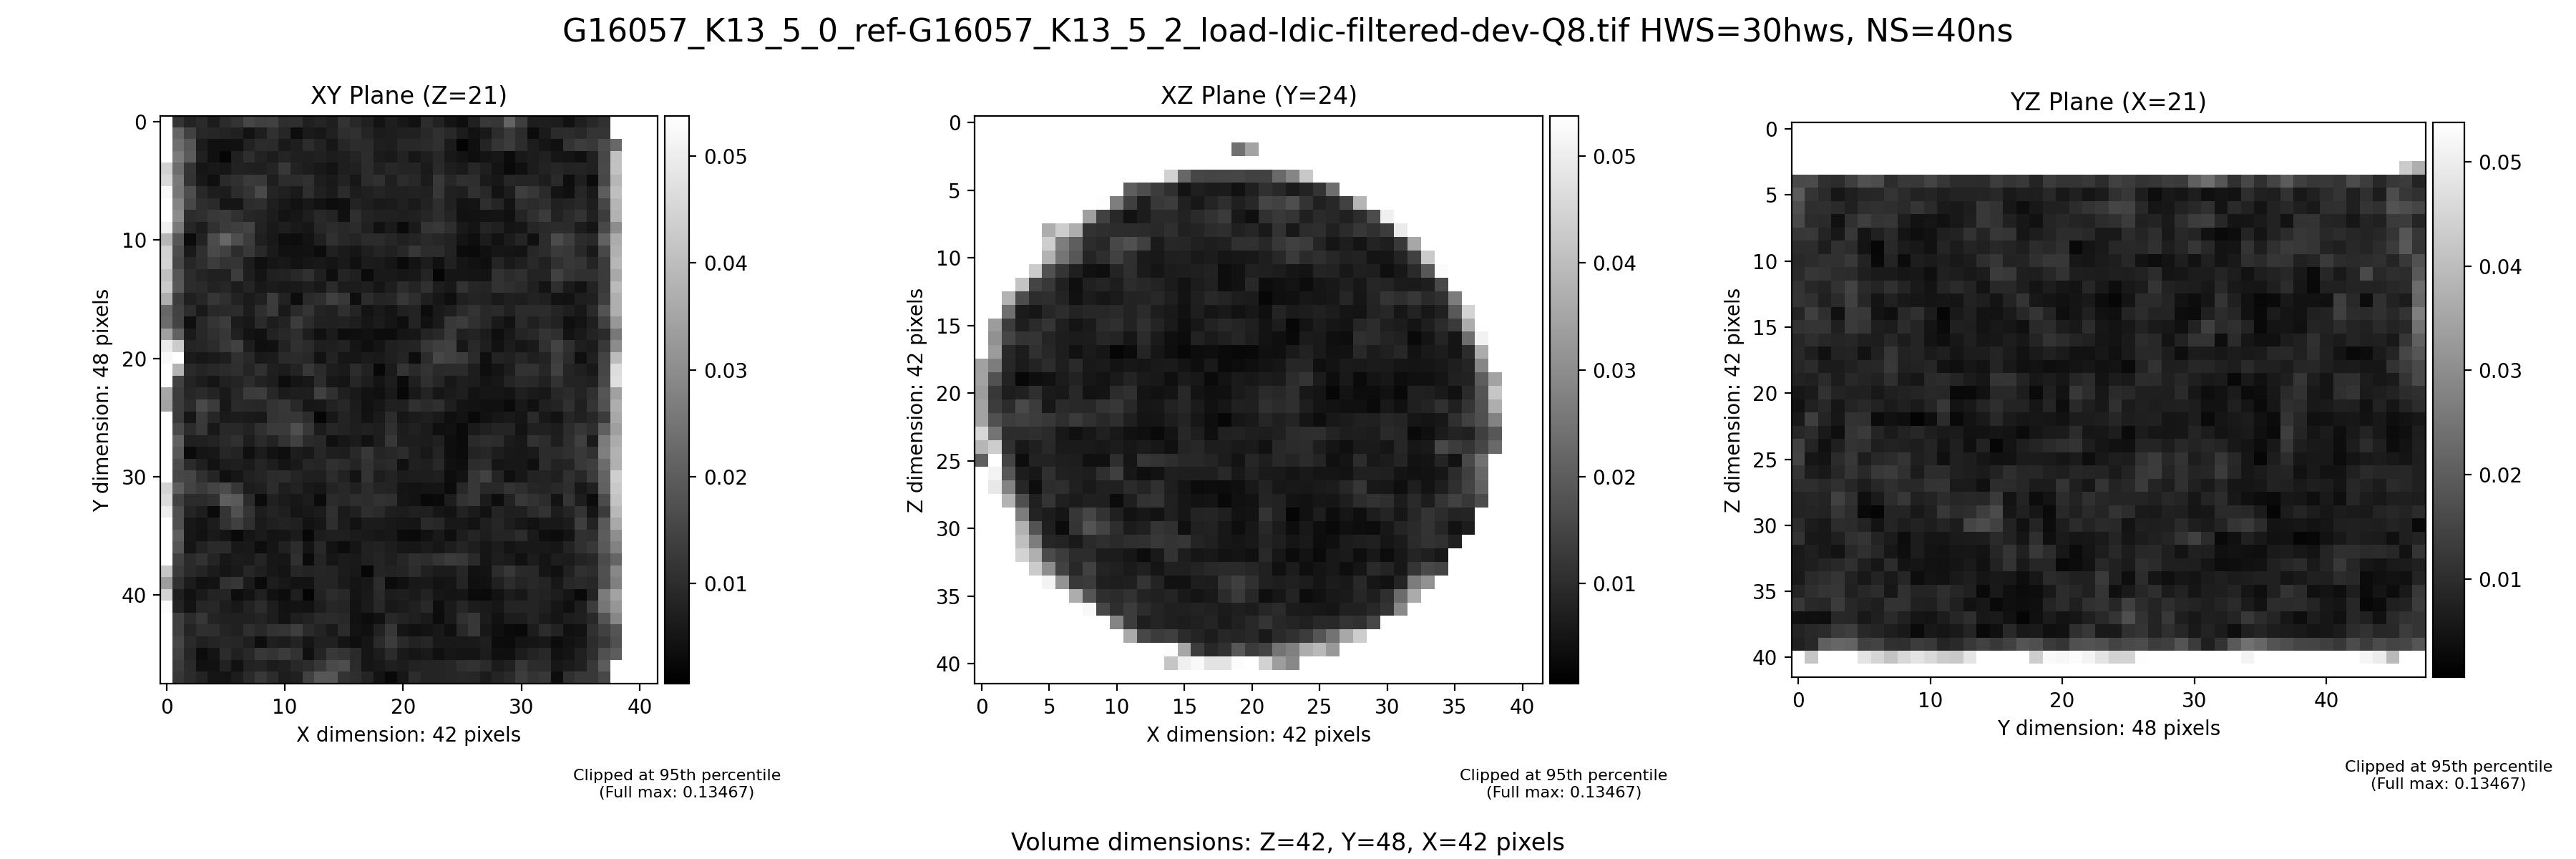

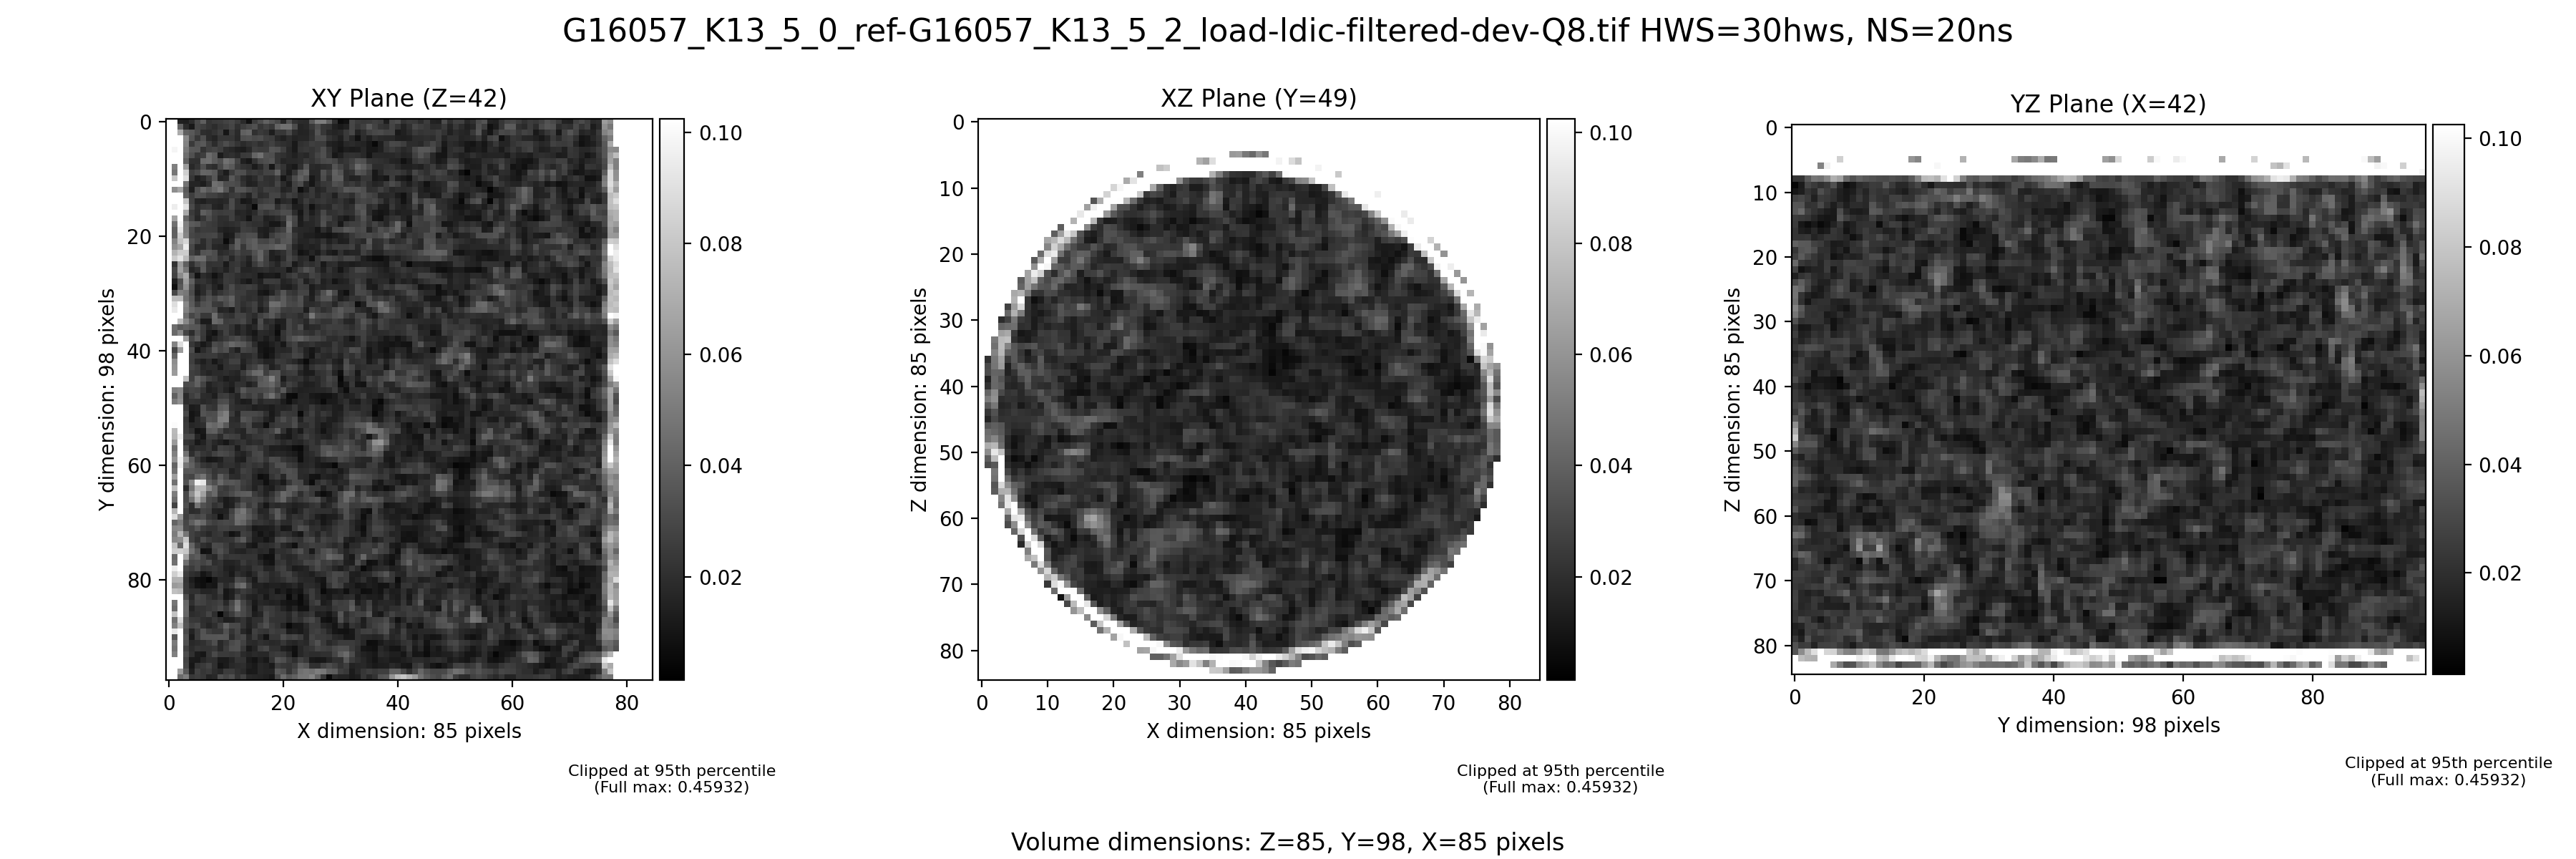

In [17]:
from IPython.display import Image, display

path = dvc_output_path
paths = os.listdir(path)
for p in paths:
    folder = os.path.join(path, p, "strain_filtered")
    files = os.listdir(folder)
    images = [a for a in files if ".png" in a]
    img_to_show = os.path.join(folder, images[0])
    display(Image(filename=img_to_show))

In [2]:
# Define helper functions

def get_file_desc_from_path(file_name):
    pattern = r'\d+_(ref|load)'
    match = re.search(pattern, file_name)

    if match:
        extracted_text = match.group(0)
        return extracted_text
    else:
        raise Exception(f"No usable regex match found for naming 3D tiff file from path: {file_name}")

def get_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders

def log_function_call(func):
    def wrapper(*args, **kwargs):
        start_time = datetime.now()
        logging.info(f"Function {func.__name__} started with args: {args}, kwargs: {kwargs}")
        
        result = func(*args, **kwargs)
        
        end_time = datetime.now()
        run_time = end_time - start_time
        run_time_str = str(run_time).split('.')[0]  # Format runtime as hours:minutes:seconds
        logging.info(f"Function {func.__name__} ended with result: {result}")
        logging.info(f"Function {func.__name__} runtime: {run_time_str}")
        
        return result
    return wrapper

In [3]:
# Define data processing functions

@log_function_call
def create_3d_tiff_from_path(path, save_folder_path):
    """
    Create 3D TIFF from image sequence at path and save it to disk. Handles automatic file naming.
    Args:
        path (path): Path to images to create 3D TIFF from.
    Returns:
        None
    """
    img_seq_to_tiff.create_3d_tiff(path, save_folder_path)

@log_function_call
def create_3d_tiffs_from_paths(paths, save_folder_path):
    """
    Create 3D TIFF for every path in paths and save them to disk. Handles automatic file naming.
    Args:
        paths (list): List of paths to create 3D TIFF from.
    Returns:
        None
    """
    for path in tqdm(paths, desc="Creating 3D TIFFs from paths"):
        directory = os.path.dirname(path)

        # Get the last part of the directory name
        second_last_part = os.path.basename(directory)
        file_name = second_last_part + "_" + get_file_desc_from_path(path) + '.tif'
        out_path = os.path.join(save_folder_path, file_name)
        print(path)
        print(out_path)
        print('----------------')
        create_3d_tiff_from_path(path, out_path)

@log_function_call
def align_images_from_path(ref_folder_path, def_folder_path, save_folder_path, row_range, col_range):
    """
    Align images by shifting. Saves aligned images to save_folder_path.
    Args:
        ref_folder_path (path): Path to reference images.
        def_folder_path (path): Path to deformed images.
        save_folder_path (path): Path to save aligned images.
        row_range (tuple): Range of rows to focus on.
        col_range (tuple): Range of columns to focus on.
    Returns:
        None
    """
    align_images.align(ref_folder_path, def_folder_path, save_folder_path, row_range, col_range)

In [4]:
# List the contents of the directory /mnt/d
contents = os.listdir(external_drive_path)
print(contents)

['DIC']


In [5]:
# Go through each raw data folder, get a list of folders inside and asign it to data_paths
folders_1 = [f for f in os.listdir(raw_data_path) if os.path.isdir(os.path.join(raw_data_path, f))]

data_paths = []
for folder in folders_1:
    path_2 = os.path.join(raw_data_path, folder)
    folders_2 = [f for f in os.listdir(path_2) if os.path.isdir(os.path.join(path_2, f))]
    
    # Save full path of folder into data_paths
    tmp = []
    for folder_2 in folders_2:
        tmp.append(os.path.join(path_2, folder_2))
    data_paths.append(tmp)

In [6]:
# Create 3D TIFFs from raw ref data
for path_grp in tqdm(data_paths, desc="Processing"):
    path = path_grp[0]
    # Get the directory name of the path
    directory = os.path.dirname(path)

    # Get the last part of the directory name
    basename = os.path.basename(directory)
    save_path_3d_file = os.path.join(tiff_3d_aligned_output_path, basename, basename + "_" + get_file_desc_from_path(path) + '.tif')
    if not os.path.exists(save_path_3d_file):
        create_3d_tiff_from_path(path, save_path_3d_file)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
# Align images from raw data
for path_grp in data_paths:

    for i, path in tqdm(enumerate(path_grp), desc="Processing", total=len(path_grp)):
        # Don't allign reference with itself
        if i != 0:
            continue
        # Get the directory name of the path
        directory = os.path.dirname(path)

        # Get the last part of the directory name
        basename = os.path.basename(directory)
        save_folder = os.path.join(tiff_3d_aligned_output_raw_path, basename, get_file_desc_from_path(path))
        if not os.path.exists(save_folder):
            align_images_from_path(path_grp[0], path, save_folder, (1400, 1600), (400, 800))
        
        save_path_3d_file = os.path.join(tiff_3d_aligned_output_path, basename, basename + "_" + get_file_desc_from_path(path) + '.tif')
        if not os.path.exists(save_path_3d_file):
            create_3d_tiff_from_path(save_folder, save_path_3d_file)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Processing:   0%|          | 0/5 [00:00<?, ?it/s]

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
@log_function_call
def dvc_procedures(hws, ns, it, glt, m_x, m_y, m_z, im1, im2, out):
    ldic = f'spam-ldic {im1} {im2} -hws {hws} -ns {ns} -it {it} -glt {glt} -vtk -tif -od {out} -m3 {m_z} {m_y} {m_x}'
    !{ldic}

    # find tsv file in out folder
    tsv_file = None
    for file in os.listdir(out):
        if file.endswith('.tsv'):
            tsv_file = os.path.join(out, file)
            break

    if tsv_file is None:
        raise FileNotFoundError("No .tsv file found in the output directory")

    out_filter = os.path.join(out, filtered_path)

    filter = f'spam-filterPhiField -pf {tsv_file} -fm -F "all" -tif -vtk -od {out_filter}'
    !{filter}

    # find tsv file in out folder
    tsv_file_filtered = None
    for file in os.listdir(out_filter):
        if file.endswith('.tsv'):
            tsv_file_filtered = os.path.join(out_filter, file)
            break

    if tsv_file_filtered is None:
        raise FileNotFoundError("No .tsv file found in the filtered output directory")

    out_strain = os.path.join(out, strain_filtered_path)
    strain = f'spam-regularStrain {tsv_file_filtered} -comp vol dev U -cub -tif -vtk -od {out_strain} -rst 1'
    !{strain}

In [9]:
import tifffile as tiff

data_paths_3d = get_folders(tiff_3d_aligned_output_path)
data_paths_3d_files = []
for folder in data_paths_3d:
    grp = []
    for file in os.listdir(os.path.join(tiff_3d_aligned_output_path, folder)):
        grp.append(os.path.join(tiff_3d_aligned_output_path, folder, file))
    data_paths_3d_files.append(grp)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime
import io

def make_graphs(path, save_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import tifffile as tiff
    import os
    from matplotlib.colors import Normalize
    
    # Load the 3D TIFF file
    image_path = path  # Your image path variable
    image = tiff.imread(image_path)
    
    # Create the figure with visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Add figure title
    hws_re = re.search(r'(\d+)hws', image_path)
    ns_re = re.search(r'(\d+)ns', image_path)
    fig.suptitle(f'{os.path.basename(image_path)} HWS={hws_re[0]}, NS={ns_re[0]}', fontsize=16)
    
    # Calculate middle slices
    z_mid = image.shape[0] // 2
    y_mid = image.shape[1] // 2
    x_mid = image.shape[2] // 2
    
    # Handle NaN values properly
    valid_data = image[~np.isnan(image)]
    
    if len(valid_data) == 0:
        print(f"Warning: {image_path} contains only NaN values!")
        return
    
    # Apply clipped normalization - clip at 95th percentile to better show small values
    # Calculate the 95th percentile value across the entire volume, ignoring NaNs
    vmax_clip = np.nanpercentile(image, 95)
    vmin = np.nanmin(image)
    
    # Create a normalization object for consistent color mapping across all slices
    norm = Normalize(vmin=vmin, vmax=vmax_clip)
    
    # Function to add colorbar to each subplot
    def add_colorbar(im, ax):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax)
        # Add note about clipping to the colorbar
        if im.norm.vmax < np.nanmax(image):
            cbar.ax.text(0.5, -0.15, f'Clipped at 95th percentile\n(Full max: {np.nanmax(image):.5f})', 
                         ha='center', va='top', fontsize=8, transform=cbar.ax.transAxes)
    
    # XY plane (Z slice)
    im0 = axes[0].imshow(image[z_mid, :, :], cmap='gray', norm=norm)
    axes[0].set_title(f'XY Plane (Z={z_mid})')
    axes[0].set_xlabel(f'X dimension: {image.shape[2]} pixels')
    axes[0].set_ylabel(f'Y dimension: {image.shape[1]} pixels')
    add_colorbar(im0, axes[0])
    
    # XZ plane (Y slice)
    im1 = axes[1].imshow(image[:, y_mid, :], cmap='gray', norm=norm)
    axes[1].set_title(f'XZ Plane (Y={y_mid})')
    axes[1].set_xlabel(f'X dimension: {image.shape[2]} pixels')
    axes[1].set_ylabel(f'Z dimension: {image.shape[0]} pixels')
    add_colorbar(im1, axes[1])
    
    # YZ plane (X slice)
    im2 = axes[2].imshow(image[:, :, x_mid], cmap='gray', norm=norm)
    axes[2].set_title(f'YZ Plane (X={x_mid})')
    axes[2].set_xlabel(f'Y dimension: {image.shape[1]} pixels')
    axes[2].set_ylabel(f'Z dimension: {image.shape[0]} pixels')
    add_colorbar(im2, axes[2])
    
    # Calculate NaN percentage
    nan_percentage = (np.isnan(image).sum() / image.size) * 100
    
    # Add overall dimension text
    fig.text(0.5, 0.01, f'Volume dimensions: Z={image.shape[0]}, Y={image.shape[1]}, X={image.shape[2]} pixels',
            ha='center', fontsize=12)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    
    # Save figure to a file
    output_image_path = os.path.join(save_path, f"{image_path.split(os.path.sep)[-3]}.png")
    plt.savefig(output_image_path, format='png', dpi=200)
    
    # Optional: Create a second figure showing the full range for comparison
    create_comparison = True
    if create_comparison:
        fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
        fig2.suptitle(f'{os.path.basename(image_path)} - Full Range vs Clipped Comparison', fontsize=16)
        
        # Full range visualization (left)
        full_norm = Normalize(vmin=vmin, vmax=np.nanmax(image))
        im_full = axes2[0].imshow(image[z_mid, :, :], cmap='gray', norm=full_norm)
        axes2[0].set_title(f'Full Range\n(min: {vmin:.5f}, max: {np.nanmax(image):.5f})')
        add_colorbar(im_full, axes2[0])
        
        # Clipped visualization (middle)
        im_clip = axes2[1].imshow(image[z_mid, :, :], cmap='gray', norm=norm)
        axes2[1].set_title(f'Clipped at 95th percentile\n(min: {vmin:.5f}, max: {vmax_clip:.5f})')
        add_colorbar(im_clip, axes2[1])
        
        # Histogram of values (right) - excluding NaNs
        valid_data_flat = valid_data.flatten()
        axes2[2].hist(valid_data_flat, bins=100)
        axes2[2].axvline(x=vmax_clip, color='r', linestyle='--', label='95th percentile')
        axes2[2].set_title(f'Histogram of Values (NaNs excluded)')
        axes2[2].set_xlabel('Pixel Value')
        axes2[2].set_ylabel('Frequency')
        
        # Add log scale option for better visibility of distribution
        if np.nanmax(image) / vmin > 100:  # If range is large, add log scale
            axes2[2].set_xscale('log')
            axes2[2].set_title(f'Histogram of Values (log scale, NaNs excluded)')
        
        axes2[2].legend()
        
        plt.tight_layout()
        comparison_path = os.path.join(save_path, f"{image_path.split(os.path.sep)[-3]}_comparison.png")
        plt.savefig(comparison_path, format='png', dpi=200)

In [11]:
from openpyxl import Workbook
from openpyxl.drawing.image import Image
import os
import tifffile as tiff
import next_excel_column

def excel_with_images(dvc_output_path, sample="G16060_P7_5_3_load", hws=None, ns=None):
    # Create a new Excel workbook
    wb = Workbook()
    ws = wb.active
    ws.title = "Multiple Images"
    last_col = 'A'
    last_row = 1

    anchors_hws = {}
    anchors_ns = {}
    hws_list = [20, 40, 60]
    ns_list = [80, 60, 40]
    for i in hws_list:
        anchors_hws[i] = last_col
        last_col = next_excel_column.next_excel_column(last_col, 54)
    for i in ns_list:
        anchors_ns[i] = last_row
        last_row += 62

    
    # Add a header
    ws['A1'] = "Spreadsheet with Multiple Images Side by Side"
    
    dvc_out_files = os.listdir(dvc_output_path)
    
    for file in dvc_out_files:
        
        if(sample != "" and sample not in file):
            continue
        
        if(hws != None and f"{hws}hws" not in file):
            continue
        
        if(ns != None and f"{ns}ns" not in file):
            continue
        
        if(not os.path.exists(os.path.join(dvc_output_path, file, 'strain_filtered'))):
            continue
        
        filtered_files = os.listdir(os.path.join(dvc_output_path, file, 'strain_filtered'))
        
        for f in filtered_files:
      
            if "dev" in f:
                # Load the 3D TIFF file path
                tiff_path = os.path.join(dvc_output_path, file, 'strain_filtered', f)
                
                # Generate the PNG visualization using make_graphs
                save_path = os.path.join(dvc_output_path, file, 'strain_filtered')
                make_graphs(tiff_path, save_path)
                
                # The PNG file should now exist at this path (based on your make_graphs function)
                png_filename = f"{file.split(os.path.sep)[-1]}.png"
                png_path = os.path.join(save_path, png_filename)
                
                # Check if the PNG file exists
                if os.path.exists(png_path):
                    try:
                        # Use the PNG file for Excel, not the TIFF
                        img = Image(png_path)
                        
                        try:
                            # regex to find what number is next to hws
                            m = re.search(r'(\d+)hws', tiff_path)
                            col = anchors_hws[int(m.group(1))]

                            m = re.search(r'(\d+)ns', tiff_path)
                            row = anchors_ns[int(m.group(1))]
                            
                            img.anchor = f"{col}{row}"
                            ws.add_image(img)
                            print(f"Added image to Excel: {png_path}")
                        except StopIteration:
                            print("Warning: Ran out of anchor cells. Not all images could be added.")
                            break
                    except Exception as e:
                        print(f"Error adding image {png_path} to Excel: {e}")
                else:
                    print(f"Warning: Expected PNG file not found at {png_path}")
                
                # Only process the first matching file
                
    
    # Save the workbook
    output_excel = f'strain_visualization_{sample}.xlsx'
    wb.save(output_excel)
    print(f"Excel file saved as: {output_excel}")
    #close the workbook
    wb.close()

# Example usage
# if __name__ == "__main__":

    # excel_with_images(dvc_output_path)

spam.helpers.optionsParser.isTwoDtiff(): Unknown condition
[spam-ldic] Current Settings:
	inFiles: ['../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED/3D_TIFF_ALIGNED/G16060_K12_5/G16060_K12_5_0_ref.tif', '../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED/3D_TIFF_ALIGNED/G16060_K12_5/G16060_K12_5_2_load.tif']
	PROCESSES: 88
	MASK1: None
	PHIFILE: None
	PHIFILE_BIN_RATIO: 1.0
	APPLY_F: all
	RIGID: False
	GREY_LOW_THRESH: 62.598
	GREY_HIGH_THRESH: inf
	NS: [40, 40, 40]
	HWS: [20, 20, 20]
	MARGIN: [3, 3, 3]
	MAX_ITERATIONS: 50
	MIN_DELTA_PHI: 0.001
	INTERPOLATION_ORDER: 1
	MASK_COVERAGE: 0.5
	UPDATE_GRADIENT: False
	SERIES_INCREMENTAL: False
	SKIP_NODES: False
	OUT_DIR: ../../../../bigdisk/mrogala/DIC/DATA_DIC_PROCESSED/DVC_OUTPUT_B/20hws_40ns_50it_63glt_3z-3y-3xm_G16060_K12_5_0_ref-G16060_K12_5_2_load
	PREFIX: None
	VTK: True
	TSV: True
	TIFF: True

Correlating: G16060_K12_5_0_ref-G16060_K12_5_2_load

	Starting local dic for 82369 nodes (with 88 processes)
  it=050  dPhiNorm=0.0061  rs

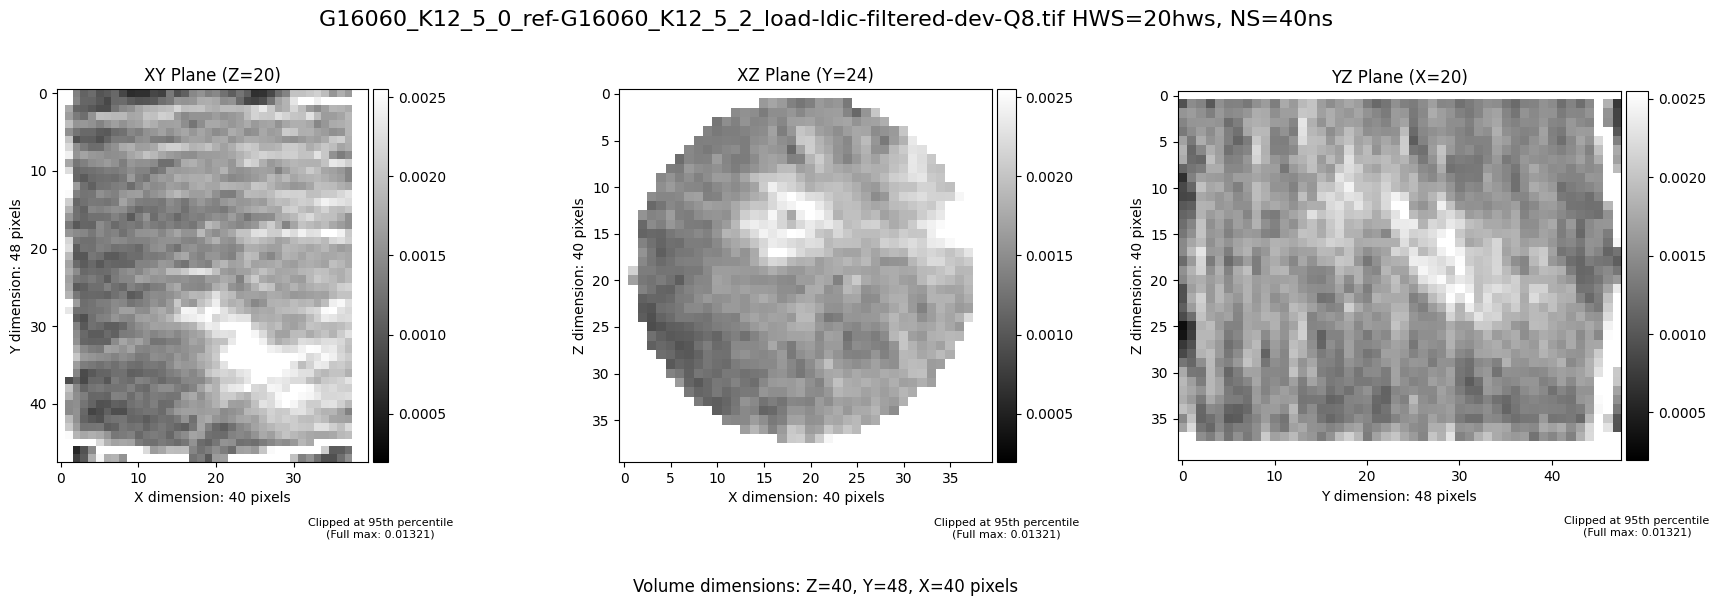

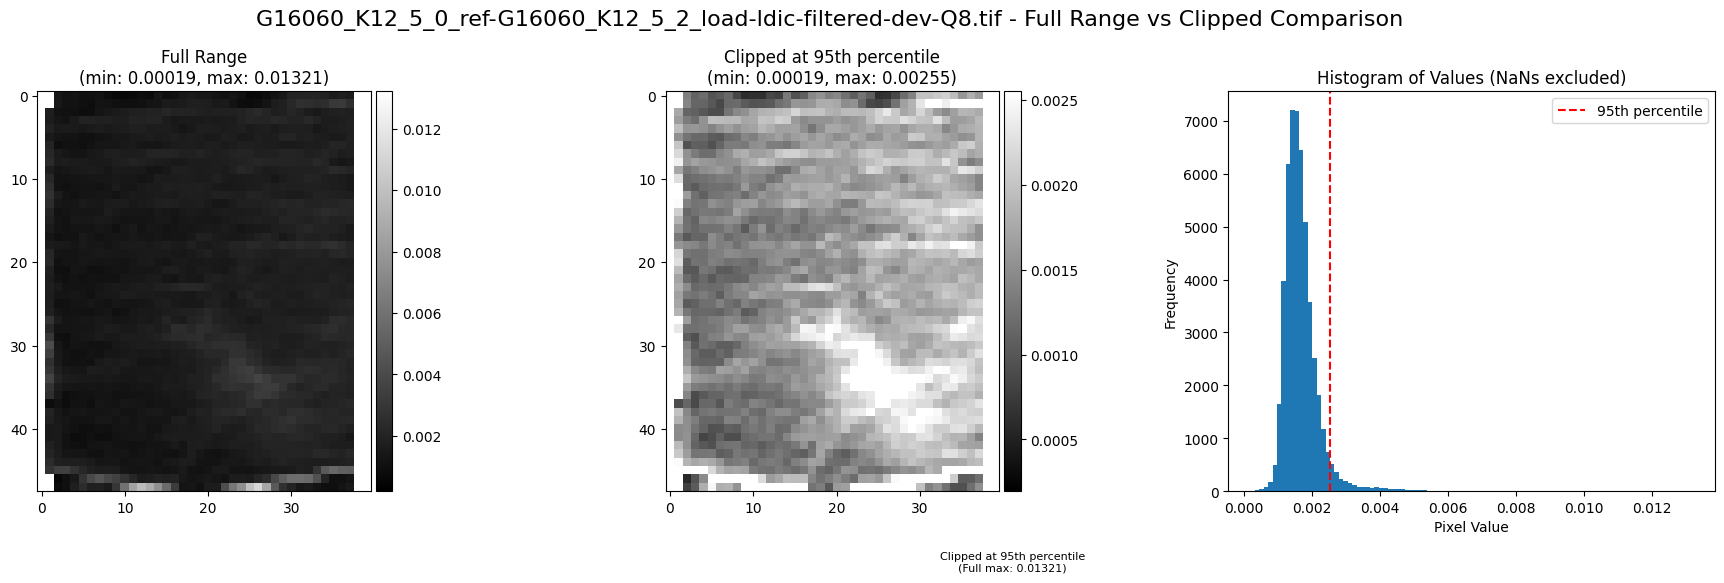

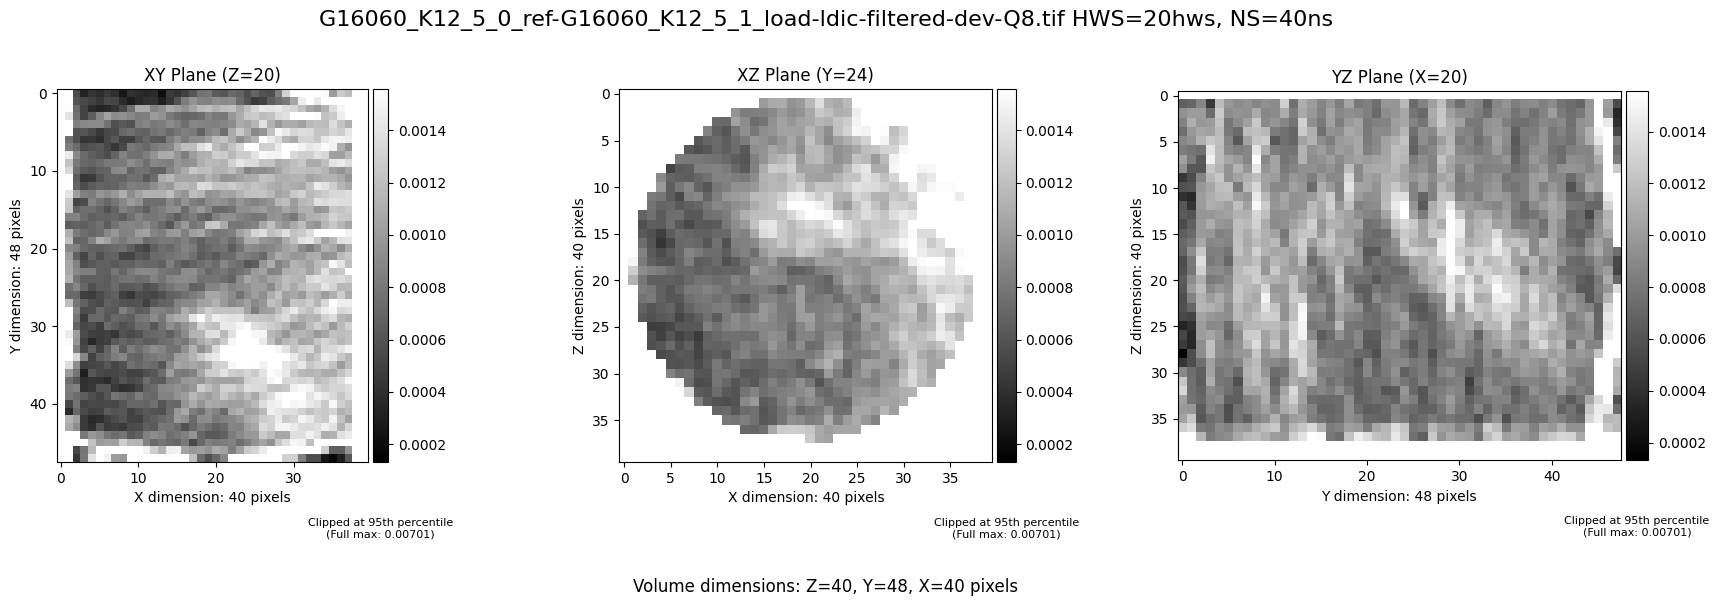

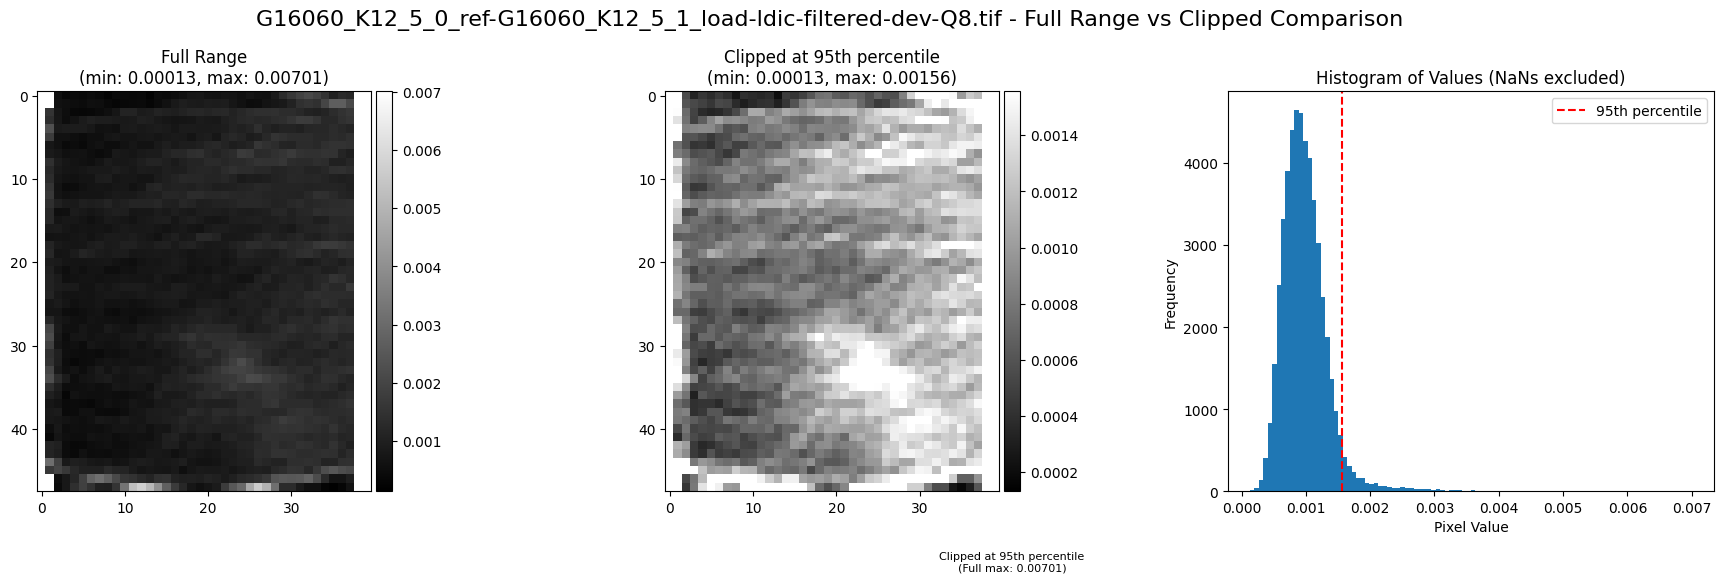

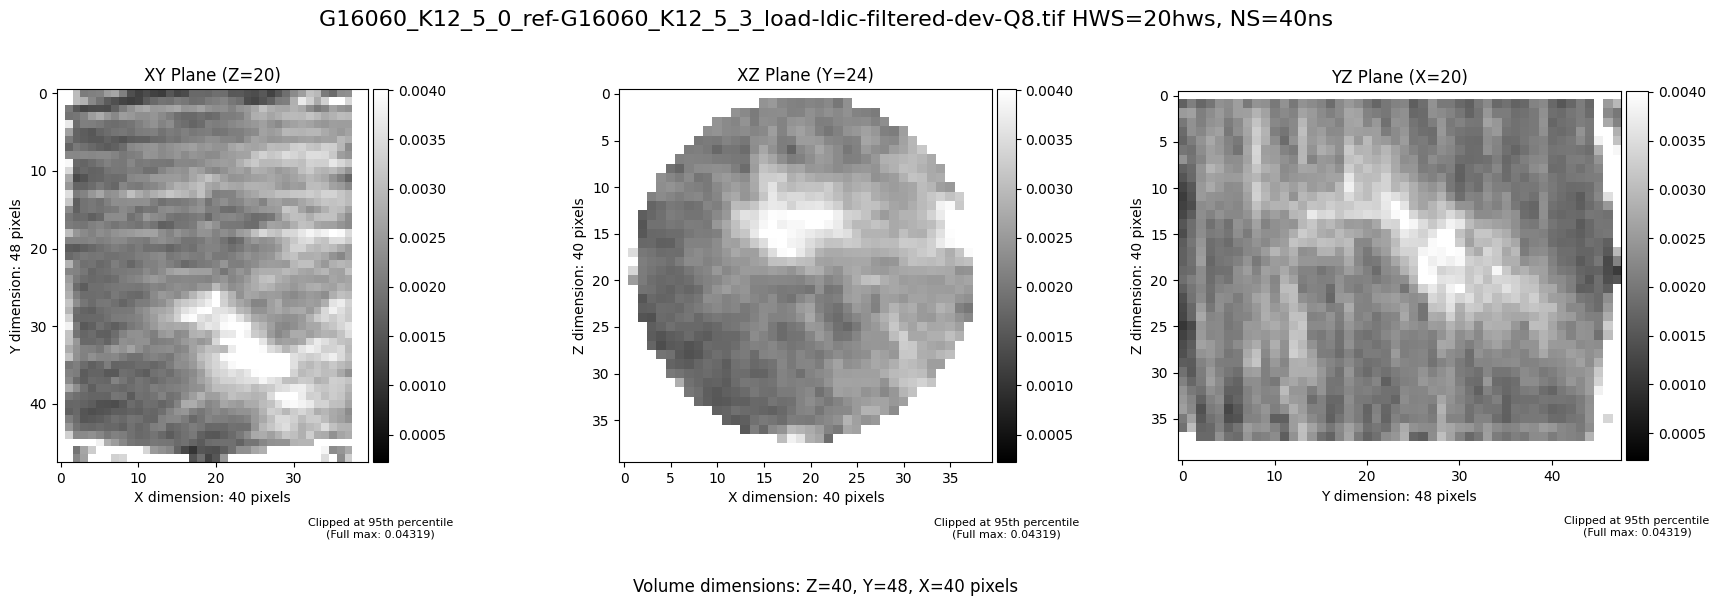

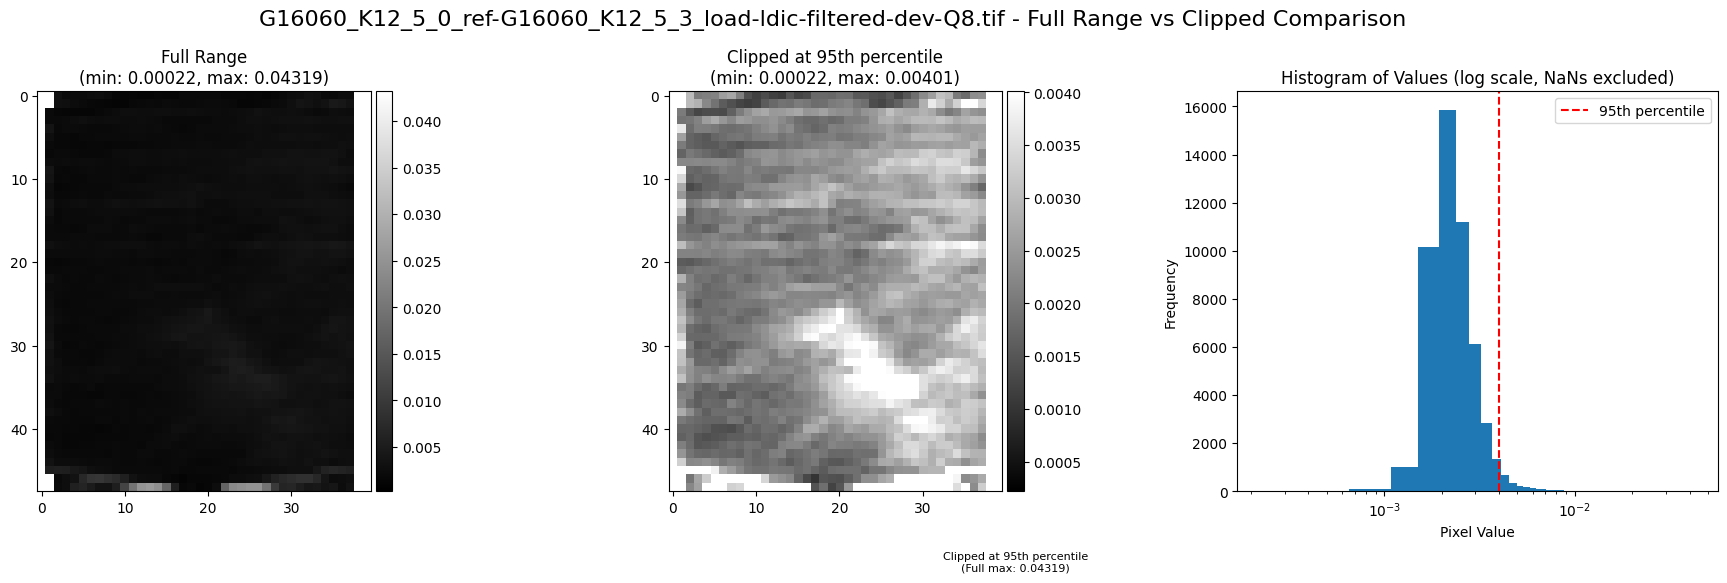

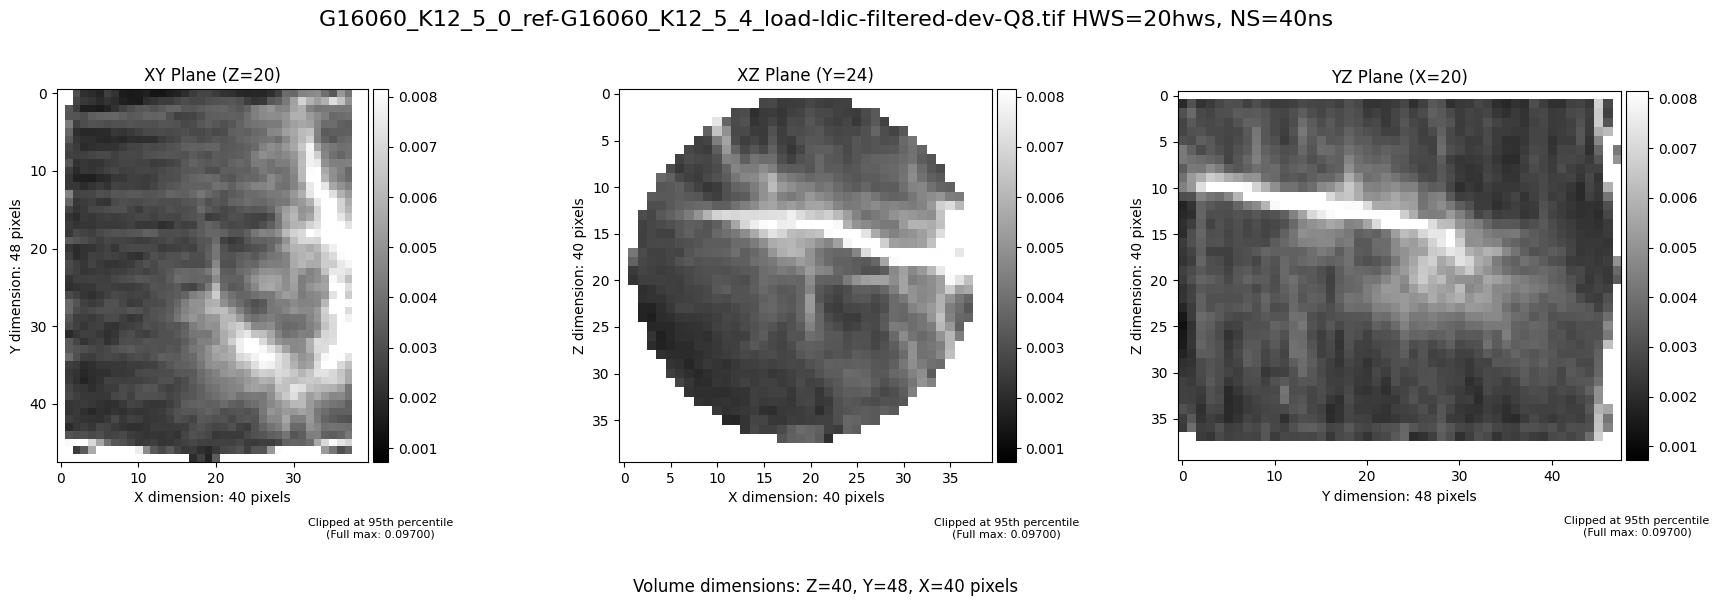

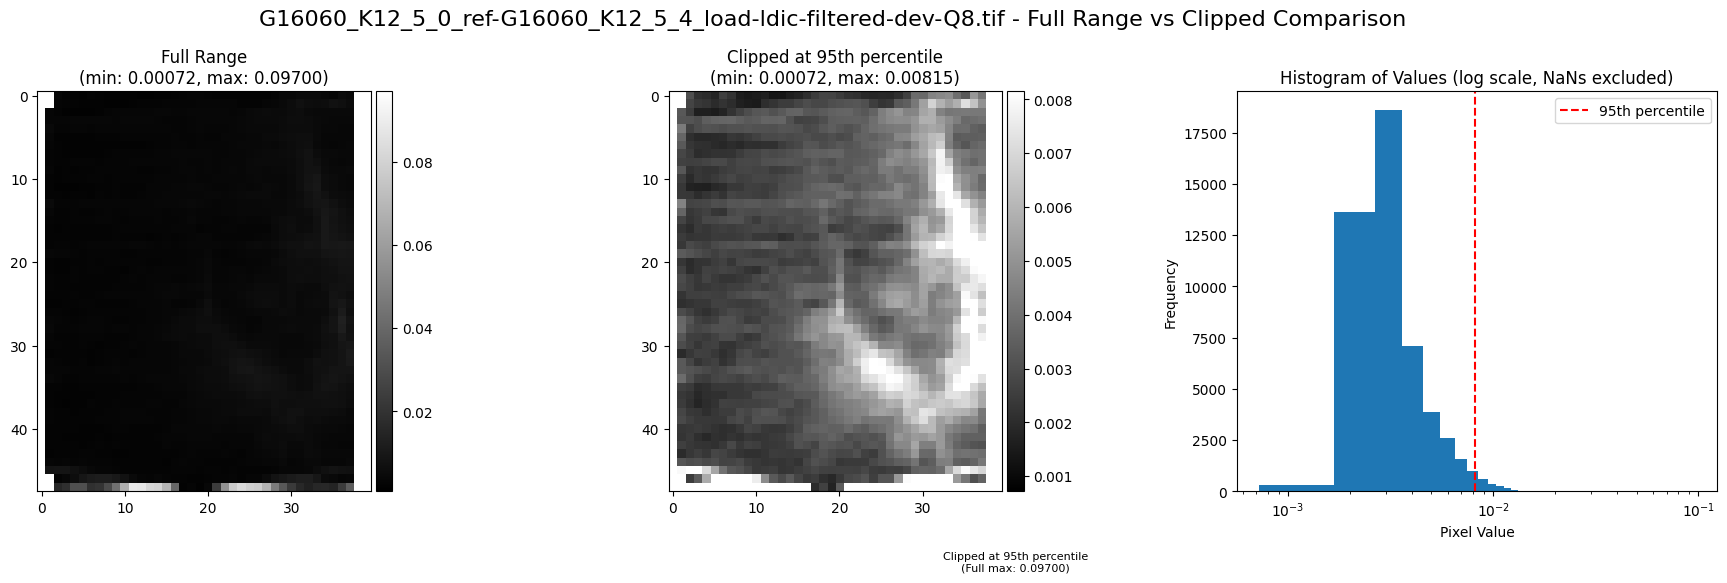

In [12]:
import numpy as np

# Do DVC on all reference - load pairs in data
hws_experiments = [20]
ns_experiments = [40]
it = 50
m_x = 3
m_y = 3
m_z = 3

for files in data_paths_3d_files:

    im1 = None  # reference image
    for file in files:
        if 'ref' in file:
            im1 = file
            break
    
    for file in files:
        if 'ref' in file:
            continue

        if 'G16060_K12' not in file:
            continue

        im2 = file

        p = os.path.basename(os.path.dirname(im1))
        a = os.path.join(raw_data_path, p)
        b = os.listdir(a)[0]
        c = os.listdir(os.path.join(a, b))[25]
        d = os.path.join(a, b, c)

        img = tiff.imread(d)
        h, w = img.shape
        img = img[h//2-25:h//2+25, w//2-25:w//2+25]

        # get average intensity of the image
        glt = np.mean(img) + 5

        for hws in hws_experiments:
            for ns in ns_experiments:
                out = os.path.join(dvc_output_path, f"{hws}hws_{ns}ns_{it}it_{round(glt)}glt_{m_z}z-{m_y}y-{m_x}xm_{os.path.basename(im1).replace('.tif', '')}-{os.path.basename(im2).replace('.tif', '')}")
                if os.path.exists(out) and filtered_path in os.listdir(out) and strain_filtered_path in os.listdir(out):
                    continue
                
                dvc_procedures(hws, ns, it, glt, m_x, m_y, m_z, im1, im2, out)
                p = os.path.join(out, strain_filtered_path)
                for file in os.listdir(p):

                    if "dev" in file:
                        d = os.path.join(p, file)
                        make_graphs(d, p)


In [ ]:
# go through every folder in dvc_output_path
# find the strain_filtered_path folder
# find a .png file
# open it and display it

import PIL.Image as Image

for folder in os.listdir(dvc_output_path):
    p = os.path.join(dvc_output_path, folder)
    for file in os.listdir(p):
        if file.endswith(strain_filtered_path):
            p = os.path.join(dvc_output_path, folder, file)
            for f in os.listdir(p):
                if f.endswith(".png"):
                    p = os.path.join(p, f)
                    img = Image.open(p)
                    if "40hws_60ns" in os.path.basename(p):
                        print(os.path.basename(p))
                        display(Image.open(p))

In [ ]:
load_num = 3
im1 = "res/p_ref/ref.tif"
im2 = f"res/p_{load_num}_load/shifted_load.tif"

hws = 20
ns = 20
it = 50
glt = 66
out = f"results/ldic/p_{hws}hws_{ns}ns_{it}it_{glt}glt_shifted_load_{load_num}"

ldic = f'spam-ldic {im1} {im2} -hws {hws} -ns {ns} -it {it} -glt {glt} -vtk -tif -od {out}'

tsv_file = f'{out}/ref-shifted_load-ldic.tsv'
out_filter = f'{out}/filtered'

filter = f'spam-filterPhiField -pf {tsv_file} -fm -F "all" -tif -vtk -od {out_filter}'

out_strain = f"results/strain/p_{hws}hws_{ns}ns_{it}it_{glt}glt_shifted_filtered_{load_num}"
out_strain_no_filter = f"results/strain/p_{hws}hws_{ns}ns_{it}it_{glt}glt_shifted_{load_num}"

no_filter_strain = f'spam-regularStrain {tsv_file} -comp vol dev U -cub -tif -vtk -od {out_strain_no_filter}'
strain = f'spam-regularStrain {out_filter}/ref-shifted_load-ldic-filtered.tsv -comp vol dev U -cub -tif -vtk -od {out_strain} -rst 1'

In [ ]:
# !{ldic} # 20 min # 2h 46m - 20ns
# !{filter}
# !{strain}
!{no_filter_strain}